# Task 2 — Exploratory Data Analysis

**Scope: January 2024 – December 2025 (two complete calendar years).**
Jan–May 2026 is the final model test period and is not examined here. Looking
at that period before scoring could let test information shape feature choices,
thresholds, or conclusions. Integrity checks covering the full 29-month
acquisition window remain in notebook 01.

**Development-set note:** 2025 is used for EDA as well as model validation, so
it is a development/validation period rather than a completely untouched
performance estimate. Jan–May 2026 remains the only untouched test period.

Raw `ArrDelay` is null for diverted flights; this notebook explicitly recovers 
the target from `DivArrDelay` only when `DivReachedDest == 1`. The 2024 monthly 
counts were reconciled against the BTS Reporting Operating Carrier summary.

In [2]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

repo_root = Path("..") if Path("../src").exists() else Path(".")
repo_root = repo_root.resolve()
os.chdir(repo_root)
sys.path.insert(0, str(repo_root / "src"))

from download_bts import INTERIM_DIR
from features import (
    build_holiday_calendar,
    add_weather_features,
    add_destination_departure_keys,
    build_airport_timezone_lookup,
    load_airport_coordinates,
    scheduled_departure_hour,
    ORIGIN_WEATHER_COLS,
    DEST_WEATHER_COLS,
)

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

interim_files = sorted(INTERIM_DIR.glob("bts_*.parquet"))

# EDA scope: 2024-2025 only. Jan-May 2026 is the held-out test set.
EDA_FILES = [
    p
    for p in interim_files
    if 2024 <= int(p.stem.split("_")[1]) <= 2025
]
assert EDA_FILES, "No 2024-2025 BTS parquet files found. Run src/download_bts.py first."


def wilson_interval(successes, totals, z=1.96):
    """Return vectorised Wilson score intervals for binomial rates."""
    successes = np.asarray(successes, dtype=float)
    totals = np.asarray(totals, dtype=float)
    p = np.divide(successes, totals, out=np.full_like(successes, np.nan), where=totals > 0)
    denom = 1 + z**2 / totals
    centre = (p + z**2 / (2 * totals)) / denom
    margin = (
        z
        * np.sqrt((p * (1 - p) + z**2 / (4 * totals)) / totals)
        / denom
    )
    return (centre - margin) * 100, (centre + margin) * 100

---
## Load data (2024-2025)

In [3]:
COLS = [
    "Year", "Month", "DayOfWeek", "DayofMonth", "FlightDate",
    "Reporting_Airline", "Origin", "Dest", "OriginState", "DestState",
    "OriginCityName", "DestCityName",
    "CRSDepTime", "DepTimeBlk",
    "CRSElapsedTime", "ActualElapsedTime",
    "Distance", "DistanceGroup",
    "ArrDel15", "ArrDelay", "ArrDelayMinutes",
    "Cancelled", "Diverted", "DivReachedDest", "DivArrDelay",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay",
    "TaxiOut",
]

df = pd.concat(
    [pd.read_parquet(p, columns=COLS) for p in EDA_FILES],
    ignore_index=True,
)

for col in [
    "Reporting_Airline", "Origin", "Dest", "OriginState", "DestState",
    "OriginCityName", "DestCityName", "DepTimeBlk",
]:
    df[col] = df[col].astype("category")

for col in [
    "ArrDelayMinutes", "ArrDelay", "DivArrDelay",
    "CRSElapsedTime", "ActualElapsedTime", "TaxiOut",
    "CarrierDelay", "WeatherDelay", "NASDelay",
    "SecurityDelay", "LateAircraftDelay", "Distance",
]:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")

# Recover diverted-flight targets exactly where the flight reached its destination.
# This mirrors the modeling rule in clean_data.py while keeping the EDA notebook
# self-contained and auditable.
recovered_diversion = (
    df["Diverted"].eq(1)
    & df["DivReachedDest"].eq(1)
    & df["DivArrDelay"].notna()
)
df.loc[recovered_diversion, "ArrDelay"] = df.loc[
    recovered_diversion, "DivArrDelay"
]
df.loc[recovered_diversion, "ArrDelayMinutes"] = (
    df.loc[recovered_diversion, "DivArrDelay"].clip(lower=0)
)
df.loc[recovered_diversion, "ArrDel15"] = (
    df.loc[recovered_diversion, "DivArrDelay"].ge(15).astype("float32")
)

# Cancelled flights and diversions that never reached the scheduled destination
# have no arrival-delay target and are analyzed as separate non-arrival outcomes.
df["nonarrival_disruption"] = (
    df["Cancelled"].eq(1)
    | (df["Diverted"].eq(1) & ~df["DivReachedDest"].eq(1))
)

op = df[
    ~df["nonarrival_disruption"]
    & df["ArrDel15"].notna()
    & df["ArrDelayMinutes"].notna()
].copy()
delayed = op[op["ArrDel15"].eq(1)].copy()

assert op["ArrDel15"].notna().all()
assert op["ArrDelayMinutes"].notna().all()

print(f"All flights                    : {len(df):>10,}")
print(f"Recovered diversions           : {recovered_diversion.sum():>10,}")
print(f"Non-arrival disruptions        : {df['nonarrival_disruption'].sum():>10,}")
print(f"Operating flights with target  : {len(op):>10,}")
print(
    f"Delayed ≥15m                  : {len(delayed):>10,}  "
    f"({len(delayed)/len(op):.1%} of operating flights with target)"
)

All flights                    : 14,080,680
Recovered diversions           :     33,487
Non-arrival disruptions        :    202,461
Operating flights with target  : 13,878,218
Delayed ≥15m                  :  3,018,071  (21.7% of operating flights with target)


---
## Block A — Delay distribution

**Overall Takeaway:** 
Arrival delay has a large zero/early-arrival mass and a long right tail.
About **63%** of flights arrive on time or early, while **21.7%** are delayed
by at least 15 minutes.

Among delayed flights, severity is highly skewed: the median delay is
**43 minutes**, but the 99th percentile reaches **517 minutes**.

A meaningful number of flights lie close to the 15-minute cutoff, so small
threshold changes reclassify more than 1% of all flights.

**Modeling implication:** Use a two-stage arrival-delay model:
classify `ArrDel15` first, then predict `ArrDelayMinutes` among delayed flights.
Evaluate calibration near the 15-minute boundary, test raw versus log-transformed
severity targets, and use time-based validation to account for seasonality.

### A1. Full `ArrDelay` distribution

**Why this analysis:** Establish the overall shape of arrival delay before choosing a modeling formulation.

ArrDelay <= 0 (on-time or early) : 63.0%
ArrDelayMinutes == 0             : 63.0%
Outside full plotted range       : 1.67%
Outside zoomed plotted range     : 10.86%


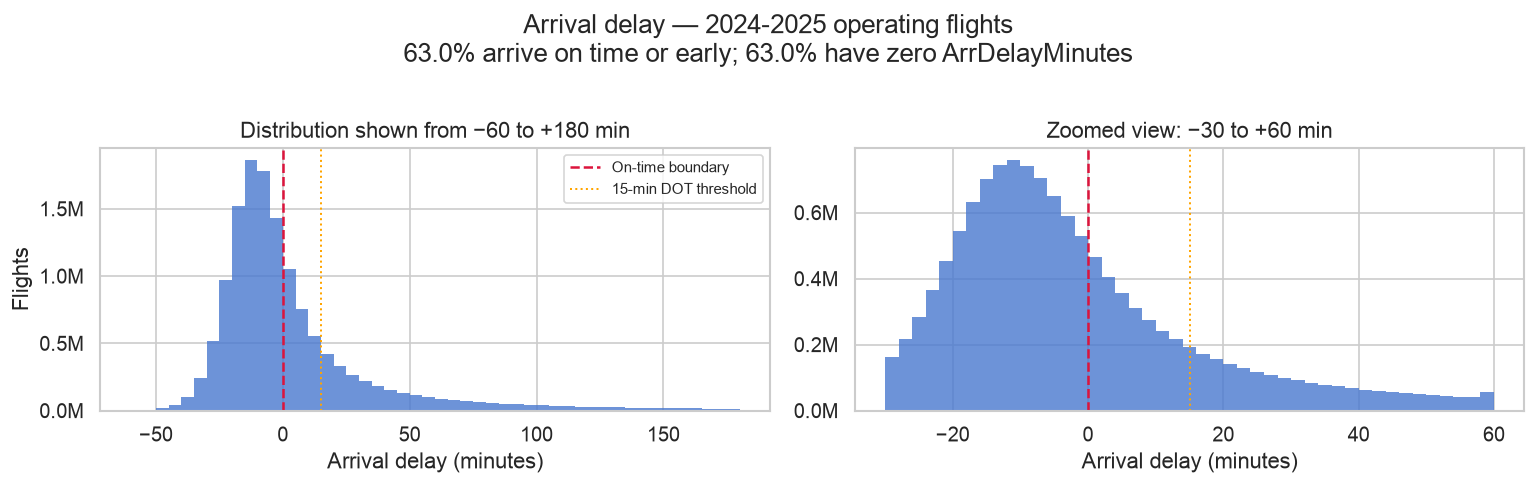

In [3]:
arr = op["ArrDelay"].dropna()
on_time_or_early = arr.le(0).mean()
zero_minutes = op["ArrDelayMinutes"].eq(0).mean()

print(f"ArrDelay <= 0 (on-time or early) : {on_time_or_early:.1%}")
print(f"ArrDelayMinutes == 0             : {zero_minutes:.1%}")

plot_range = arr.between(-60, 180)
zoom_range = arr.between(-30, 60)
print(f"Outside full plotted range       : {(~plot_range).mean():.2%}")
print(f"Outside zoomed plotted range     : {(~zoom_range).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bins = np.arange(-60, 181, 5)
ax.hist(arr.loc[plot_range], bins=bins, color="#4878CF", alpha=0.8, edgecolor="none")
ax.axvline(0, color="crimson", lw=1.5, linestyle="--", label="On-time boundary")
ax.axvline(15, color="orange", lw=1.2, linestyle=":", label="15-min DOT threshold")
ax.set_xlabel("Arrival delay (minutes)")
ax.set_ylabel("Flights")
ax.set_title("Distribution shown from −60 to +180 min")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend(fontsize=9)

ax = axes[1]
bins_zoom = np.arange(-30, 61, 2)
ax.hist(arr.loc[zoom_range], bins=bins_zoom, color="#4878CF", alpha=0.8, edgecolor="none")
ax.axvline(0, color="crimson", lw=1.5, linestyle="--")
ax.axvline(15, color="orange", lw=1.2, linestyle=":")
ax.set_xlabel("Arrival delay (minutes)")
ax.set_title("Zoomed view: −30 to +60 min")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

fig.suptitle(
    "Arrival delay — 2024-2025 operating flights\n"
    f"{on_time_or_early:.1%} arrive on time or early; "
    f"{zero_minutes:.1%} have zero ArrDelayMinutes",
    y=1.01,
)
plt.tight_layout()
fig.savefig(FIGURES / "02a1_arrdelay_dist.png", bbox_inches="tight")
plt.show()

**Findings / summary:** Arrival delay is asymmetric and strongly right-skewed.
The concentration of slightly early arrivals may be consistent with schedule buffers or recoverable time built into schedules, although this figure alone does not identify the reason.

**Modeling implication:** The outcome is not well represented by a single symmetric regression distribution. Most flights have no positive arrival-delay minutes, while the remaining flights have a long-tailed severity distribution.
This supports separating the problem into two stages:
1. Predict whether a flight will arrive at least 15 minutes late using `ArrDel15`.
2. Predict delay severity using `ArrDelayMinutes` among flights with `ArrDel15 == 1`.

### A2. Distribution among delayed flights only

**Why this analysis:** The goal is to understand the **severity distribution among flights
already classified as delayed** (`ArrDel15 == 1`) and determine whether the Stage 2 regression
target should be modeled on the raw minute scale or after a transformation.

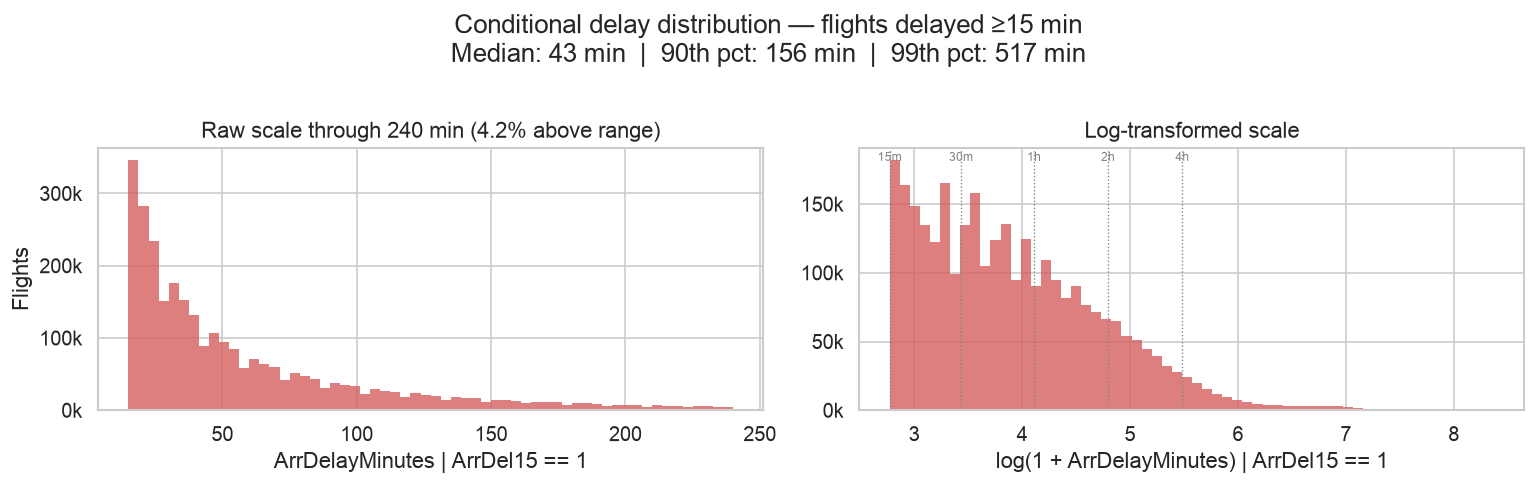

In [4]:
dm = delayed["ArrDelayMinutes"].dropna()
dm_plot = dm[dm.le(240)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(dm_plot, bins=60, color="#D65F5F", alpha=0.8, edgecolor="none")
ax.set_xlabel("ArrDelayMinutes | ArrDel15 == 1")
ax.set_ylabel("Flights")
ax.set_title(f"Raw scale through 240 min ({dm.gt(240).mean():.1%} above range)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

ax = axes[1]
ax.hist(np.log1p(dm), bins=60, color="#D65F5F", alpha=0.8, edgecolor="none")
ax.set_xlabel("log(1 + ArrDelayMinutes) | ArrDel15 == 1")
ax.set_title("Log-transformed scale")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
for minutes, label in [(15, "15m"), (30, "30m"), (60, "1h"), (120, "2h"), (240, "4h")]:
    ax.axvline(np.log1p(minutes), color="grey", lw=0.8, linestyle=":")
    ax.text(
        np.log1p(minutes),
        ax.get_ylim()[1] * 0.95,
        label,
        ha="center",
        fontsize=7,
        color="grey",
    )

fig.suptitle(
    "Conditional delay distribution — flights delayed ≥15 min\n"
    f"Median: {dm.median():.0f} min  |  90th pct: {dm.quantile(0.9):.0f} min  |  "
    f"99th pct: {dm.quantile(0.99):.0f} min",
    y=1.01,
)
plt.tight_layout()
fig.savefig(FIGURES / "02a2_delayed_dist.png", bbox_inches="tight")
plt.show()

**Findings / summary:** The frequency declines as delay duration increases, but the distribution contains visible local peaks. These may reflect rounding or heaping at operationally meaningful values such as 30, 45, 60, and 90 minutes.
The log-transformed plot compresses the largest delays and makes the middle of the distribution easier to inspect. It remains asymmetric and retains several local peaks, so it should not be described as normally or log-normally distributed based on this chart alone.
The hard lower boundary in both plots is mechanical because only flights with arrival delays of at least 15 minutes are included.

**Modeling implication:** Stage 2 should compare raw-minute and log1p targets. A log target may improve robustness for typical delays, while the raw target may better preserve sensitivity to severe disruptions. Final evaluation should be performed after transforming predictions back to minutes and should include upper-tail performance.

### A3. Mass near the 15-minute boundary

**Why this analysis:** Measure how many flights sit close to the official cutoff and how sensitive the delayed/not-delayed label is to small threshold changes.

In [5]:
window_10_20 = op["ArrDelayMinutes"].between(10, 20, inclusive="both").sum()
window_13_17 = op["ArrDelayMinutes"].between(13, 17, inclusive="both").sum()

# Exact reclassification under two alternative cutoffs.
newly_delayed_at_13 = op["ArrDelayMinutes"].between(13, 15, inclusive="left").sum()
no_longer_delayed_at_17 = op["ArrDelayMinutes"].between(15, 17, inclusive="left").sum()

print(f"Flights with ArrDelayMinutes in [10, 20] : {window_10_20:>8,}  ({window_10_20/len(op):.2%})")
print(f"Flights with ArrDelayMinutes in [13, 17] : {window_13_17:>8,}  ({window_13_17/len(op):.2%})")
print()
print(f"Cutoff moved from 15 to 13 min: {newly_delayed_at_13:,} ({newly_delayed_at_13/len(op):.2%}) newly classified delayed")
print(f"Cutoff moved from 15 to 17 min: {no_longer_delayed_at_17:,} ({no_longer_delayed_at_17/len(op):.2%}) no longer classified delayed")

Flights with ArrDelayMinutes in [10, 20] : 1,051,433  (7.58%)
Flights with ArrDelayMinutes in [13, 17] :  470,175  (3.39%)

Cutoff moved from 15 to 13 min: 203,751 (1.47%) newly classified delayed
Cutoff moved from 15 to 17 min: 181,887 (1.31%) no longer classified delayed


**Findings / summary:** A meaningful number of flights are concentrated near the classification boundary.
These results show that the reported delay rate depends meaningfully on the selected cutoff. Flights immediately below and above 15 minutes are operationally similar, even though they receive different binary labels.

**Modeling implication:** The official 15-minute threshold should remain the primary Stage 1 target because it matches the BTS definition of an arrival delay. However, observations close to the boundary are inherently difficult to distinguish and may contribute disproportionately to classification errors.
Model evaluation should therefore include:
- Overall discrimination and calibration.
- The distribution of predicted probabilities for flights just below and just above 15 minutes.

The model should not be expected to produce sharply different probabilities for a flight arriving 14 minutes late and one arriving 15 minutes late. Probability calibration is therefore more informative than accuracy alone near the cutoff.

---
## Block B — Airline differences

**Overall Takeaway:** 
Carrier differences are meaningful but should not be interpreted as direct
measures of operational quality.

The largest five carriers account for about **70.6%** of flights, yet even the
smaller carriers have enough volume for stable estimates. Carriers differ in
delay frequency, delay severity, cancellation rates, and delay-cause mix.

Some of these differences reflect network exposure, route mix, airport mix,
schedules, and cancellation practices rather than carrier performance alone.
On shared routes, planned elapsed-time differences are generally small—mostly
within about **±5 minutes**—but they may still affect arrival-delay risk.

**Modeling implication:** Keep carrier as a categorical feature and retain all
carriers unless training counts are genuinely sparse. Treat carrier effects as
predictive, not causal; model cancellations separately; exclude delay-cause
fields because they are known only after the outcome occurs; and retain
scheduled elapsed time as a pre-departure feature.

**Modeling implication:** Keep carrier as a categorical feature and retain all
carriers unless training counts are genuinely sparse. Treat carrier effects as
predictive, not causal; model cancellations separately; exclude delay-cause
fields because they are known only after the outcome occurs; and retain
scheduled elapsed time as a pre-departure feature.

### B1. Carrier concentration

**Why this analysis:** Measure how concentrated flight volume is across reporting carriers and assess
whether carrier-level results are dominated by a few large operators.

Reporting carriers: 15

Share of flights:
Reporting_Airline
WN    20.0
DL    14.5
AA    13.9
OO    11.3
UA    11.0
YX     4.6
MQ     4.1
AS     3.5
OH     3.4
B6     3.3
NK     3.2
F9     2.9
G4     1.8
9E     1.4
HA     1.1

Top 5 cumulative   : 70.6%
Bottom 5 cumulative: 10.4%


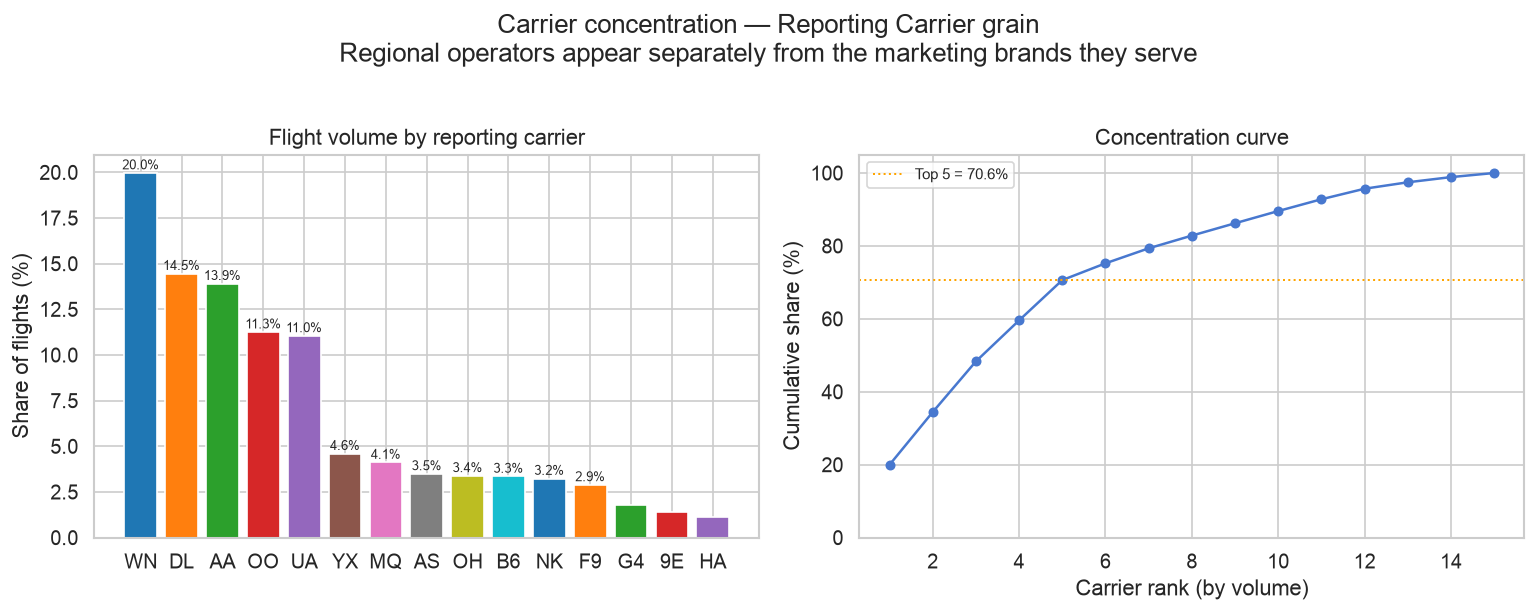

In [6]:
carrier_vol = df.groupby("Reporting_Airline", observed=True).size().sort_values(ascending=False)
carrier_pct = carrier_vol / len(df) * 100
cum_pct = carrier_pct.cumsum()
top5_share = carrier_pct.head(5).sum()
bottom5_share = carrier_pct.tail(5).sum()

print(f"Reporting carriers: {len(carrier_vol)}")
print("\nShare of flights:")
print(carrier_pct.round(1).to_string())
print(f"\nTop 5 cumulative   : {top5_share:.1f}%")
print(f"Bottom 5 cumulative: {bottom5_share:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(
    carrier_pct.index.astype(str),
    carrier_pct.values,
    color=sns.color_palette("tab10", len(carrier_vol)),
)
ax.set_ylabel("Share of flights (%)")
ax.set_title("Flight volume by reporting carrier")
for bar, value in zip(bars, carrier_pct.values):
    if value > 2:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{value:.1f}%",
            ha="center",
            fontsize=8,
        )

ax = axes[1]
ax.plot(range(1, len(cum_pct) + 1), cum_pct.values, marker="o", ms=5, color="#4878CF")
ax.axhline(
    top5_share,
    color="orange",
    linestyle=":",
    lw=1.2,
    label=f"Top 5 = {top5_share:.1f}%",
)
ax.set_xlabel("Carrier rank (by volume)")
ax.set_ylabel("Cumulative share (%)")
ax.set_title("Concentration curve")
ax.legend(fontsize=9)
ax.set_ylim(0, 105)

fig.suptitle(
    "Carrier concentration — Reporting Carrier grain\n"
    "Regional operators appear separately from the marketing brands they serve",
    y=1.02,
)
plt.tight_layout()
fig.savefig(FIGURES / "02b1_carrier_concentration.png", bbox_inches="tight")
plt.show()

**Findings / summary:** 
- There are **15 reporting carriers** in the 2024–2025 data.
- Southwest accounts for about **20.0%** of flights.
- The top five carriers account for **70.6%** of all flights.
- The remaining carriers each contribute much smaller shares.
- Regional operators appear separately from the marketing airlines they serve.

**Modeling implication:** Carrier is likely an informative feature, but results will be driven mainly by the largest operators.
Although the largest carriers dominate total flight volume, lower-share carriers may still have enough observations
to estimate stable effects. Combine carriers into `Other` only when their 2024
training counts are genuinely sparse, then apply that mapping unchanged to
validation and test data.

### B2. Delay rate by carrier

**Why this analysis:** Compare carrier delay rates while showing uncertainty.

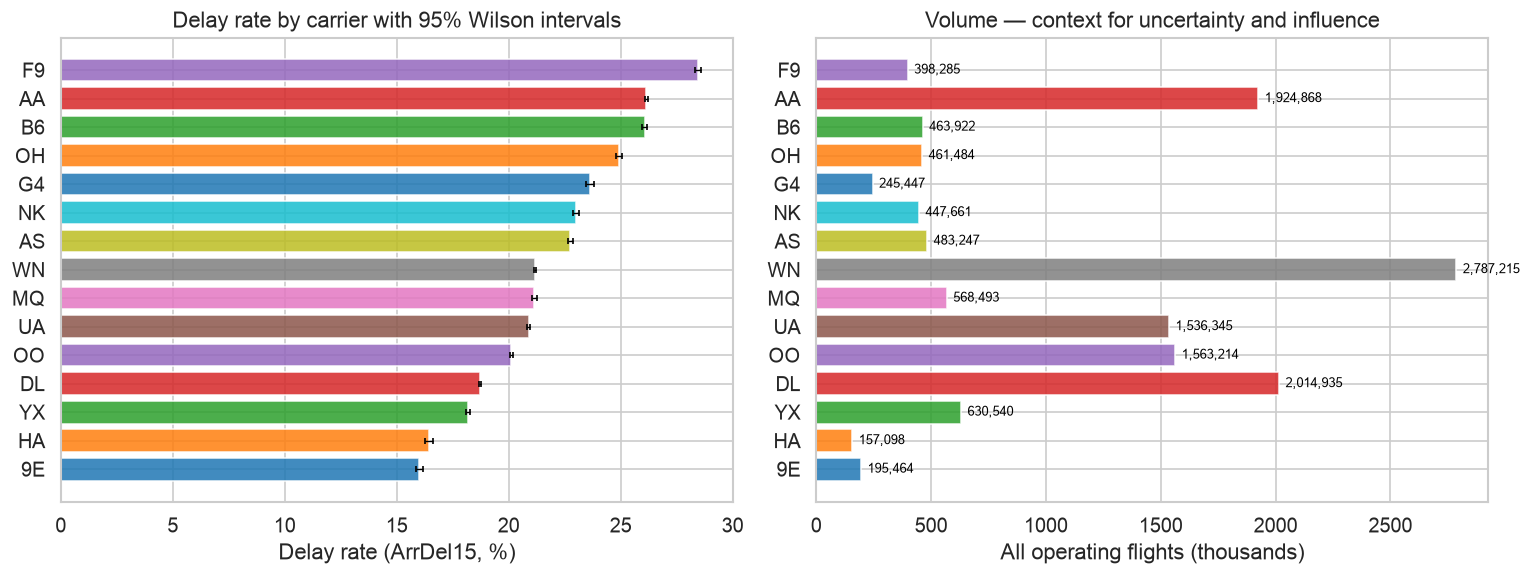

In [7]:
carrier_all = (
    df.groupby("Reporting_Airline", observed=True)
    .agg(
        total_flights=("Cancelled", "size"),
        cancelled=("Cancelled", "sum"),
        nonarrival_disruptions=("nonarrival_disruption", "sum"),
    )
)

carrier_operated = (
    op.groupby("Reporting_Airline", observed=True)
    .agg(
        operating_flights=("ArrDel15", "count"),
        delayed=("ArrDel15", "sum"),
    )
)

carrier_stats = carrier_all.join(carrier_operated, how="left").fillna(
    {"operating_flights": 0, "delayed": 0}
)
carrier_stats["delay_rate"] = (
    carrier_stats["delayed"] / carrier_stats["operating_flights"] * 100
)
carrier_stats["cancel_rate"] = (
    carrier_stats["cancelled"] / carrier_stats["total_flights"] * 100
)
carrier_stats["nonarrival_rate"] = (
    carrier_stats["nonarrival_disruptions"] / carrier_stats["total_flights"] * 100
)

ci_low, ci_high = wilson_interval(
    carrier_stats["delayed"],
    carrier_stats["operating_flights"],
)
carrier_stats["delay_ci_low"] = ci_low
carrier_stats["delay_ci_high"] = ci_high
carrier_stats = carrier_stats.sort_values("delay_rate").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_carr = sns.color_palette("tab10", len(carrier_stats))

ax = axes[0]
y = np.arange(len(carrier_stats))
rates = carrier_stats["delay_rate"].to_numpy()
xerr = np.vstack(
    [
        rates - carrier_stats["delay_ci_low"].to_numpy(),
        carrier_stats["delay_ci_high"].to_numpy() - rates,
    ]
)
ax.barh(y, rates, color=colors_carr, alpha=0.85)
ax.errorbar(rates, y, xerr=xerr, fmt="none", ecolor="black", capsize=2, lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(carrier_stats["Reporting_Airline"].astype(str))
ax.set_xlabel("Delay rate (ArrDel15, %)")
ax.set_title("Delay rate by carrier with 95% Wilson intervals")

ax = axes[1]
flight_vol = carrier_stats["operating_flights"] / 1e3
ax.barh(y, flight_vol, color=colors_carr, alpha=0.85)
for i, total_flights in enumerate(carrier_stats["operating_flights"]):
    ax.text(
        flight_vol.iloc[i] + max(flight_vol.max() * 0.01, 0.05),
        i,
        f"{int(total_flights):,}",
        va="center",
        ha="left",
        fontsize=8,
        color="black",
    )
ax.set_yticks(y)
ax.set_yticklabels(carrier_stats["Reporting_Airline"].astype(str))
ax.set_xlabel("All operating flights (thousands)")
ax.set_title("Volume — context for uncertainty and influence")

plt.tight_layout()
fig.savefig(FIGURES / "02b2_carrier_delay_rate.png", bbox_inches="tight")
plt.show()

**Findings / summary:** 
- Delay rates vary substantially, from about **16% to 29%**.
- F9 has the highest observed rate, while 9E and HA have the lowest.
- The 95% Wilson intervals are narrow because every carrier has a large sample.
- Lower-volume carriers still have enough flights for stable estimates.
- Carrier rankings describe operated-flight performance and may also reflect
  differences in airports, routes, schedules, and cancellation practices.

**Modeling implication:** Carrier should remain a categorical feature because delay risk differs
meaningfully across operators. There is no clear need to combine carriers into
`Other`, since even the smaller carriers have substantial volume. Carrier
effects should be interpreted as predictive rather than causal.

### B3. Delay magnitude by carrier

**Why this analysis:** Compare delay severity across carriers among flights already delayed by at least
15 minutes.

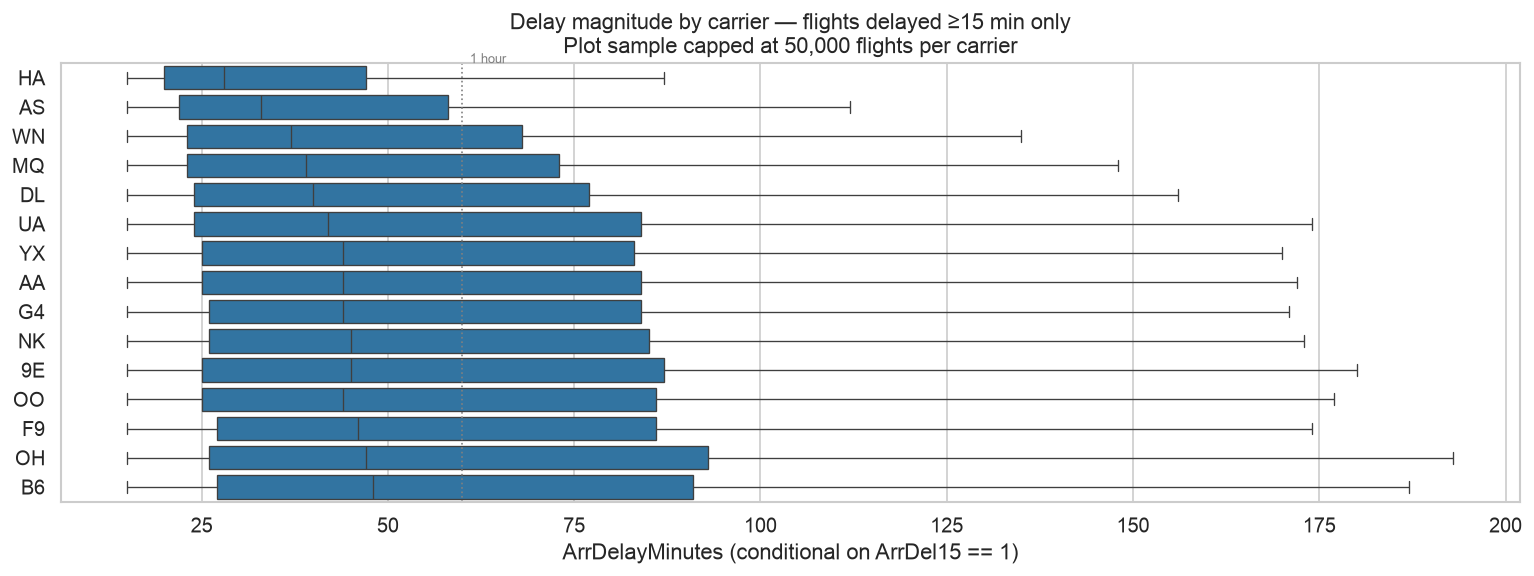

In [8]:
carrier_order = (
    delayed.groupby("Reporting_Airline", observed=True)["ArrDelayMinutes"]
    .median()
    .sort_values()
    .index.tolist()
)

# A fixed per-carrier sample keeps the boxplot responsive without changing its
# percentile interpretation.
plot_source = delayed[delayed["ArrDelayMinutes"].le(300)].copy()
max_per_carrier = 50_000
# Avoid DataFrameGroupBy.apply here. In pandas 3.x, grouping columns are
# excluded from apply inputs by default; with group_keys=False that can remove
# Reporting_Airline entirely and make the seaborn call fail.
sampled_carrier_groups = [
    group.sample(
        n=min(len(group), max_per_carrier),
        random_state=42,
    )
    for _, group in plot_source.groupby(
        "Reporting_Airline",
        observed=True,
        sort=False,
    )
]
delayed_plot = pd.concat(sampled_carrier_groups, ignore_index=True)

required_plot_cols = {"Reporting_Airline", "ArrDelayMinutes"}
missing_plot_cols = required_plot_cols - set(delayed_plot.columns)
if missing_plot_cols:
    raise AssertionError(
        "Carrier delay plot is missing required columns: "
        f"{sorted(missing_plot_cols)}"
    )

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=delayed_plot,
    x="ArrDelayMinutes",
    y="Reporting_Airline",
    order=carrier_order,
    showfliers=False,
    linewidth=0.8,
    ax=ax,
)
ax.set_xlabel("ArrDelayMinutes (conditional on ArrDel15 == 1)")
ax.set_ylabel("")
ax.set_title(
    "Delay magnitude by carrier — flights delayed ≥15 min only\n"
    f"Plot sample capped at {max_per_carrier:,} flights per carrier"
)
ax.axvline(60, color="grey", linestyle=":", lw=1)
ax.text(61, -0.5, "1 hour", fontsize=8, color="grey")
plt.tight_layout()
fig.savefig(FIGURES / "02b3_carrier_delay_magnitude.png", bbox_inches="tight")
plt.show()

**Findings / summary:**
- For visual purposes, the chart excludes outlier points and caps the plotted sample at 50,000 flights
  per carrier, so it describes distribution shape rather than total volume.
- Median delay severity varies from roughly **28 to 48 minutes** by carrier.
- HA and AS have the lowest conditional medians, while B6 and OH have the highest.
- Several carriers have wide interquartile ranges and long upper tails, showing
  substantial variation even within the same airline.

**Modeling implication:** Carrier may help predict Stage 2 delay severity as well as Stage 1 delay
occurrence.

### B4. Delay-cause mix by carrier

**Why this analysis:** Compare how attributed delay minutes are distributed across carrier, weather, NAS, security, and late-aircraft causes.

In [5]:
cause_cols = [
    "CarrierDelay", "WeatherDelay", "NASDelay",
    "SecurityDelay", "LateAircraftDelay",
]
cause_totals = delayed[cause_cols].sum()
cause_share = (cause_totals / cause_totals.sum() * 100).sort_values(ascending=False)
print(cause_share.round(1).to_string())

LateAircraftDelay    39.799999
CarrierDelay         33.400002
NASDelay             20.400000
WeatherDelay          6.200000
SecurityDelay         0.200000


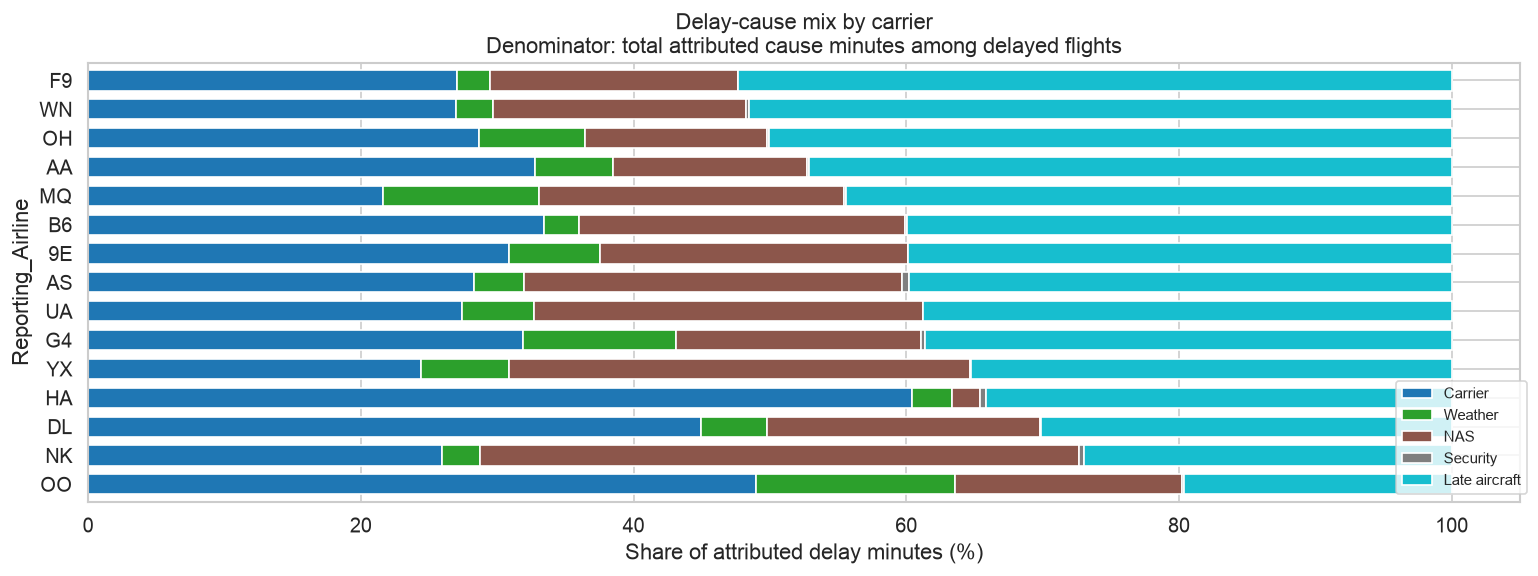

In [9]:
carrier_cause = (
    delayed.groupby("Reporting_Airline", observed=True)[cause_cols]
    .sum(min_count=1)
    .rename(
        columns={
            "CarrierDelay": "Carrier",
            "WeatherDelay": "Weather",
            "NASDelay": "NAS",
            "SecurityDelay": "Security",
            "LateAircraftDelay": "Late aircraft",
        }
    )
)
cause_totals = carrier_cause.sum(axis=1)
carrier_cause_pct = carrier_cause.div(cause_totals.replace(0, np.nan), axis=0) * 100
carrier_cause_pct = carrier_cause_pct.loc[
    carrier_cause_pct["Late aircraft"].sort_values().index
]

fig, ax = plt.subplots(figsize=(13, 5))
carrier_cause_pct.plot(kind="barh", stacked=True, ax=ax, colormap="tab10", width=0.7)
ax.set_xlabel("Share of attributed delay minutes (%)")
ax.set_title(
    "Delay-cause mix by carrier\n"
    "Denominator: total attributed cause minutes among delayed flights"
)
ax.legend(loc="lower right", fontsize=9, bbox_to_anchor=(1.01, 0))
plt.tight_layout()
fig.savefig(FIGURES / "02b4_carrier_cause_mix.png", bbox_inches="tight")
plt.show()

**Findings / summary:** 
- A flight may contribute minutes to multiple causes, so the chart summarizes
  attributed minutes rather than assigning one cause per flight.
- Cause composition differs considerably across carriers.
- Late-aircraft delay is the largest component for several carriers, including
  F9, WN, OH, and AA.
- Carrier-attributed delay is especially prominent for HA, OO, and DL.
- NAS delay represents a larger share for carriers such as NK, YX, and UA.
- Weather contributes a smaller share overall, while security delay is negligible.

**Modeling implication:** Delay-cause columns are outcome-time explanatory fields and must remain EDA-only, not model predictors.

### B5. Delay rate vs. cancellation rate — selection in the operated sample

**Why this analysis:** Check whether carrier delay rates among operated flights are related to how
often carriers cancel scheduled flights.

Carrier-level Spearman association: 0.19


/var/folders/4q/bcs2wt0906vdhb03j4swyhpc0000gn/T/ipykernel_54299/4182869836.py:32: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/bcs2wt0906vdhb03j4swyhpc0000gn/T/ipykernel_54299/4182869836.py:33: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.savefig(FIGURES / "02b5_delay_vs_cancel.png", bbox_inches="tight")
/Users/jocelynzhao/bloomberg_case/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


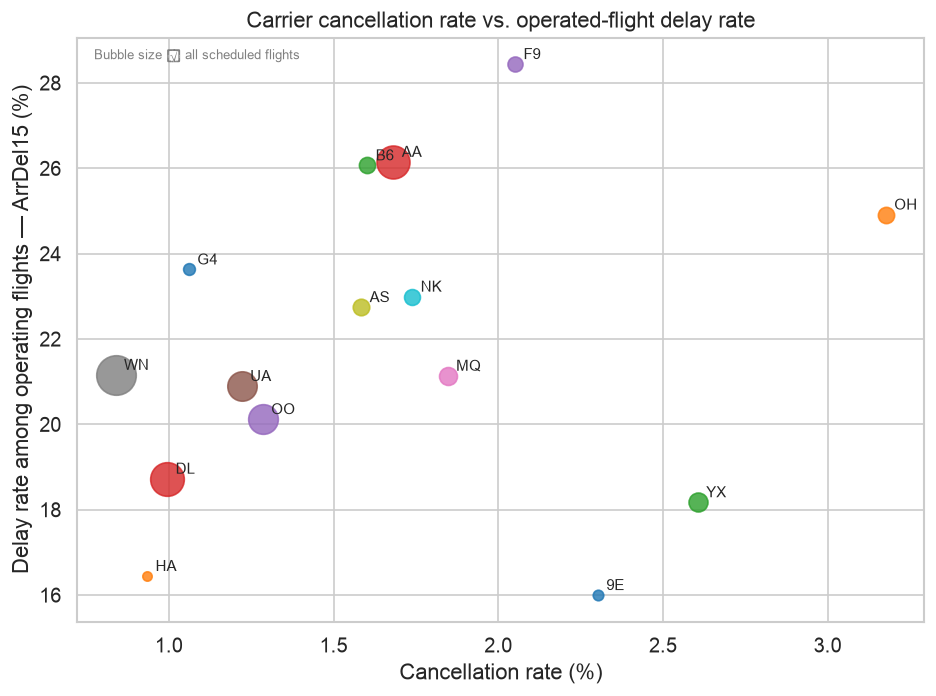

In [10]:
association = carrier_stats[["cancel_rate", "delay_rate"]].corr(method="spearman").iloc[0, 1]
print(f"Carrier-level Spearman association: {association:.2f}")

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in carrier_stats.iterrows():
    ax.scatter(
        row["cancel_rate"],
        row["delay_rate"],
        s=max(row["total_flights"] / 5000, 12),
        alpha=0.8,
    )
    ax.annotate(
        row["Reporting_Airline"],
        (row["cancel_rate"], row["delay_rate"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=9,
    )

ax.set_xlabel("Cancellation rate (%)")
ax.set_ylabel("Delay rate among operating flights — ArrDel15 (%)")
ax.set_title("Carrier cancellation rate vs. operated-flight delay rate")
ax.text(
    0.02,
    0.98,
    "Bubble size ∝ all scheduled flights",
    transform=ax.transAxes,
    fontsize=8,
    color="grey",
    va="top",
)
plt.tight_layout()
fig.savefig(FIGURES / "02b5_delay_vs_cancel.png", bbox_inches="tight")
plt.show()

**Findings / summary:** 
- There is no clear monotonic relationship between cancellation and delay rates.
- Carriers with similar cancellation rates can have very different delay rates.
- OH has the highest cancellation rate but not the highest operated-flight delay rate.
- F9 has the highest delay rate despite a mid-range cancellation rate.
- The chart is descriptive and does not show that cancellations improve on-time performance.

**Modeling implication:** Arrival-delay predictions are conditional on a flight operating and reaching
its destination. Cancellations should be modeled as a separate outcome or
included in a broader disruption model, rather than treated as ordinary
non-delayed flights.

### B6. Scheduled elapsed time by carrier on shared routes

**Why this analysis:** Carrier delay rates partly reflect differences in airports, routes, schedules,
and operating environments. Carrier rankings are therefore descriptive rather
than direct measures of operational quality.
This analysis compares schedule buffers on shared directional routes to reduce route-mix confounding in carrier comparisons.

Scheduled elapsed time on shared high-volume directional routes (≥100 flights per carrier-route; ≥5 routes per carrier):
Reporting_Airline  median_scheduled_elapsed  within_route_difference  flights  routes
               WN                      95.0                    -3.00   215983      55
               HA                      48.5                    -2.25    97109      10
               AA                     132.0                    -1.50   210142      53
               B6                     139.5                    -1.50    59328      22
               AS                     157.5                    -0.50    87701      22
               NK                     147.5                    -0.50    56280      48
               DL                     135.0                     0.00   272723      60
               UA                     135.5                     0.00   242844      50
               MQ                     127.5                     1.00    14585      22
               F9  

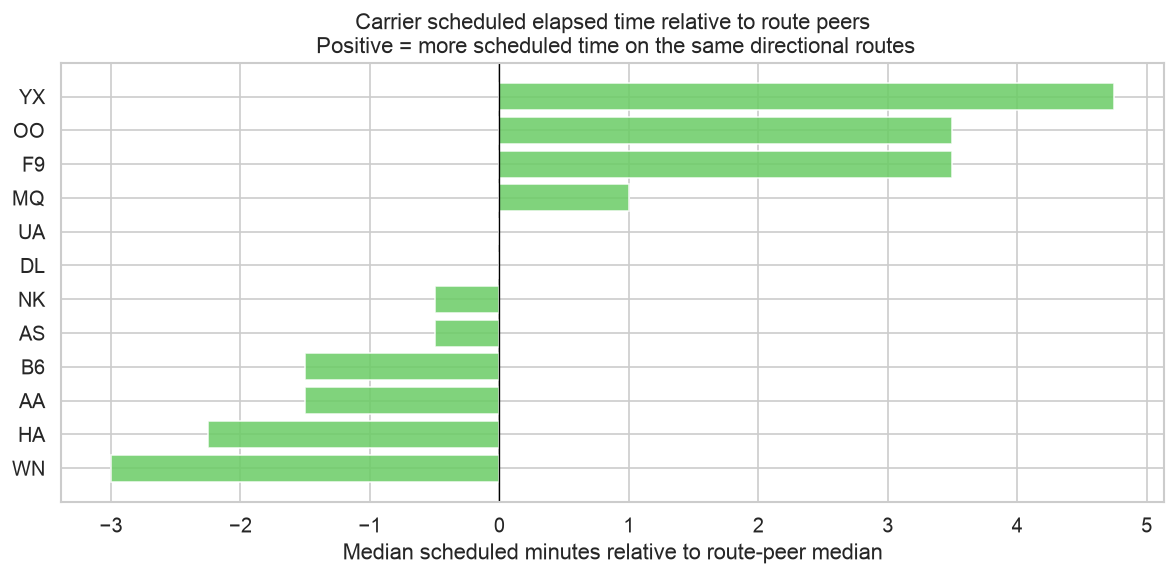

In [11]:
TOP_N_ROUTES = 100
MIN_CARRIER_ROUTE_FLIGHTS = 100
MIN_SHARED_ROUTES_PER_CARRIER = 5

# Use scheduled fields only. Comparing CRS elapsed time directly avoids mixing
# planned schedule padding with realised taxi, airborne, weather, or diversion effects.
schedule = df.loc[
    df["CRSElapsedTime"].notna()
    & df["CRSElapsedTime"].gt(0),
    [
        "Reporting_Airline",
        "Origin",
        "Dest",
        "CRSElapsedTime",
    ],
].copy()
schedule["route"] = (schedule["Origin"].astype(str) + "-" + schedule["Dest"].astype(str))

top_routes = schedule["route"].value_counts().head(TOP_N_ROUTES).index
schedule = schedule[schedule["route"].isin(top_routes)].copy()

# Estimate one stable scheduled-time value per carrier and route.
carrier_route_schedule = (
    schedule.groupby(
        ["route", "Reporting_Airline"],
        observed=True,
    )
    .agg(
        scheduled_elapsed_min=("CRSElapsedTime", "median"),
        flights=("CRSElapsedTime", "size"),
    )
    .reset_index()
)
carrier_route_schedule = carrier_route_schedule[carrier_route_schedule["flights"].ge(MIN_CARRIER_ROUTE_FLIGHTS)].copy()

# Keep routes with at least two eligible carriers after the cell-size filter.
shared_routes = (
    carrier_route_schedule.groupby("route", observed=True)["Reporting_Airline"]
    .nunique()
    .loc[lambda counts: counts.ge(2)]
    .index
)
carrier_route_schedule = carrier_route_schedule[carrier_route_schedule["route"].isin(shared_routes)].copy()

# Give each eligible carrier equal weight when defining the route peer median.
carrier_route_schedule["route_peer_median_min"] = (
    carrier_route_schedule.groupby("route", observed=True)["scheduled_elapsed_min"].transform("median")
)
carrier_route_schedule["relative_schedule_min"] = (
    carrier_route_schedule["scheduled_elapsed_min"]
    - carrier_route_schedule["route_peer_median_min"]
)

carrier_padding = (
    carrier_route_schedule.groupby("Reporting_Airline", observed=True)
    .agg(
        median_scheduled_elapsed=("scheduled_elapsed_min", "median"),
        within_route_difference=("relative_schedule_min", "median"),
        flights=("flights", "sum"),
        routes=("route", "nunique"),
    )
    .loc[lambda data: data["routes"].ge(MIN_SHARED_ROUTES_PER_CARRIER)]
    .sort_values("within_route_difference")
    .reset_index()
)

if carrier_padding.empty:
    raise ValueError(
        "No carriers meet the shared-route stability thresholds. "
        "Review the route and carrier-route minimums."
    )

print(
    "Scheduled elapsed time on shared high-volume directional routes "
    f"(≥{MIN_CARRIER_ROUTE_FLIGHTS} flights per carrier-route; "
    f"≥{MIN_SHARED_ROUTES_PER_CARRIER} routes per carrier):"
)
print(carrier_padding.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    carrier_padding["Reporting_Airline"].astype(str),
    carrier_padding["within_route_difference"],
    color="#6ACC65",
    alpha=0.85,
)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Median scheduled minutes relative to route-peer median")
ax.set_title("Carrier scheduled elapsed time relative to route peers\n Positive = more scheduled time on the same directional routes")
plt.tight_layout()
fig.savefig(FIGURES / "02b6_schedule_padding.png", bbox_inches="tight")
plt.show()

**Findings / summary:**
- The comparison includes only the 100 highest-volume directional routes,
  carrier–route groups with at least 100 flights, routes with at least two
  eligible carriers, and carriers represented on at least five shared routes.
  OH, G4, and 9E are dropped from the analysis.
- Most plotted carrier differences are within approximately **±5 minutes**.
- YX, OO, and F9 typically schedule more time than route peers, while WN and
  HA typically schedule less.

**Modeling implication:** `CRSElapsedTime` is known before departure and can
capture legal planned-time differences because scheduled gate-to-gate time
varies across carriers even on comparable routes.

---
## Block C — Airport differences

**Takeaway:** 
- The airport network is highly concentrated: the top 30 airports account for
  about **65% of flights**.
- Delay rates differ across airports, and origin and destination effects are not
  interchangeable.
- Late-aircraft and NAS delays highlight the importance of network propagation
  and congestion.
**Modeling implication:** Keep origin and destination as separate features, retain carrier, route, weather,
time, and demand interactions, and use scheduled congestion proxies rather than
post-departure variables.

### C1. Airport concentration curve

**Why this analysis:** Measure how flight volume is distributed across origin airports and assess the
size of the low-volume airport tail.

Top  10 airports: 33.6% of flights
Top  30 airports: 64.8% of flights
Top  50 airports: 78.5% of flights
Top 100 airports: 91.5% of flights
Top 200 airports: 98.4% of flights


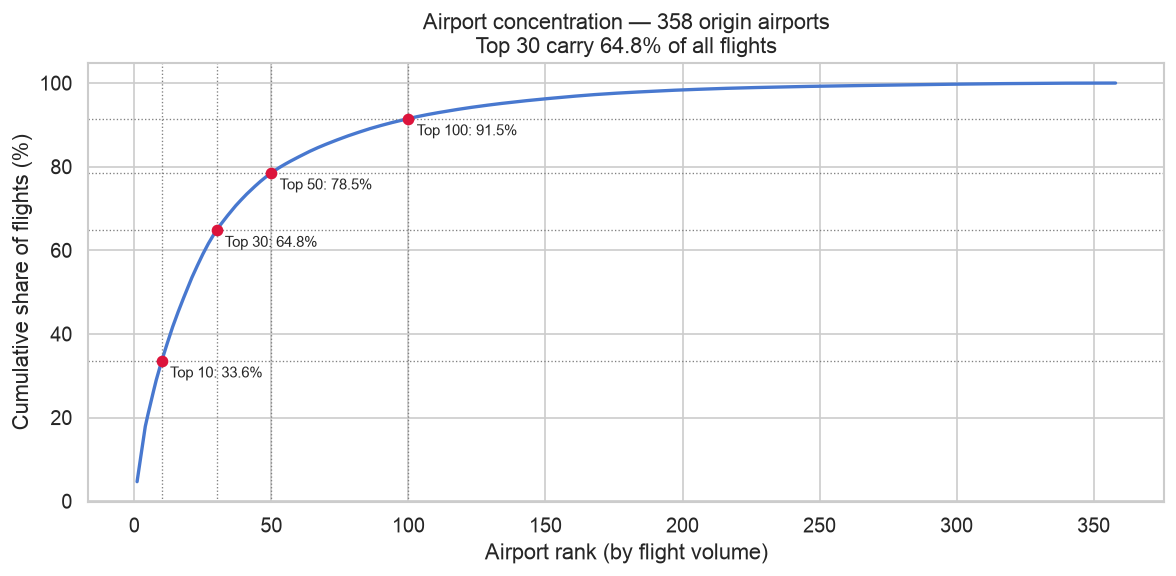

In [12]:
airport_vol = df.groupby("Origin", observed=True).size().sort_values(ascending=False)
airport_pct = airport_vol / len(df) * 100
cum_pct_ap = airport_pct.cumsum().reset_index()
cum_pct_ap.columns = ["Airport", "cum_pct"]
cum_pct_ap["rank"] = range(1, len(cum_pct_ap) + 1)
top30_airport_share = airport_pct.head(30).sum()

for n in [10, 30, 50, 100, 200]:
    print(f"Top {n:3d} airports: {cum_pct_ap.loc[cum_pct_ap['rank']==n, 'cum_pct'].values[0]:.1f}% of flights")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cum_pct_ap["rank"], cum_pct_ap["cum_pct"], color="#4878CF", lw=2)
for n, label in [(10, "10"), (30, "30"), (50, "50"), (100, "100")]:
    y = cum_pct_ap.loc[cum_pct_ap["rank"]==n, "cum_pct"].values[0]
    ax.axvline(n, color="grey", linestyle=":", lw=0.8)
    ax.axhline(y, color="grey", linestyle=":", lw=0.8)
    ax.scatter([n], [y], color="crimson", zorder=5)
    ax.annotate(f"Top {label}: {y:.1f}%", (n, y), xytext=(n+3, y-4), fontsize=9)

ax.set_xlabel("Airport rank (by flight volume)")
ax.set_ylabel("Cumulative share of flights (%)")
ax.set_title(
    f"Airport concentration — {len(airport_vol)} origin airports\n"
    f"Top 30 carry {top30_airport_share:.1f}% of all flights"
)
plt.tight_layout()
fig.savefig(FIGURES / "02c1_airport_concentration.png", bbox_inches="tight")
plt.show()

**Findings / summary:** 
- Flight volume follows a steep power law: the top 10 airports (out
  of 362) carry a third of all flights; the top 30 carry two thirds.  A long tail
  of small airports each sees under 0.1% of traffic.
- Airport-level results will therefore be driven mainly by major hubs, while
  estimates for small airports may be less stable.

**Modeling implication:** Origin and destination airports should remain predictive features. Rare-airport
grouping should be based on 2024 training counts, then applied unchanged to
2025 and 2026. Weather and feature coverage should still include all airports,
not only the highest-volume hubs.

### C2. Delay rate by origin and destination airport

**Why this analysis:** Compare arrival-delay rates at the 30 highest-volume
origin and destination airports while retaining separate departure- and arrival-side views.

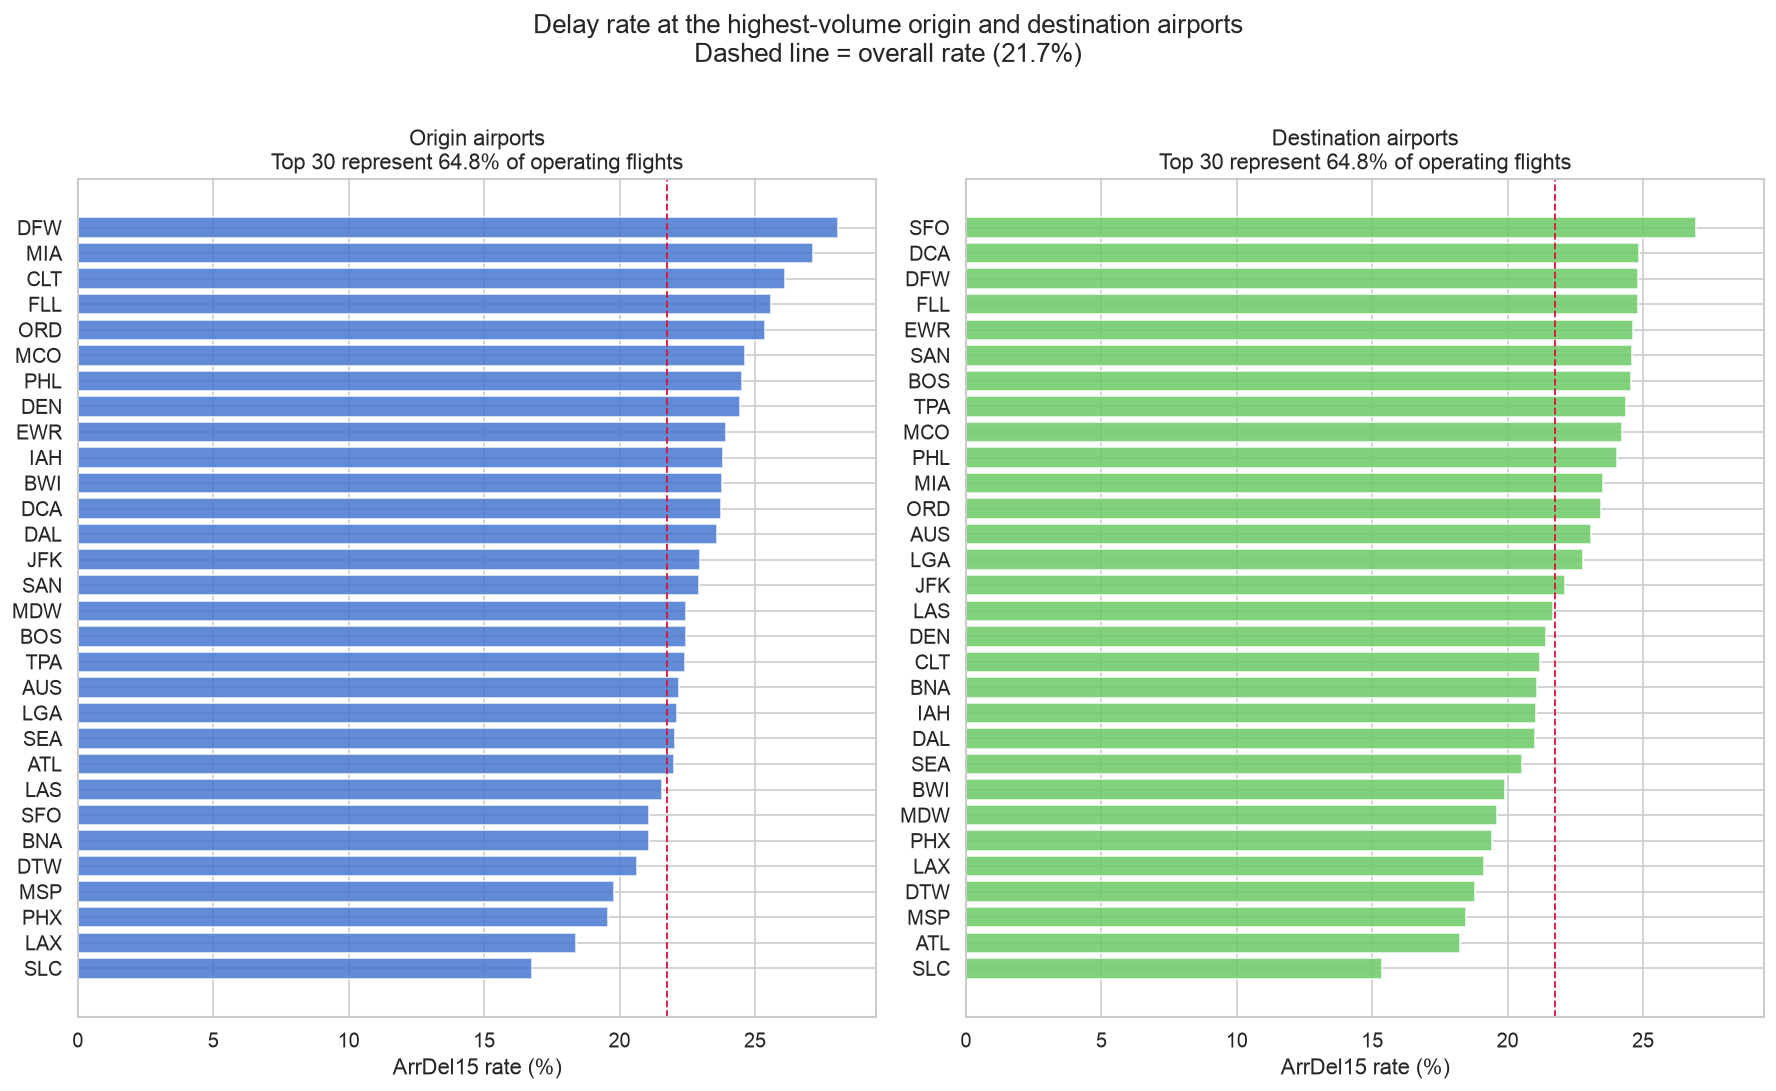

In [13]:
origin_stats = (
    op.groupby("Origin", observed=True)
    .agg(flights=("ArrDel15", "count"), delayed=("ArrDel15", "sum"))
    .assign(delay_rate=lambda d: d["delayed"] / d["flights"] * 100)
    .sort_values("delay_rate", ascending=False)
    .reset_index()
)
destination_stats = (
    op.groupby("Dest", observed=True)
    .agg(flights=("ArrDel15", "count"), delayed=("ArrDel15", "sum"))
    .assign(delay_rate=lambda d: d["delayed"] / d["flights"] * 100)
    .sort_values("delay_rate", ascending=False)
    .reset_index()
)

top30_origin = df.groupby("Origin", observed=True).size().nlargest(30).index
top30_dest = df.groupby("Dest", observed=True).size().nlargest(30).index

origin30 = (
    origin_stats[origin_stats["Origin"].isin(top30_origin)]
    .sort_values("delay_rate")
)
dest30 = (
    destination_stats[destination_stats["Dest"].isin(top30_dest)]
    .sort_values("delay_rate")
)

origin_share = origin30["flights"].sum() / len(op) * 100
dest_share = dest30["flights"].sum() / len(op) * 100
overall_delay_rate = op["ArrDel15"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 9), sharex=True)

ax = axes[0]
ax.barh(origin30["Origin"].astype(str), origin30["delay_rate"], color="#4878CF", alpha=0.85)
ax.axvline(overall_delay_rate, color="crimson", linestyle="--", lw=1.1)
ax.set_xlabel("ArrDel15 rate (%)")
ax.set_title(f"Origin airports\nTop 30 represent {origin_share:.1f}% of operating flights")

ax = axes[1]
ax.barh(dest30["Dest"].astype(str), dest30["delay_rate"], color="#6ACC65", alpha=0.85)
ax.axvline(overall_delay_rate, color="crimson", linestyle="--", lw=1.1)
ax.set_xlabel("ArrDel15 rate (%)")
ax.set_title(f"Destination airports\nTop 30 represent {dest_share:.1f}% of operating flights")

fig.suptitle(
    "Delay rate at the highest-volume origin and destination airports\n"
    f"Dashed line = overall rate ({overall_delay_rate:.1f}%)",
    y=1.01,
)
plt.tight_layout()
fig.savefig(FIGURES / "02c2_airport_delay_rate.png", bbox_inches="tight")
plt.show()

# Keep the origin table name used by later blocks.
ap_stats = origin_stats
top30_by_vol = top30_origin

**Findings / summary:** 
- Origin and destination rates are shown separately because they represent different operational mechanisms. 
- Delay rates vary substantially across major airports.
- These differences may reflect congestion, weather, route mix, carrier mix,
  and delays accumulated earlier in the network.

**Modeling implication:** `Origin` and `Dest` should remain separate categorical features because 
the same airport can have different departure-side and arrival-side delay relationships. 

### C3. Origin vs. destination asymmetry

**Why this analysis:** Compare each major airport's departure-side and arrival-side delay rates to see
whether its role in the network matters.

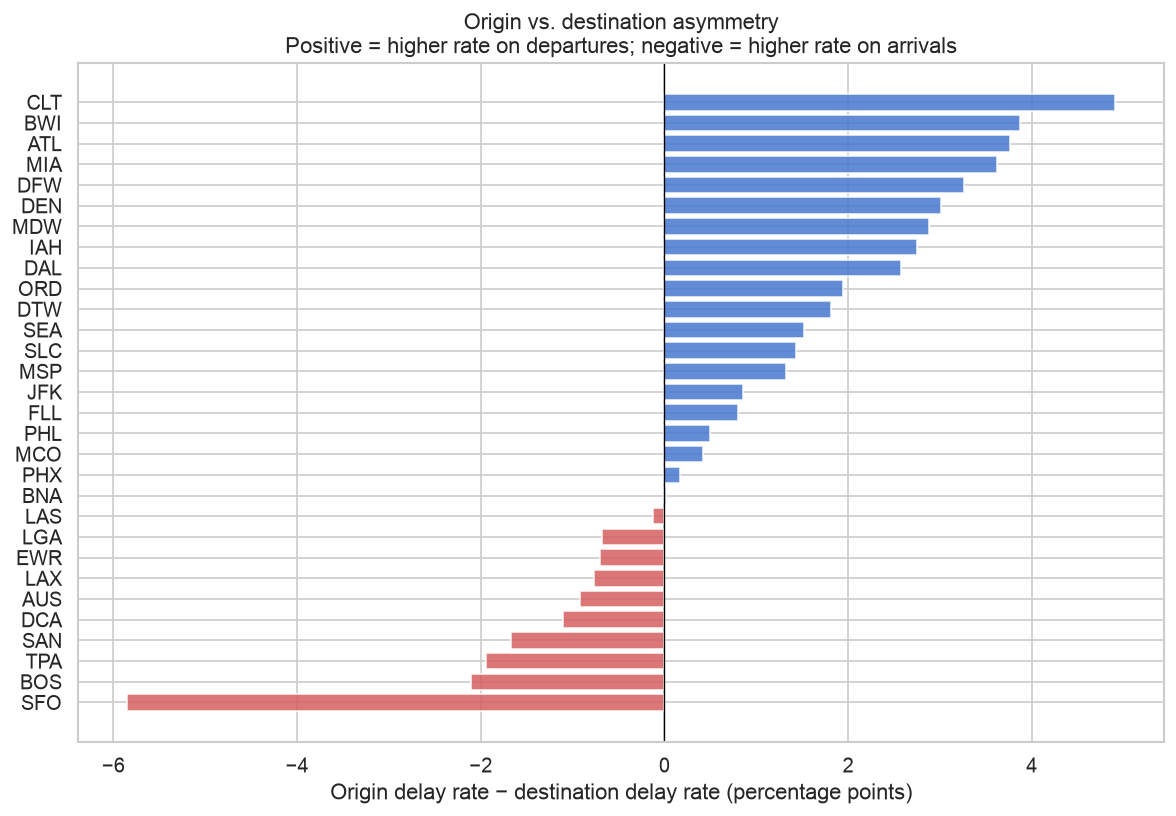

In [14]:
orig_asym = origin_stats.rename(
    columns={"Origin": "Airport", "delay_rate": "orig_rate", "flights": "origin_flights"}
)
dest_asym = destination_stats.rename(
    columns={"Dest": "Airport", "delay_rate": "dest_rate", "flights": "dest_flights"}
)

asym = orig_asym[["Airport", "orig_rate", "origin_flights"]].merge(
    dest_asym[["Airport", "dest_rate", "dest_flights"]],
    on="Airport",
    how="inner",
    validate="one_to_one",
)
asym["diff"] = asym["orig_rate"] - asym["dest_rate"]
asym30 = asym[asym["Airport"].isin(top30_by_vol)].sort_values("diff")

fig, ax = plt.subplots(figsize=(10, 7))
colors_asym = ["#4878CF" if value >= 0 else "#D65F5F" for value in asym30["diff"]]
ax.barh(asym30["Airport"].astype(str), asym30["diff"], color=colors_asym, alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Origin delay rate − destination delay rate (percentage points)")
ax.set_title(
    "Origin vs. destination asymmetry\n"
    "Positive = higher rate on departures; negative = higher rate on arrivals"
)
plt.tight_layout()
fig.savefig(FIGURES / "02c3_origin_dest_asymmetry.png", bbox_inches="tight")
plt.show()

**Findings / summary:** Positive values are consistent with local departure-side
constraints; negative values may reflect delays accumulated elsewhere in the
network, route mix, or carrier mix.


**Modeling implication:** Keep `Origin` and `Dest` as separate categorical
features rather than replacing them with one shared airport effect.


### C4. Delay-cause mix by airport

**Why this analysis:** Compare attributed delay-cause composition across major airports to identify different operational mechanisms.

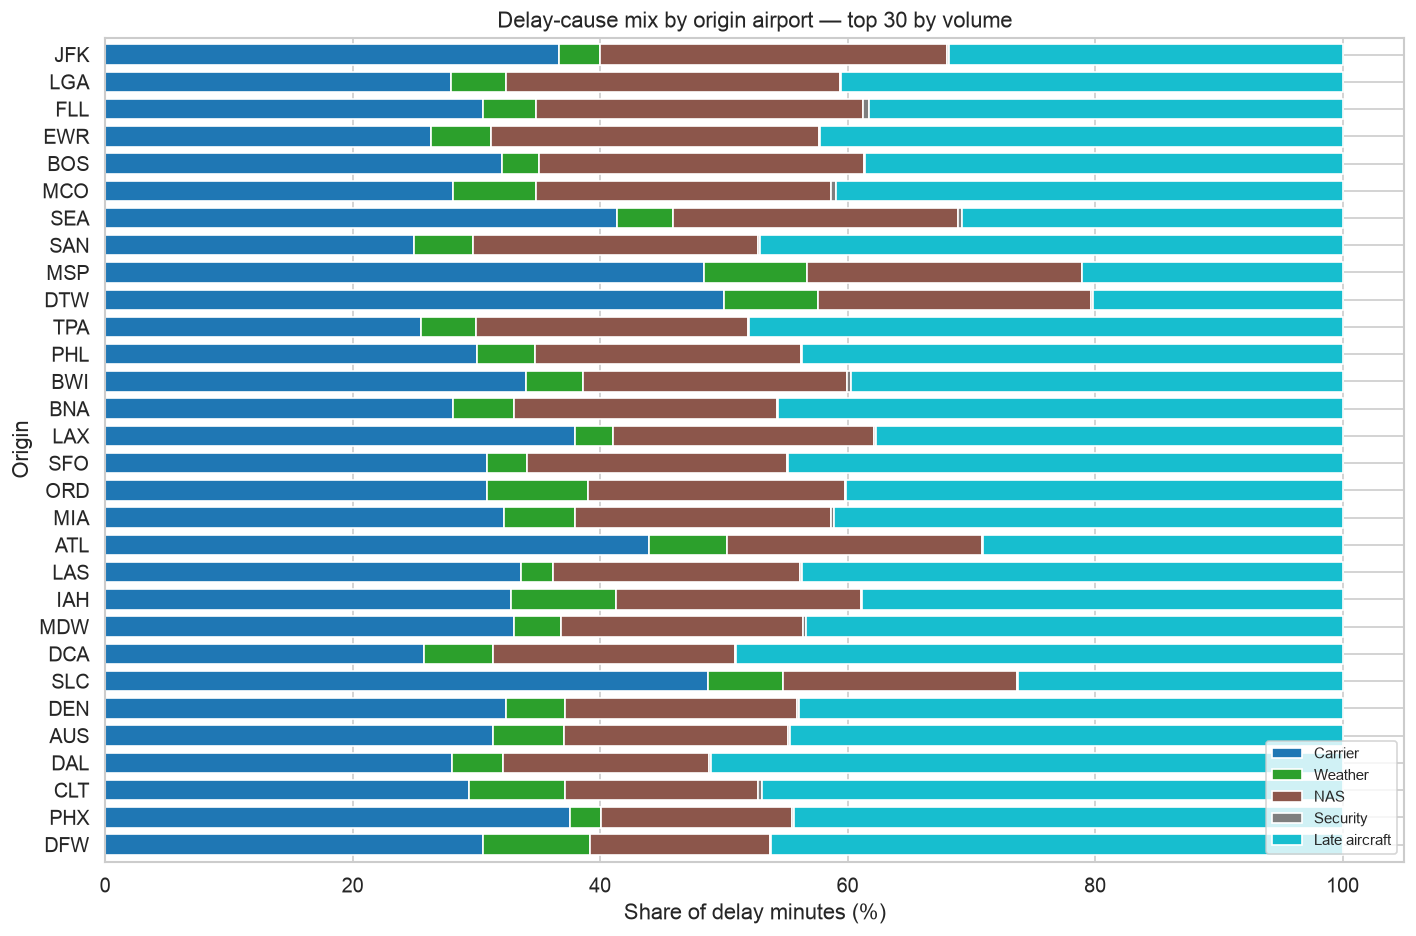

In [15]:
cause_ap = (
    delayed[delayed["Origin"].isin(top30_by_vol)]
    .groupby("Origin", observed=True)[["CarrierDelay", "WeatherDelay", "NASDelay",
                                        "SecurityDelay", "LateAircraftDelay"]]
    .sum(min_count=1)
    .rename(columns={
        "CarrierDelay": "Carrier", "WeatherDelay": "Weather",
        "NASDelay": "NAS", "SecurityDelay": "Security",
        "LateAircraftDelay": "Late aircraft",
    })
)
cause_ap_pct = cause_ap.div(cause_ap.sum(axis=1), axis=0) * 100
cause_ap_pct = cause_ap_pct.loc[cause_ap_pct["NAS"].sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(12, 8))
cause_ap_pct.plot(kind="barh", stacked=True, ax=ax, colormap="tab10", width=0.75)
ax.set_xlabel("Share of delay minutes (%)")
ax.set_title("Delay-cause mix by origin airport — top 30 by volume")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES / "02c4_airport_cause_mix.png", bbox_inches="tight")
plt.show()

**Findings / summary:**
- Late-aircraft delay is the largest component at many airports, showing the
  importance of disruption propagation through the network.
- NAS delay has a larger share at airports such as JFK, LGA, EWR, BOS, and FLL,
  although airport and carrier mix may also influence these differences.
- Carrier-attributed delay is relatively prominent at airports such as DTW,
  MSP, SEA, and SLC.
- Weather generally contributes a smaller share than carrier, NAS, or
  late-aircraft delay, while security delay is negligible.

**Modeling implication:** Delay-cause fields are observed after the delay and must not be used as model
features. The variation supports retaining origin airport, weather, congestion,
carrier, and time-of-day features, including possible interactions. Cause shares
can later help diagnose where and why model errors occur.

### C5. TaxiOut by airport (EDA only)

**Why this analysis:** Compare typical taxi-out time across major origin airports as an observed
indicator of departure-side congestion.

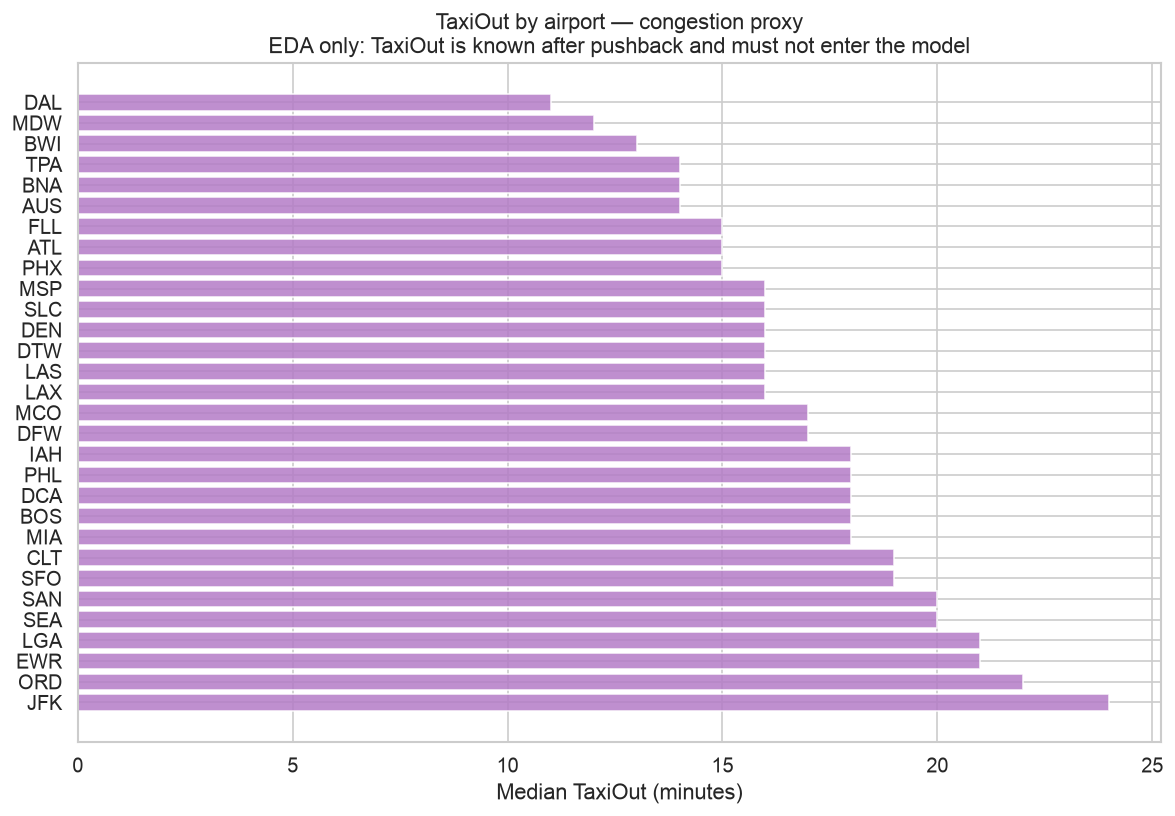

In [16]:
taxi_ap = (
    op[op["Origin"].isin(top30_by_vol) & op["TaxiOut"].notna()]
    .groupby("Origin", observed=True)["TaxiOut"]
    .agg(["mean", "median"])
    .sort_values("median", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(taxi_ap["Origin"].astype(str), taxi_ap["median"], color="#B47CC7", alpha=0.85)
ax.set_xlabel("Median TaxiOut (minutes)")
ax.set_title("TaxiOut by airport — congestion proxy\n"
             "EDA only: TaxiOut is known after pushback and must not enter the model")
plt.tight_layout()
fig.savefig(FIGURES / "02c5_taxiout_by_airport.png", bbox_inches="tight")
plt.show()

**Findings / summary:** 
- Median `TaxiOut` varies from about **11 to 24 minutes** across the top airports.
- JFK has the longest median taxi-out time, followed by ORD, EWR, and LGA. Large hubs with multiple runways and high traffic density tend to have longer taxi-out times.

**Modeling implication:** `TaxiOut` must not enter the model because it is observed after pushback.

### C6. Geographic view — delay rate on a US map

**Why this analysis:** Visualize geographic clustering in airport delay rates and identify regional patterns that are difficult to see in rankings alone.

Coordinate coverage for charted airports: 100.0%
Highest delay rates among top-30 origin airports:
DFW: 28.1% (614,703)
MIA: 27.1% (218,509)
CLT: 26.1% (406,599)
FLL: 25.6% (176,827)
ORD: 25.4% (597,401)
Lowest delay rates among top-30 origin airports:
SLC: 16.8% (228,205)
LAX: 18.4% (381,443)
PHX: 19.6% (387,637)


/var/folders/4q/bcs2wt0906vdhb03j4swyhpc0000gn/T/ipykernel_54299/1975223962.py:66: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/bcs2wt0906vdhb03j4swyhpc0000gn/T/ipykernel_54299/1975223962.py:67: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.savefig(FIGURES / "02c6_airport_map.png", bbox_inches="tight")
/Users/jocelynzhao/bloomberg_case/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


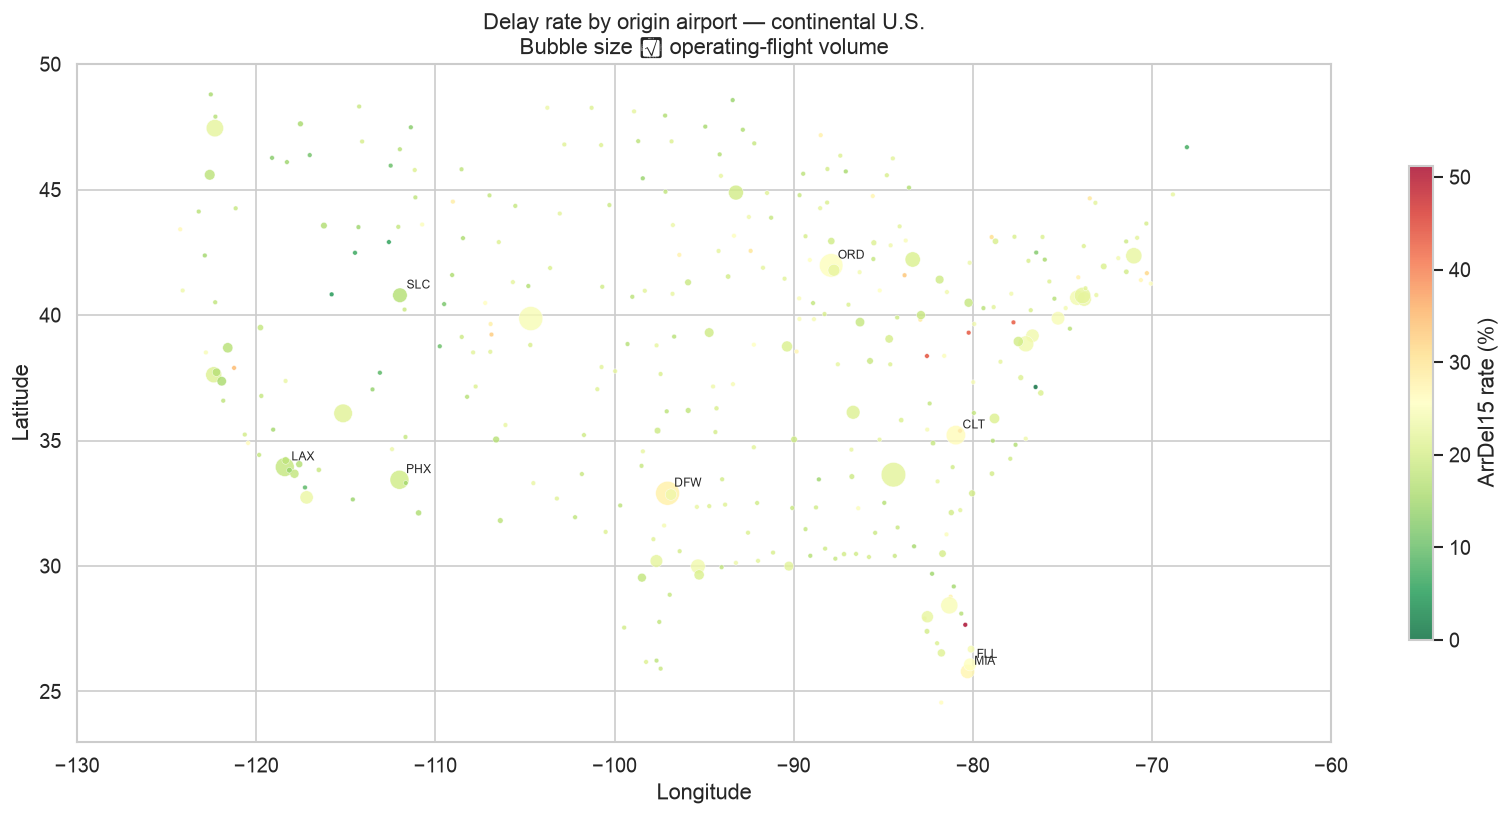

In [17]:
coords = load_airport_coordinates()
ap_map = ap_stats.merge(
    coords,
    left_on="Origin",
    right_on="Airport",
    how="inner",
    validate="one_to_one",
)

coordinate_coverage = len(ap_map) / len(ap_stats)
print(f"Coordinate coverage for charted airports: {coordinate_coverage:.1%}")

# Continental U.S. view; Alaska, Hawaii and territories are omitted from this
# specific panel but remain in every tabular analysis.
ap_map_cont = ap_map[
    ap_map["Longitude"].between(-130, -60)
    & ap_map["Latitude"].between(24, 50)
]

fig, ax = plt.subplots(figsize=(14, 7))
sc = ax.scatter(
    ap_map_cont["Longitude"],
    ap_map_cont["Latitude"],
    c=ap_map_cont["delay_rate"],
    s=np.maximum(ap_map_cont["flights"] / 3000, 8),
    cmap="RdYlGn_r",
    alpha=0.8,
    edgecolors="white",
    linewidths=0.3,
)
plt.colorbar(sc, ax=ax, label="ArrDel15 rate (%)", shrink=0.7)
ax.set_xlim(-130, -60)
ax.set_ylim(23, 50)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Delay rate by origin airport — continental U.S.\n"
    "Bubble size ∝ operating-flight volume"
)

# Label rate extremes only among the top-30 airports by scheduled volume.
# All airports remain visible as bubbles, but sparse airports do not determine labels.
label_pool = ap_map_cont[ap_map_cont["Origin"].isin(top30_by_vol)]

print("Highest delay rates among top-30 origin airports:")
for _, row in label_pool.nlargest(5, "delay_rate").iterrows():
    ax.annotate(
        row["Airport"],
        (row["Longitude"], row["Latitude"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=7,
    )
    print(f"{row['Airport']}: {row['delay_rate']:.1f}% ({row['flights']:,.0f})")

print("Lowest delay rates among top-30 origin airports:")
for _, row in label_pool.nsmallest(3, "delay_rate").iterrows():
    ax.annotate(
        row["Airport"],
        (row["Longitude"], row["Latitude"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=7,
    )
    print(f"{row['Airport']}: {row['delay_rate']:.1f}% ({row['flights']:,.0f})")
plt.tight_layout()
fig.savefig(FIGURES / "02c6_airport_map.png", bbox_inches="tight")
plt.show()

**Findings / summary:**
- Bubble size shows operating-flight volume, so the map distinguishes major hubs
  from sparse airports.
- Labels are restricted to the top-30 origin airports to avoid emphasizing
  unstable extreme rates from very small samples.
- Geographic clustering is descriptive and may reflect airport, carrier,
  route, weather, and schedule mix.


**Modeling implication:** Coordinates are useful for interpretation and timezone lookup; they need not be model features when airport identity is already present.

### C7. New York metro comparison — JFK / LGA / EWR

**Why this analysis:** Compare nearby New York airports to reduce broad regional-weather differences and highlight airport-specific variation.

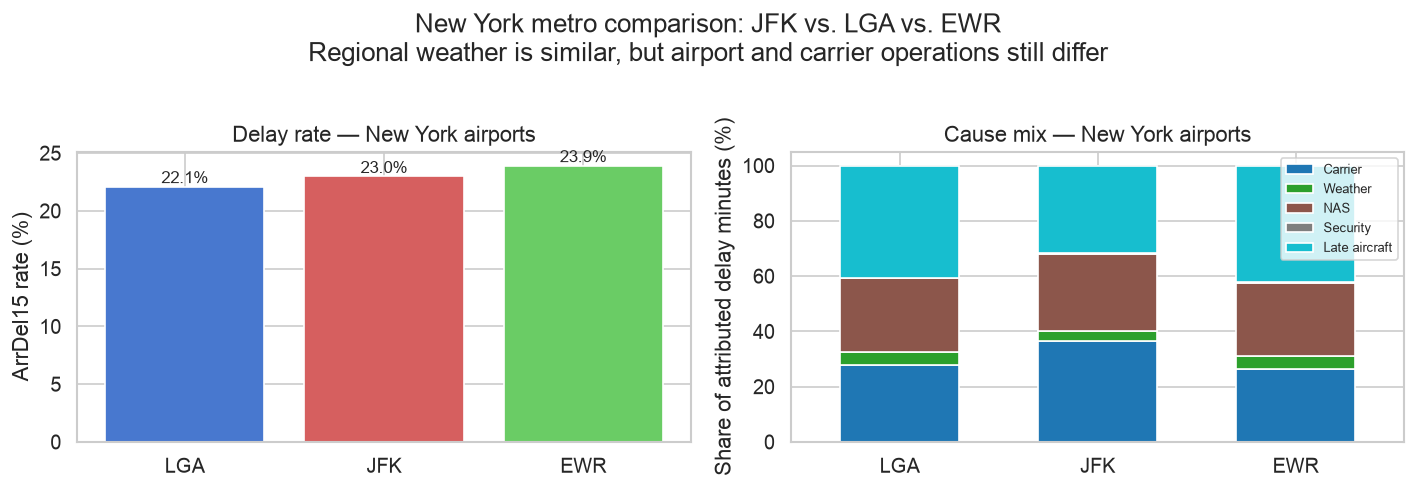

In [18]:
# The current retained schema does not include BTS CityMarketID, so the New York
# metro is defined explicitly. This approximates a city-market comparison and
# keeps the limitation visible.
ny_airports = ["JFK", "LGA", "EWR"]
ny_stats = ap_stats[ap_stats["Origin"].isin(ny_airports)].sort_values("delay_rate")
ny_cause = (
    delayed[delayed["Origin"].isin(ny_airports)]
    .groupby("Origin", observed=True)[
        ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]
    ]
    .sum(min_count=1)
    .rename(
        columns={
            "CarrierDelay": "Carrier",
            "WeatherDelay": "Weather",
            "NASDelay": "NAS",
            "SecurityDelay": "Security",
            "LateAircraftDelay": "Late aircraft",
        }
    )
)
ny_cause_pct = ny_cause.div(ny_cause.sum(axis=1).replace(0, np.nan), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(
    ny_stats["Origin"].astype(str),
    ny_stats["delay_rate"],
    color=["#4878CF", "#D65F5F", "#6ACC65"][: len(ny_stats)],
)
for bar, value in zip(bars, ny_stats["delay_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=10,
    )
ax.set_ylabel("ArrDel15 rate (%)")
ax.set_title("Delay rate — New York airports")

ax = axes[1]
ny_order = ny_stats["Origin"].astype(str).tolist()
ny_cause_pct.reindex(ny_order).plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab10",
    width=0.6,
)
ax.set_xlabel("")
ax.set_ylabel("Share of attributed delay minutes (%)")
ax.set_title("Cause mix — New York airports")
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=0)

fig.suptitle(
    "New York metro comparison: JFK vs. LGA vs. EWR\n"
    "Regional weather is similar, but airport and carrier operations still differ",
    y=1.02,
)
plt.tight_layout()
fig.savefig(FIGURES / "02c7_nyc_comparison.png", bbox_inches="tight")
plt.show()

**Findings / summary:** Delay rates are fairly similar: **22.1% at LGA, 23.0% at JFK, and 23.9% at
  EWR**. The weather and NAS delay shares are similar, but carrier and late-aircraft delay shares differ. 

**Modeling implication:** Regional location alone cannot represent the three airports. Keep airport,
carrier, route, scheduled congestion, time, and weather features separate so
the model can capture their different operating patterns.

### C8. Delay propagation — `LateAircraftDelay` through the day

**Why this analysis:** Test whether late-aircraft delay grows through the day, which would be consistent with cascading network disruption.

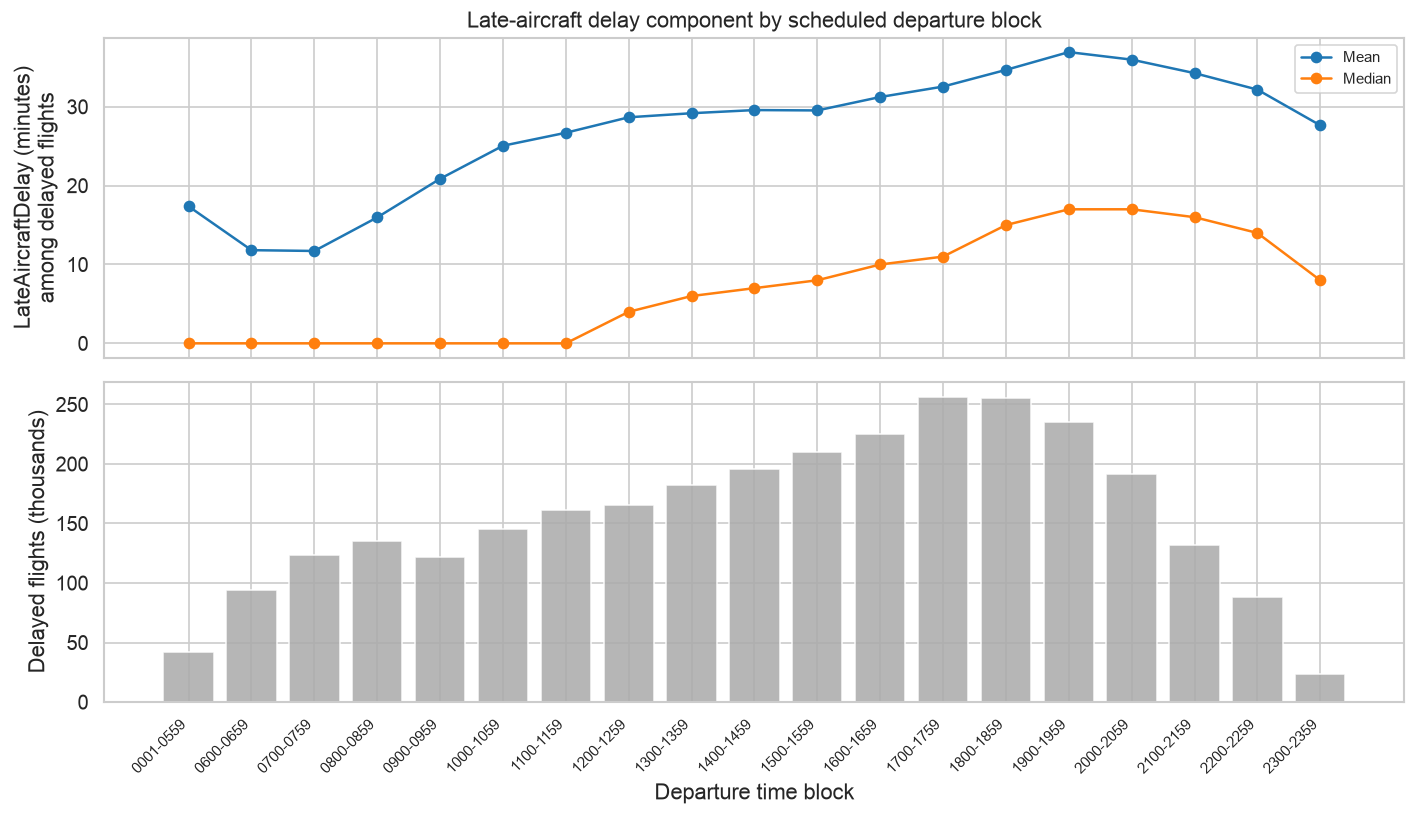

In [19]:
late_ac_day = (
    delayed[
        delayed["LateAircraftDelay"].notna()
        & delayed["DepTimeBlk"].notna()
    ]
    .groupby("DepTimeBlk", observed=True)["LateAircraftDelay"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(
    late_ac_day["DepTimeBlk"].astype(str),
    late_ac_day["mean"],
    marker="o",
    label="Mean",
)
ax.plot(
    late_ac_day["DepTimeBlk"].astype(str),
    late_ac_day["median"],
    marker="o",
    label="Median",
)
ax.set_ylabel("LateAircraftDelay (minutes)\namong delayed flights")
ax.set_title("Late-aircraft delay component by scheduled departure block")
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(
    late_ac_day["DepTimeBlk"].astype(str),
    late_ac_day["count"] / 1e3,
    color="#aaa",
    alpha=0.85,
)
ax.set_ylabel("Delayed flights (thousands)")
ax.set_xlabel("Departure time block")
plt.xticks(rotation=45, ha="right", fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / "02c8_late_aircraft_propagation.png", bbox_inches="tight")
plt.show()

**Findings / summary:**  Both mean and median are shown because a small number of extreme disruptions can dominate the
average.
- Mean late-aircraft delay generally increases through the day, rising from
  roughly 12 minutes in the early morning to about 37 minutes around 19:00.
  This suggests disruption propagation.
- The median is zero through the morning, meaning at least half of delayed
  flights in those blocks have no minutes attributed to a late aircraft.
- From midday onward, the median rises and peaks near 17 minutes around
  19:00–20:59.
- The mean remains well above the median in every block, indicating a
  right-skewed distribution with some very large late-aircraft delays.
- The pattern is consistent with delays accumulating and propagating through
  aircraft rotations as the operating day progresses.
- Delayed-flight counts are highest around 17:00–19:00. Results at the beginning
  and end of the day have less support and should be interpreted cautiously.
- The `0001–0559` category spans several hours, unlike the hourly daytime
  blocks, so its flight count is not directly comparable by block width.

**Modeling implication:** Scheduled departure hour is a legal feature and can capture accumulated network disruption.

---
## Block D — Temporal patterns

**Overall Takeaway:**
- **Scheduled departure time is the strongest calendar pattern:** delay risk
  rises from about 10% in the early morning to roughly 31% in the evening.
- Day of week also matters, with lower rates on Tuesday and Wednesday and
  higher rates on Friday and Sunday.
- Monthly patterns show recurring summer peaks, but substantial differences
  between 2024 and 2025 indicate temporal drift rather than perfectly stable
  seasonality.
- Holiday effects are asymmetric. Delay rates often increase before or after a
  holiday rather than on the holiday itself, but estimates are based on only two
  years and may be influenced by individual disruption events.
- Daily rates contain sharp, sometimes multi-day spikes, showing that major
  system-wide disruptions are not captured by smooth calendar seasonality alone.

**Modeling implication**

Retain scheduled departure time, day of week, month or cyclical seasonal
features, and defined holiday-window features. Time-based validation should be 
used because these relationships change across years. Same-day aggregate
delay rates and post-outcome delay-cause fields must remain diagnostic variables,
not predictors.

### D1. Hour of day

**Why this analysis:** Measure how delay risk changes across scheduled departure time, an
important feature available at the prediction cutoff.

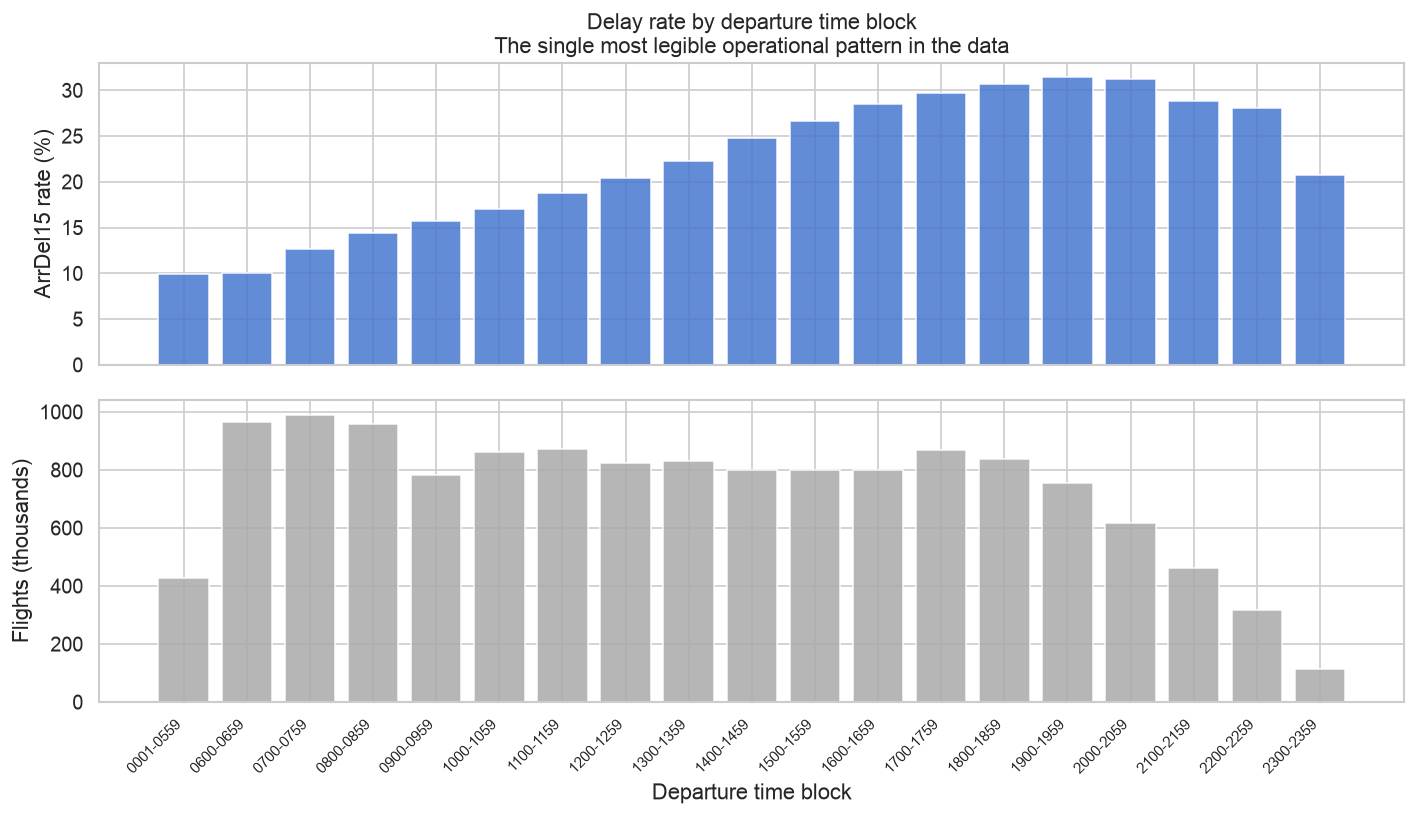

In [20]:
hour_stats = (
    op[op["DepTimeBlk"].notna()]
    .groupby("DepTimeBlk", observed=True)
    .agg(flights=("ArrDel15", "count"), delayed=("ArrDel15", "sum"))
    .assign(delay_rate=lambda d: d["delayed"] / d["flights"] * 100)
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax = axes[0]
ax.bar(hour_stats["DepTimeBlk"].astype(str), hour_stats["delay_rate"],
       color="#4878CF", alpha=0.85)
ax.set_ylabel("ArrDel15 rate (%)")
ax.set_title("Delay rate by departure time block\n"
             "The single most legible operational pattern in the data")

ax = axes[1]
ax.bar(hour_stats["DepTimeBlk"].astype(str), hour_stats["flights"] / 1e3,
       color="#aaa", alpha=0.85)
ax.set_ylabel("Flights (thousands)")
ax.set_xlabel("Departure time block")
plt.xticks(rotation=45, ha="right", fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / "02d1_hour_of_day.png", bbox_inches="tight")
plt.show()

**Findings / summary:** Delay rates rise from roughly 10% in the early morning
to about 25–31% in the evening. This is operationally plausible because aircraft
rotations, airport queues, and earlier disruptions can accumulate through the
day. The chart is descriptive, however: route mix, airport mix, carrier mix,
and demand also vary by departure time.

**Modeling implication:** Scheduled departure time should be included as a core predictor.

### D2. Day of week

**Why this analysis:** Compare arrival delay rates across days of the week to identify recurring schedule-demand patterns.

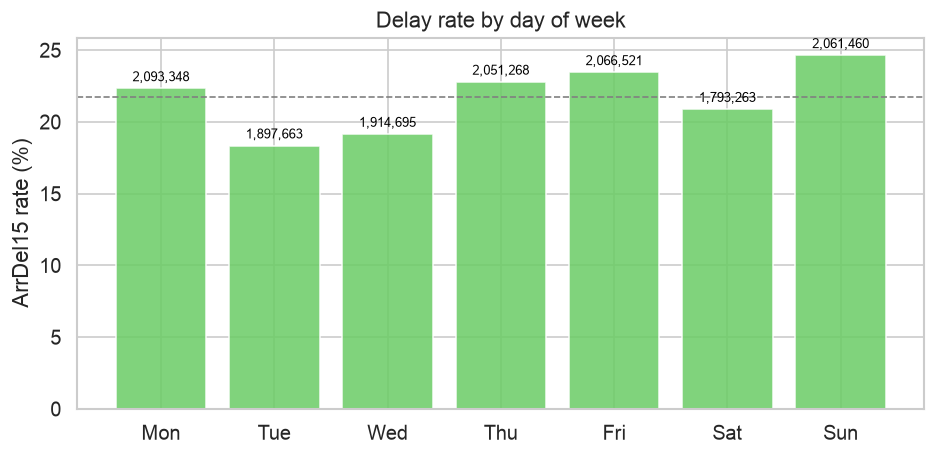

In [21]:
dow_map = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
dow_stats = (
    op.groupby("DayOfWeek")
    .agg(flights=("ArrDel15", "count"), delayed=("ArrDel15", "sum"))
    .assign(delay_rate=lambda d: d["delayed"] / d["flights"] * 100)
    .reset_index()
)
dow_stats["day"] = dow_stats["DayOfWeek"].map(dow_map)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(dow_stats["day"], dow_stats["delay_rate"], color="#6ACC65", alpha=0.85)
for bar, flights in zip(bars, dow_stats["flights"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{int(flights):,}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
    )
ax.set_ylabel("ArrDel15 rate (%)")
ax.set_title("Delay rate by day of week")
ax.axhline(op["ArrDel15"].mean() * 100, color="grey", linestyle="--", lw=1)
plt.tight_layout()
fig.savefig(FIGURES / "02d2_day_of_week.png", bbox_inches="tight")
plt.show()

**Findings / summary:** Day-of-week differences are descriptive and should be read with
flight volume and season.
- Volume is very similar throughout the week.
- Peak: Sunday followed by Friday
- trough: Tuesday followed by Wednesday

**Modeling implication:** Day of week is a low-cost calendar feature; retain it as a categorical feature.
tree models can learn its nonlinear differences.

### D3. Scheduled departure hour × day-of-week interaction

**Why this analysis:** Combine D21 and D22 to see whether time-of-day patterns vary across the week, which would indicate a more complex interaction than either feature alone.

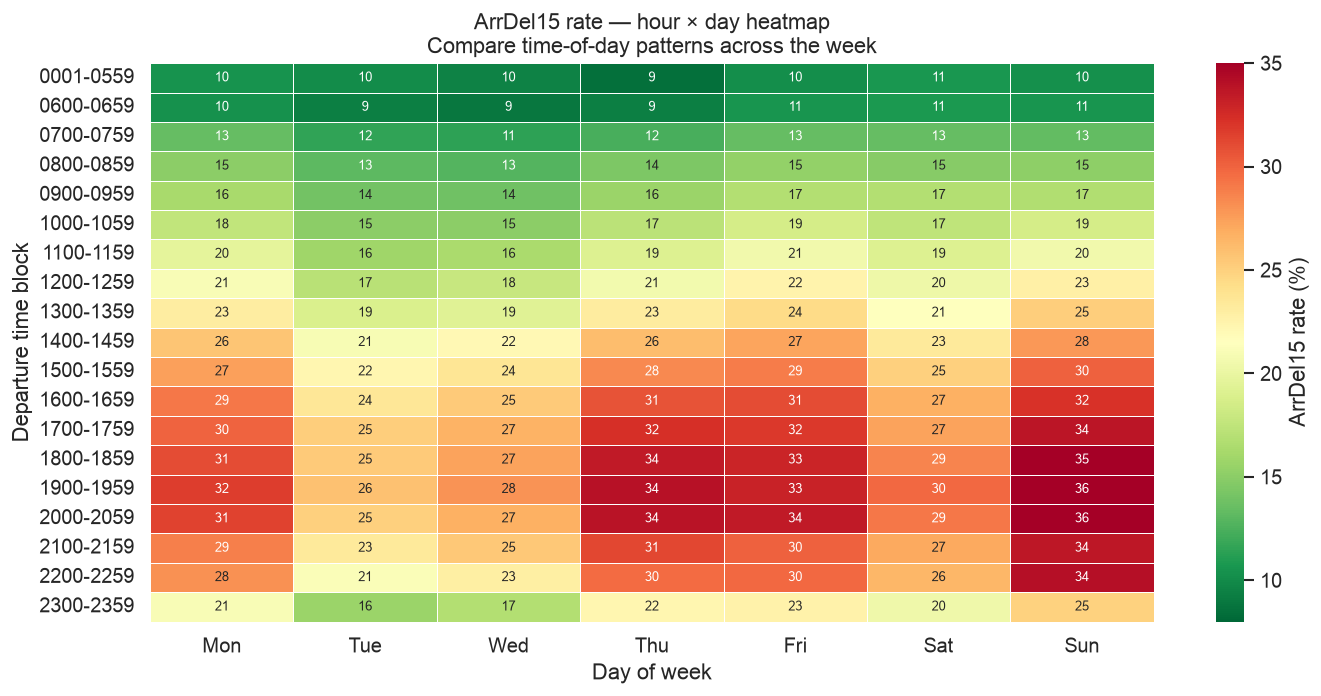

In [22]:
# Aggregate to (DepTimeBlk, DayOfWeek) cells
interaction = (
    op[op["DepTimeBlk"].notna()]
    .groupby(["DepTimeBlk", "DayOfWeek"], observed=True)["ArrDel15"]
    .mean()
    .unstack("DayOfWeek")
    * 100
)
interaction.columns = [dow_map.get(c, c) for c in interaction.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(interaction, ax=ax, cmap="RdYlGn_r", vmin=8, vmax=35,
            annot=True, fmt=".0f", annot_kws={"size": 8},
            linewidths=0.3, cbar_kws={"label": "ArrDel15 rate (%)"})
ax.set_xlabel("Day of week")
ax.set_ylabel("Departure time block")
ax.set_title("ArrDel15 rate — hour × day heatmap\n"
             "Compare time-of-day patterns across the week")
plt.tight_layout()
fig.savefig(FIGURES / "02d3_hour_day_heatmap.png", bbox_inches="tight")
plt.show()

**Findings / summary:**
- Delay risk rises through the day on every weekday, which is operationally
  plausible as congestion and earlier disruptions accumulate.
- Early-morning rates are consistently low at about **9–13%**.
- The highest rates occur on **Sunday evenings**, reaching roughly **34–36%**.
  Thursday and Friday evenings are also elevated.
- Tuesday and Wednesday are generally the lowest-risk days, especially in the
  afternoon and evening.
- The hour-by-day interaction adds information beyond separate hour and weekday
  features; the evening increase is not equally strong on every day.

**Modeling implication:** Tree-based models can learn the hour-by-day interaction directly.

### D4. Month of year

**Why this analysis:** Determine whether arrival-delay rates follow a recurring monthly pattern and whether the pattern is stable across 2024 and 2025. This helps assess the importance of seasonality and identifies possible year-to-year changes that a model may need to handle.

Overall ArrDel15 rate (2024–2025): 21.7%


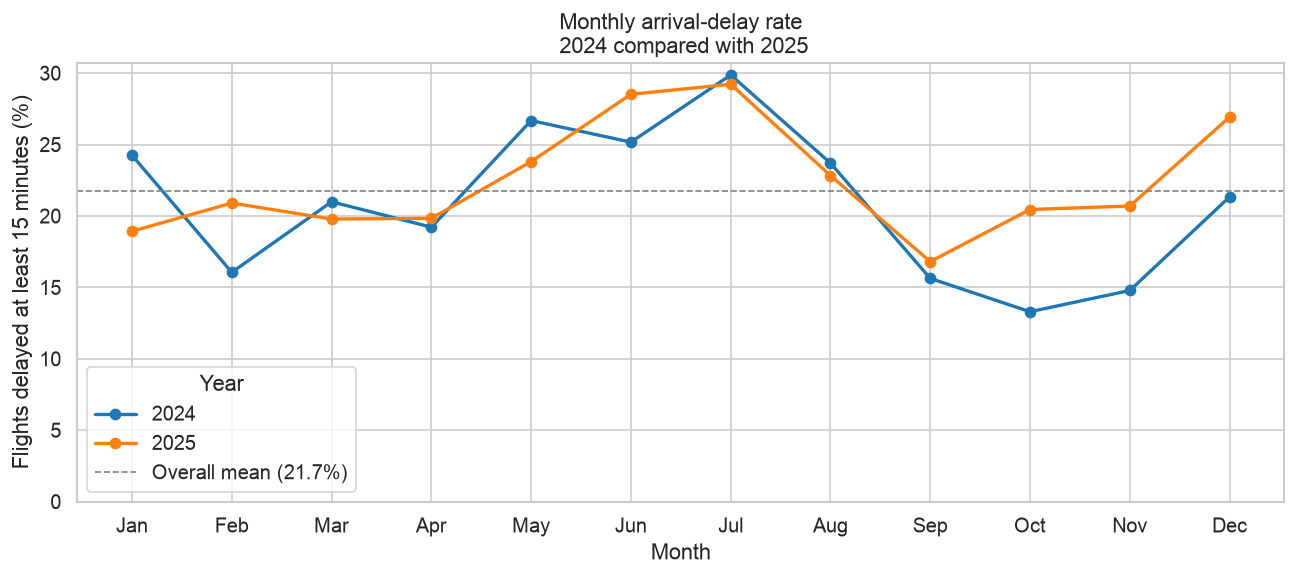

In [23]:
overall_rate = op["ArrDel15"].mean()

monthly_rate = (
    op.groupby(["Year", "Month"], observed=True)
    .agg(flights=("ArrDel15", "count"), delayed=("ArrDel15", "sum"))
    .assign(delay_rate=lambda d: (d["delayed"] / d["flights"] * 100))
    .reset_index()
    .sort_values(["Year", "Month"])
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec",
]

print(f"Overall ArrDel15 rate (2024–2025): {overall_rate:.1%}")

fig, ax = plt.subplots(figsize=(11, 5))

for year, group in monthly_rate.groupby("Year", observed=True):
    group = group.sort_values("Month")
    ax.plot(
        group["Month"],
        group["delay_rate"],
        marker="o",
        markersize=6,
        linewidth=2,
        label=str(year),
    )

ax.axhline(
    overall_rate * 100,
    color="grey",
    linestyle="--",
    linewidth=1,
    label=f"Overall mean ({overall_rate:.1%})",
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Flights delayed at least 15 minutes (%)")
ax.set_title("Monthly arrival-delay rate\n 2024 compared with 2025")
ax.set_ylim(bottom=0)
ax.legend(title="Year")
plt.tight_layout()
fig.savefig(FIGURES / "02d4_delay_rate_by_month.png", bbox_inches="tight")
plt.show()

**Findings / summary:** The overall arrival-delay rate across 2024–2025 is **21.7%**, but monthly rates vary substantially around this average.
- Both years show a pronounced summer increase, with delay rates peaking near **29–30% in July**.
- Delay rates decline sharply after August and are lowest during the early autumn months.
- In 2024, the lowest monthly rate occurs around October, at approximately **13%**.
- In 2025, September is the lowest month, at approximately **17%**, followed by a noticeable increase through October, November, and December.
- The two years display broadly similar movement from spring into the summer peak and then downward into September.

The repeated summer peak suggests a meaningful seasonal pattern. Weather, passenger demand, congestion, and network propagation are plausible mechanisms, but this chart alone does not establish which factors caused the monthly differences. We will examine the other features in later sections.

**Modeling implication:** Month or season should be included as a predictive feature because the baseline probability of an arrival delay changes materially throughout the year.
Useful representations include:
- Month as a categorical feature.
- Interactions between season and weather, airport, or congestion features.

### D5. Holiday periods

**Why this analysis:** Measure delay risk before, on, and after major holidays rather than relying on a single holiday indicator.

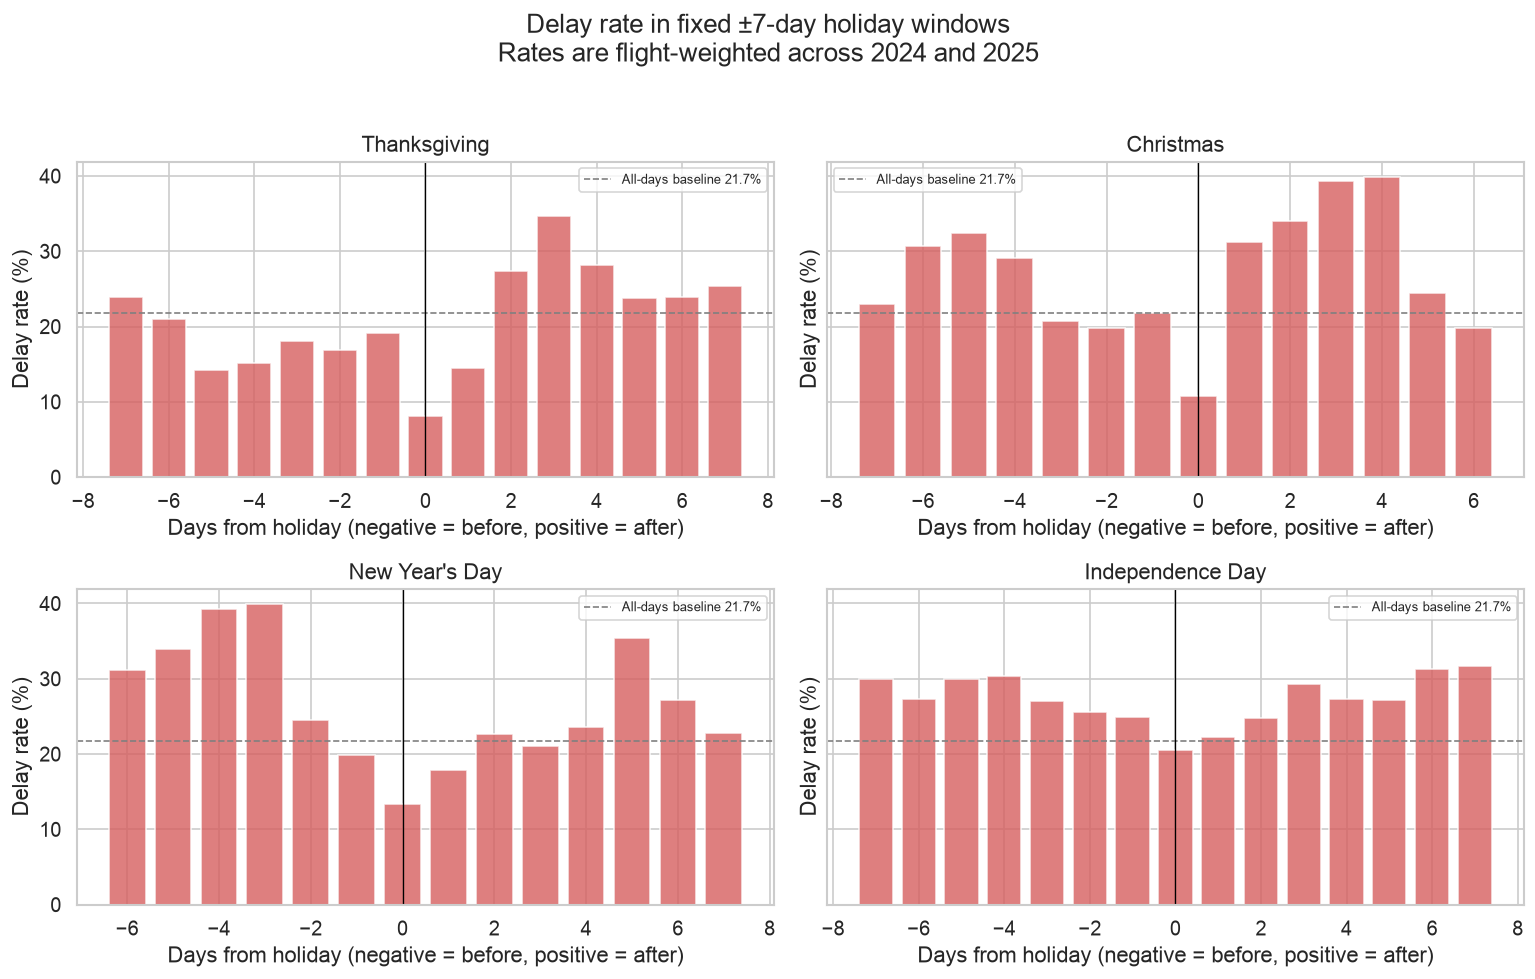

In [24]:
# Aggregate to one row per date before joining the holiday calendar. This avoids
# repeating the same deterministic calendar calculation across millions of rows.
holiday_daily = (
    op.assign(FlightDate=pd.to_datetime(op["FlightDate"]).dt.normalize())
    .groupby("FlightDate")
    .agg(flights=("ArrDel15", "count"), delayed=("ArrDel15", "sum"))
    .assign(delay_rate=lambda d: d["delayed"] / d["flights"] * 100)
    .reset_index()
)
holiday_calendar = build_holiday_calendar(
    holiday_daily["FlightDate"].min(),
    holiday_daily["FlightDate"].max(),
)
holiday_daily = holiday_daily.merge(
    holiday_calendar,
    on="FlightDate",
    how="left",
    validate="one_to_one",
)

def canonical_holiday_name(values):
    values = values.astype("string")
    out = pd.Series(pd.NA, index=values.index, dtype="string")
    out.loc[values.str.contains("Thanksgiving", case=False, na=False)] = "Thanksgiving"
    out.loc[values.str.contains("Christmas", case=False, na=False)] = "Christmas"
    out.loc[values.str.contains("New Year", case=False, na=False)] = "New Year's Day"
    out.loc[values.str.contains("Independence", case=False, na=False)] = "Independence Day"
    return out

before = holiday_daily[
    holiday_daily["days_to_next_holiday"].between(0, 7)
].copy()
before["holiday"] = canonical_holiday_name(before["next_holiday_name"])
before["event_day"] = -before["days_to_next_holiday"].astype(int)

after = holiday_daily[
    holiday_daily["days_since_prev_holiday"].between(0, 7)
].copy()
after["holiday"] = canonical_holiday_name(after["prev_holiday_name"])
after["event_day"] = after["days_since_prev_holiday"].astype(int)

holiday_window = (
    pd.concat([before, after], ignore_index=True)
    .dropna(subset=["holiday"])
    .drop_duplicates(["FlightDate", "holiday", "event_day"])
)

holiday_event = (
    holiday_window.groupby(["holiday", "event_day"], observed=True)
    .agg(flights=("flights", "sum"), delayed=("delayed", "sum"), dates=("FlightDate", "nunique"))
    .assign(delay_rate=lambda d: d["delayed"] / d["flights"] * 100)
    .reset_index()
)

travel_holidays = [
    "Thanksgiving",
    "Christmas",
    "New Year's Day",
    "Independence Day",
]
baseline = op["ArrDel15"].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for ax, holiday in zip(axes.flat, travel_holidays):
    sub = (
        holiday_event[holiday_event["holiday"].eq(holiday)]
        .set_index("event_day")
        .reindex(range(-7, 8))
        .reset_index()
    )
    ax.bar(sub["event_day"], sub["delay_rate"], color="#D65F5F", alpha=0.8)
    ax.axhline(
        baseline,
        color="grey",
        linestyle="--",
        lw=1,
        label=f"All-days baseline {baseline:.1f}%",
    )
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Days from holiday (negative = before, positive = after)")
    ax.set_ylabel("Delay rate (%)")
    ax.set_title(holiday)
    ax.legend(fontsize=8)

fig.suptitle(
    "Delay rate in fixed ±7-day holiday windows\n"
    "Rates are flight-weighted across 2024 and 2025",
    y=1.02,
)
plt.tight_layout()
fig.savefig(FIGURES / "02d5_holiday_patterns.png", bbox_inches="tight")
plt.show()

**Findings / summary:** 
- Holiday-day delay rates are unusually low for Thanksgiving, Christmas, and
  New Year's Day, at roughly 8–13%.
- Risk rises sharply after Thanksgiving and Christmas, reaching about 35–40%
  three to four days later.
- New Year's Day shows the strongest pre-holiday peak, near 40% three to four
  days before the holiday, with another increase around five days afterward.
- Independence Day has a flatter pattern, although most surrounding days are
  above the 21.7% overall baseline.
- Each offset pools only two calendar dates, one per year, so individual storms
  or operational events can strongly affect the bars.

**Modeling implication:** Holidays are leakage-safe calendar features. 
Directional days-to/days-since-holiday features are preferable to a simple `is_holiday` flag.

### D6. Daily time series

**Why this analysis:** Create a daily delay-rate series that reveals both broad seasonality and event-level spikes.

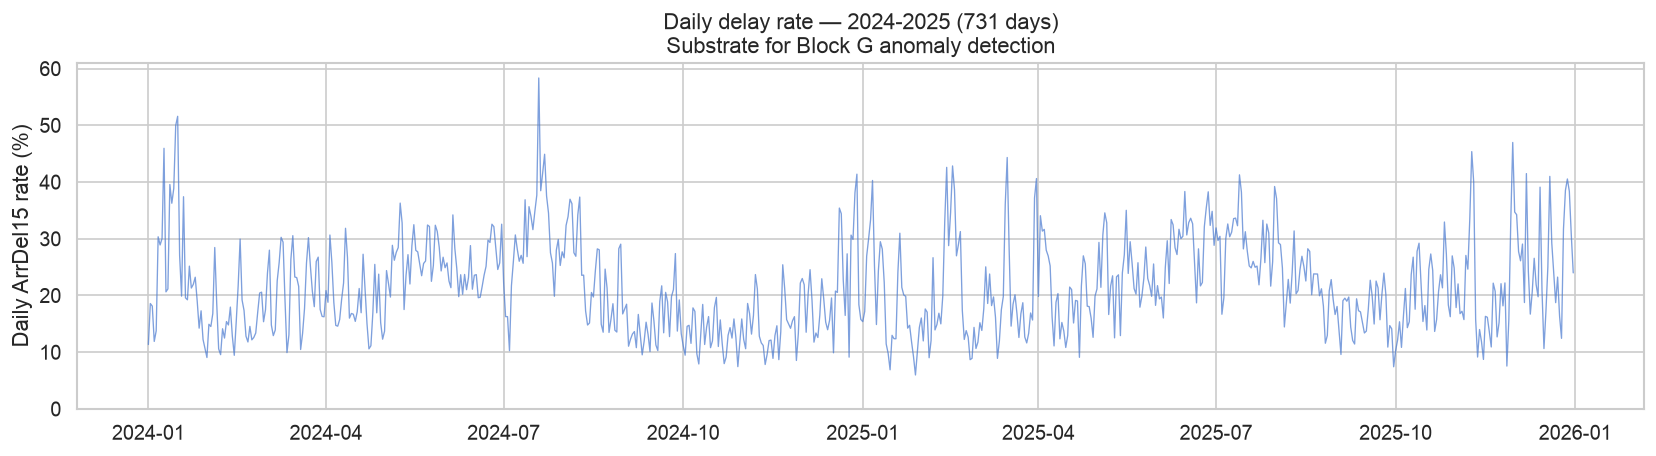

In [25]:
daily_series = (
    op.assign(date=pd.to_datetime(op["FlightDate"]).dt.normalize())
    .groupby("date")
    .agg(flights=("ArrDel15", "count"), delayed=("ArrDel15", "sum"))
    .assign(delay_rate=lambda d: d["delayed"] / d["flights"] * 100)
    .reset_index()
)
daily_series = daily_series.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_series["date"], daily_series["delay_rate"],
        color="#4878CF", lw=0.8, alpha=0.7)
ax.set_ylabel("Daily ArrDel15 rate (%)")
ax.set_title("Daily delay rate — 2024-2025 (731 days)\nSubstrate for Block G anomaly detection")
ax.set_ylim(0, None)
plt.tight_layout()
fig.savefig(FIGURES / "02d6_daily_series.png", bbox_inches="tight")
plt.show()

**Findings / summary:** The daily series retains both broad seasonal movement and
short-lived spikes. Block G identifies statistically unusual dates and only
names causes after date-specific verification.
- Daily delay rates vary widely, from below 10% to nearly 60%.
- The largest spike occurs around July 2024, with additional major spikes in
  January 2024 and late 2025.
- Elevated rates often appear in multi-day clusters rather than isolated days,
  suggesting disruptions can persist across consecutive operating days.
- Lower-delay periods are visible during parts of autumn in both years.
- The series contains seasonal movement and short-lived anomalies, so a single
  overall threshold would not distinguish unusual days reliably.


**Modeling implication:** Calendar features may capture smooth seasonality, but
same-day aggregate delay rates are outcome-time diagnostics and cannot be used
as scheduled-departure predictors.


---
## Block E — Weather

**Overall Takeaway:**
- Weather coverage is strong overall; missingness is concentrated at a small
  number of airports.
- Delay frequency and severity generally worsen with poorer flight category,
  stronger gusts, heavier precipitation, lower visibility, frozen precipitation,
  and thunderstorms.
- Poor weather is especially associated with extreme delay minutes.
- Recent IFR/LIFR conditions remain informative after current weather returns
  to VFR, consistent with lingering operational disruption.
- Origin and destination weather both add signal, with origin weather slightly
  stronger under severe conditions.
- The patterns are operationally plausible and support the weather join, but
  may also reflect airport, carrier, season, congestion, and cancellation mix.

**Modeling implication:**
Use current and lagged origin/destination weather, nonlinear severity features,
and weather-missing indicators for both delay classification and conditional
severity. Validate with time-based splits and audit timestamp alignment.

Some data checks are carried out in `01_data_preparation.ipynb`, Section 2.
We build a more detailed analysis here for 2024–2025 only.

In [26]:
weather_path = Path("data/interim/weather_hourly.parquet")
wx_full = pd.read_parquet(weather_path)
wx_full["hour"] = pd.to_datetime(wx_full["hour"], errors="coerce")
if wx_full["hour"].isna().any():
    raise ValueError("weather_hourly.parquet contains invalid hour values")

wx = wx_full[wx_full["hour"].dt.year.between(2024, 2025)].copy()

required_weather_columns = {
    "airport",
    "hour",
    "observation_time_local",
    "weather_observation_missing",
    "flight_category",
}
missing_weather_columns = required_weather_columns - set(wx.columns)
if missing_weather_columns:
    raise KeyError(
        "Rebuild weather_hourly.parquet with the updated weather.py; missing "
        f"columns: {sorted(missing_weather_columns)}"
    )
if wx.duplicated(["airport", "hour"]).any():
    raise ValueError("weather_hourly.parquet contains duplicate airport-hour rows")

print(f"Weather rows (2024-2025): {len(wx):,}")
print(f"Airports                  : {wx['airport'].nunique():,}")
print(f"Date range                : {wx['hour'].min()} → {wx['hour'].max()}")

weather_cols = list(
    dict.fromkeys(
        [
            "airport",
            "hour",
            "observation_time_local",
            "weather_observation_missing",
            *ORIGIN_WEATHER_COLS,
            *DEST_WEATHER_COLS,
        ]
    )
)
weather_cols = [column for column in weather_cols if column in wx.columns]

op_join = op[
    op["Origin"].notna()
    & op["Dest"].notna()
    & op["CRSDepTime"].notna()
].copy()
op_join["__eda_row_id__"] = np.arange(len(op_join), dtype=np.int64)

op_with_wx = add_weather_features(
    op_join,
    wx[weather_cols],
    join_destination=False,
)
if "origin_weather_age_minutes" not in op_with_wx.columns:
    raise KeyError(
        "Origin weather age was not created. Ensure observation_time_local is "
        "present in the weather parquet and supported by features.py."
    )

future_weather = op_with_wx["origin_weather_age_minutes"].dropna().lt(0)
assert not future_weather.any(), "Origin weather join assigned future observations"
print(
    "Origin weather age (minutes):\n"
    + op_with_wx["origin_weather_age_minutes"]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    .round(1)
    .to_string()
)

Weather rows (2024-2025): 6,350,928
Airports                  : 362
Date range                : 2024-01-01 00:00:00 → 2025-12-31 23:00:00


  weather joined: 13,878,218 rows | origin weather missing 0.1%
Origin weather age (minutes):
count    13866233.0
mean           34.2
std            18.4
min             0.0
50%            34.0
90%            60.0
95%            63.0
99%            67.0
max           143.0


### E1. Coverage and missingness by airport

**Why this analysis:** Verify that leakage-safe weather snapshots cover scheduled departures across
airports and airport-volume groups.

Coverage by 2024 airport-volume band:
airport_size  airports  median_station_missing  flight_weighted_missing
        <500        48                0.004617                 0.006988
   500–4,999       176                0.003904                 0.008917
5,000–49,999        99                0.000627                 0.001562
     50,000+        39                0.000228                 0.000132

Worst flight-level weather coverage:
airport  training_flights  station_missing_rate  flight_missing_rate  median_age_minutes  p95_age_minutes
    BQN            2446.0              0.267100             0.463102                45.0            100.0
    DLG             110.0              0.175730             0.122727                24.0             29.0
    HDN            2516.0              0.155552             0.088735                34.0             59.0
    ADK             104.0              0.104480             0.088083                41.5             59.0
    CSG            1001.0         

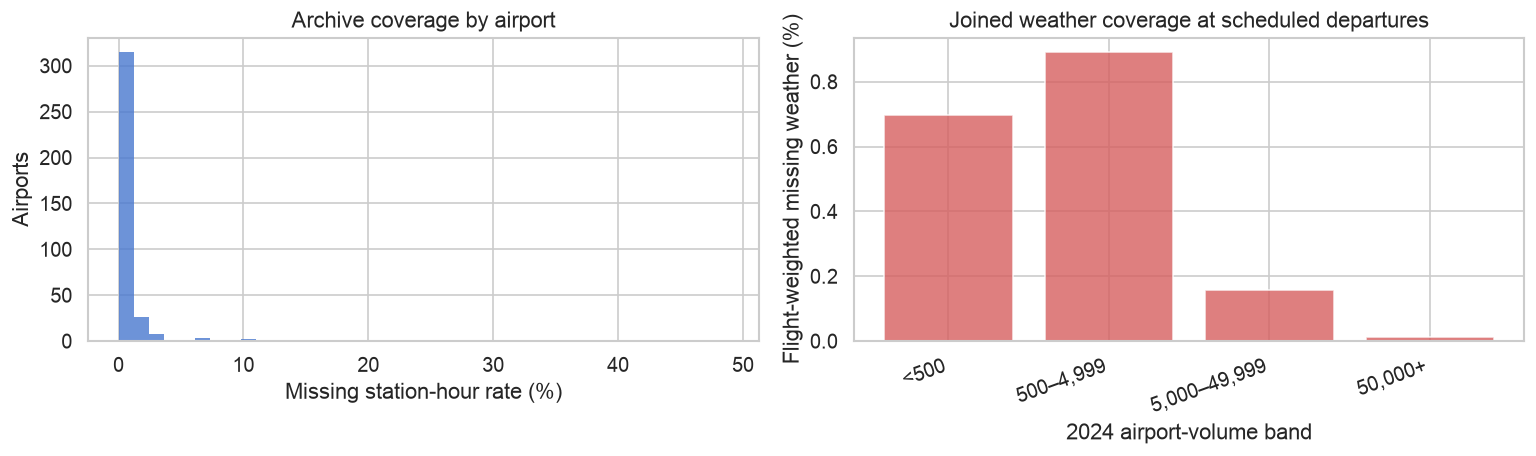

In [27]:
# Station-hour coverage describes the weather archive itself.
station_coverage = (
    wx.assign(
        weather_missing=wx["weather_observation_missing"].fillna(1).astype("float32")
    )
    .groupby("airport", observed=True)
    .agg(
        station_hours=("weather_missing", "size"),
        station_missing_rate=("weather_missing", "mean"),
    )
    .reset_index()
)

# Flight-level coverage weights missingness by when flights are actually scheduled.
flight_coverage = (
    op_with_wx.assign(
        weather_missing=(
            op_with_wx["origin_weather_observation_missing"]
            .fillna(1)
            .astype("float32")
        )
    )
    .groupby("Origin", observed=True)
    .agg(
        flights=("ArrDel15", "size"),
        flight_missing_rate=("weather_missing", "mean"),
        median_age_minutes=("origin_weather_age_minutes", "median"),
        p95_age_minutes=(
            "origin_weather_age_minutes",
            lambda values: values.quantile(0.95),
        ),
    )
    .reset_index()
    .rename(columns={"Origin": "airport"})
)

coverage = station_coverage.merge(
    flight_coverage,
    on="airport",
    how="left",
    validate="one_to_one",
)

train_airport_counts = (
    df.loc[df["Year"].eq(2024)]
    .groupby("Origin", observed=True)
    .size()
    .sort_values()
)
training_counts = train_airport_counts.rename("training_flights").reset_index().rename(
    columns={"Origin": "airport"}
)
coverage = coverage.merge(training_counts, on="airport", how="left")
coverage["airport_size"] = pd.cut(
    coverage["training_flights"].fillna(0),
    bins=[-1, 499, 4_999, 49_999, np.inf],
    labels=["<500", "500–4,999", "5,000–49,999", "50,000+"],
)

coverage_by_size = (
    coverage.groupby("airport_size", observed=True)
    .agg(
        airports=("airport", "size"),
        median_station_missing=("station_missing_rate", "median"),
        flight_weighted_missing=(
            "flight_missing_rate",
            lambda values: np.average(
                values.dropna(),
                weights=coverage.loc[values.dropna().index, "flights"],
            )
            if values.notna().any()
            else np.nan,
        ),
    )
    .reset_index()
)

print("Coverage by 2024 airport-volume band:")
print(coverage_by_size.to_string(index=False))
print("\nWorst flight-level weather coverage:")
print(
    coverage.sort_values("flight_missing_rate", ascending=False)
    .head(15)[
        [
            "airport",
            "training_flights",
            "station_missing_rate",
            "flight_missing_rate",
            "median_age_minutes",
            "p95_age_minutes",
        ]
    ]
    .to_string(index=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(
    coverage["station_missing_rate"] * 100,
    bins=40,
    color="#4878CF",
    alpha=0.8,
    edgecolor="none",
)
ax.set_xlabel("Missing station-hour rate (%)")
ax.set_ylabel("Airports")
ax.set_title("Archive coverage by airport")

ax = axes[1]
size_plot = coverage_by_size.copy()
ax.bar(
    size_plot["airport_size"].astype(str),
    size_plot["flight_weighted_missing"] * 100,
    color="#D65F5F",
    alpha=0.8,
)
ax.set_xlabel("2024 airport-volume band")
ax.set_ylabel("Flight-weighted missing weather (%)")
ax.set_title("Joined weather coverage at scheduled departures")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
fig.savefig(FIGURES / "02e1_weather_coverage.png", bbox_inches="tight")
plt.show()

**Findings / summary:** Station-hour coverage and flight-level coverage answer different
questions. The first evaluates the archive; the second measures how often an
actual scheduled departure receives usable weather. Airport-size bands reveal
whether missingness remains correlated with the model's airport categories.

- Weather coverage is very strong overall, especially at high-volume airports.
- Missingness is higher at smaller airports: about **0.70%** for airports with
  fewer than 500 flights and **0.89%** for airports with 500–4,999 flights.
- Most airports have almost complete station-hour archives; the histogram is
  concentrated near zero missingness.
- A small number of airports are exceptions. BQN has the largest flight-level
  missing rate at about **46%**, followed by DLG at **12%** and HDN/ADK/CSG at
  roughly **8–9%**.
- Flight-level missingness can exceed station-hour missingness when unavailable
  observations occur during periods containing many scheduled flights.
- Typical weather age is approximately 24–45 minutes for the listed airports.
  A flight-level p95 above 90 minutes is possible because the 90-minute archive
  rule is evaluated at the hourly snapshot boundary, not at the flight's exact
  scheduled departure time.

**Modeling implication:** Keep explicit missingness indicators or native missing values so weather absence is not silently treated as benign conditions.
BQN and other high-missingness airports should receive separate sensitivity checks rather than being silently removed.

### E2. Weather-join plausibility check by flight category

**Why this analysis:** Check whether the joined origin-weather conditions show a relationship with arrival delays.

Weather-join diagnostic by origin flight category:
origin_flight_category  flights  delay_rate  weather_plus_nas_per_flight
                   VFR 11713426   20.940116                     3.653643
                  MVFR  1384474   24.445024                     5.586366
                   IFR   516835   29.160370                     8.332669
                  LIFR   244094   29.456275                    10.033413


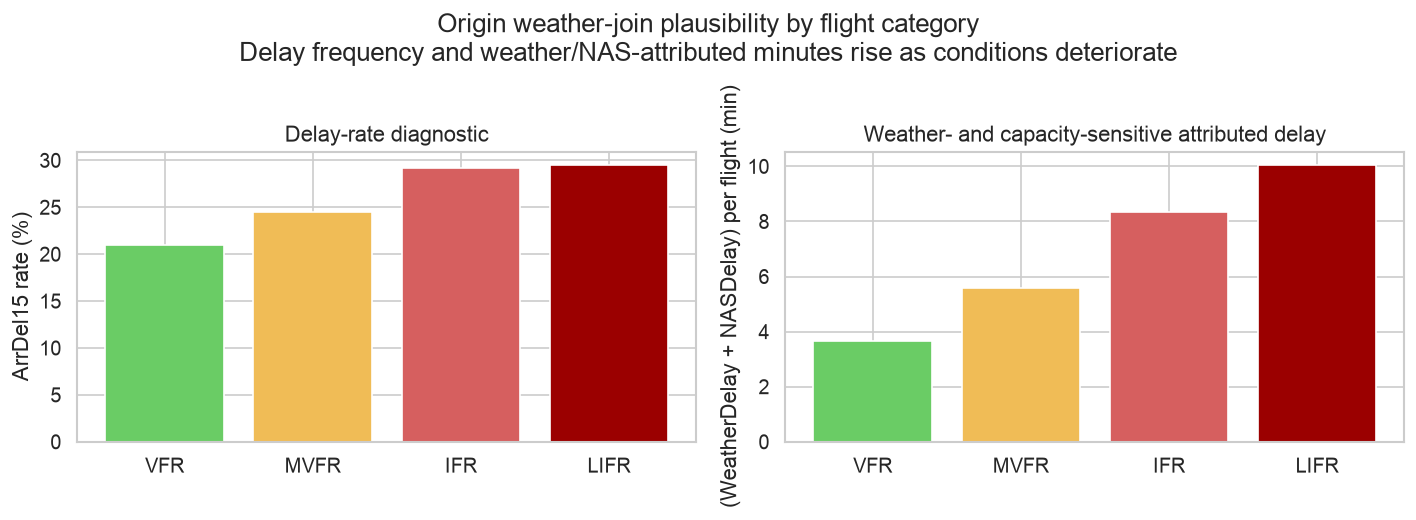

In [28]:
cat_order = ["VFR", "MVFR", "IFR", "LIFR"]

validation_rows = op_with_wx[
    op_with_wx["origin_flight_category"].notna()
].copy()
validation_rows["weather_plus_nas_delay"] = (
    validation_rows["WeatherDelay"].fillna(0)
    + validation_rows["NASDelay"].fillna(0)
)

val_stats = (
    validation_rows.groupby("origin_flight_category", observed=True)
    .agg(
        flights=("ArrDel15", "count"),
        delayed=("ArrDel15", "sum"),
        weather_plus_nas_minutes=("weather_plus_nas_delay", "sum"),
    )
    .assign(
        delay_rate=lambda d: d["delayed"] / d["flights"] * 100,
        weather_plus_nas_per_flight=lambda d: d["weather_plus_nas_minutes"] / d["flights"],
    )
    .reindex(cat_order)
    .reset_index()
)

print("Weather-join diagnostic by origin flight category:")
print(
    val_stats[
        [
            "origin_flight_category",
            "flights",
            "delay_rate",
            "weather_plus_nas_per_flight",
        ]
    ].to_string(index=False)
)

vfr_rate = val_stats.loc[
    val_stats["origin_flight_category"].eq("VFR"), "delay_rate"
].squeeze()
ifr_worse_rate = (
    validation_rows[
        validation_rows["origin_flight_category"].astype("string").isin(["IFR", "LIFR"])
    ]["ArrDel15"].mean()
    * 100
)
if pd.notna(vfr_rate) and pd.notna(ifr_worse_rate) and ifr_worse_rate <= vfr_rate:
    warnings.warn(
        "IFR/LIFR delay rate is not above VFR. Recheck timezone conversion, "
        "station mapping, weather age, missingness, and airport mix before "
        "interpreting weather results."
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = ["#6ACC65", "#F0BC56", "#D65F5F", "#9B0000"]

ax = axes[0]
ax.bar(val_stats["origin_flight_category"], val_stats["delay_rate"], color=palette)
ax.set_ylabel("ArrDel15 rate (%)")
ax.set_title("Delay-rate diagnostic")

ax = axes[1]
ax.bar(
    val_stats["origin_flight_category"],
    val_stats["weather_plus_nas_per_flight"],
    color=palette,
)
ax.set_ylabel("(WeatherDelay + NASDelay) per flight (min)")
ax.set_title("Weather- and capacity-sensitive attributed delay")

fig.suptitle(
    "Origin weather-join plausibility by flight category\n"
    "Delay frequency and weather/NAS-attributed minutes rise as conditions deteriorate",
    y=1.02,
)
plt.tight_layout()
fig.savefig(FIGURES / "02e2_join_validation.png", bbox_inches="tight")
plt.show()

**Findings / summary:** 
- Delay risk increases as flight conditions deteriorate, which is operationally plausible.
- IFR and LIFR have similar delay frequencies, but LIFR has greater attributed delay severity.
- Every category has substantial support, including more than 244,000 LIFR
  flights, so the pattern is not driven by a very small group.
- The ordered relationship is operationally plausible and supports the weather
  join, but it does not prove that every airport-hour match is correct.

**Modeling implication:** Flight category and its underlying weather measurements are promising
scheduled-departure predictors.

### E3. Delay rate and mean delay by flight category

**Why this analysis:** Summarize delay frequency and magnitude across ordered aviation weather categories.

Conditional arrival-delay severity by origin flight category
origin_flight_category delayed_flights mean_delay median_delay p90_delay
                   VFR       2,452,805       73.3         42.0     152.0
                  MVFR         338,435       77.7         44.0     164.0
                   IFR         150,711       83.2         47.0     178.0
                  LIFR          71,901       91.8         50.0     199.0


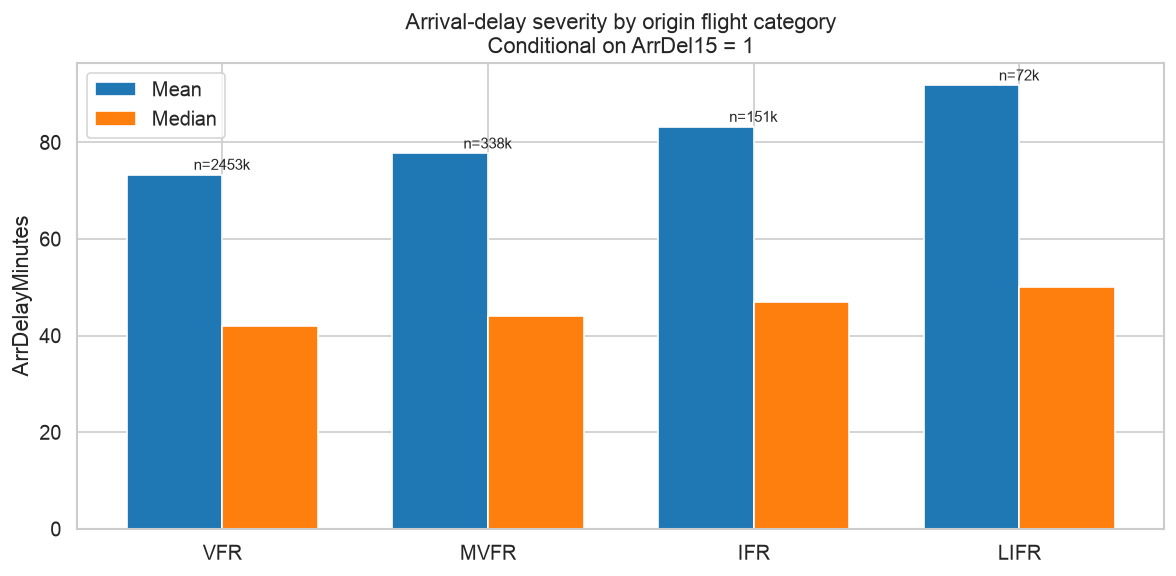

In [29]:
severity_rows = validation_rows[
    validation_rows["ArrDel15"].eq(1)
    & validation_rows["ArrDelayMinutes"].notna()
].copy()
severity_stats = (
    severity_rows.groupby(
        "origin_flight_category",
        observed=True,
    )
    .agg(
        delayed_flights=("ArrDelayMinutes", "size"),
        mean_delay=("ArrDelayMinutes", "mean"),
        median_delay=("ArrDelayMinutes", "median"),
        p90_delay=(
            "ArrDelayMinutes",
            lambda x: x.quantile(0.90),
        ),
    )
    .reindex(cat_order)
    .reset_index()
)
print("Conditional arrival-delay severity by origin flight category")
print(
    severity_stats.to_string(
        index=False,
        formatters={
            "delayed_flights": lambda x: f"{x:,.0f}",
            "mean_delay": lambda x: f"{x:.1f}",
            "median_delay": lambda x: f"{x:.1f}",
            "p90_delay": lambda x: f"{x:.1f}",
        },
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cat_order))
width = 0.36
mean_bars = ax.bar(
    x - width / 2,
    severity_stats["mean_delay"],
    width,
    label="Mean",
)
median_bars = ax.bar(
    x + width / 2,
    severity_stats["median_delay"],
    width,
    label="Median",
)
for index, count in enumerate(
    severity_stats["delayed_flights"]
):
    height = max(
        severity_stats.loc[index, "mean_delay"],
        severity_stats.loc[index, "median_delay"],
    )
    ax.text(
        index,
        height + 1,
        f"n={count / 1e3:.0f}k",
        ha="center",
        fontsize=9,
    )
ax.set_xticks(x)
ax.set_xticklabels(cat_order)
ax.set_ylabel("ArrDelayMinutes")
ax.set_title(
    "Arrival-delay severity by origin flight category\n"
    "Conditional on ArrDel15 = 1"
)
ax.legend()
plt.tight_layout()
fig.savefig(
    FIGURES / "02e3_conditional_delay_severity.png",
    bbox_inches="tight",
)
plt.show()

**Findings / summary:**
- Mean delay is much higher than median delay in every category, which makes
  sense for a right-skewed delay distribution containing a small number of very
  severe disruptions.
- The 90th percentile increases more strongly, from **152 to 199 minutes**.
  This suggests poor weather is particularly associated with extreme delays.
- The small difference between IFR and LIFR delay frequency in E28, combined
  with the larger severity difference here, suggests LIFR may not make many more
  flights cross the 15-minute threshold, but may make already-delayed flights
  substantially worse.

**Modeling implication:** Origin flight category is relevant to Stage 2 severity modeling as well as
Stage 1 delay classification.

### E4. Delay rate vs. weather intensity (combines former E30–E32)

**Why this analysis:** Compare arrival-delay frequency and magnitude across increasingly severe wind, precipitation,
visibility, precipitation phase, and thunderstorm conditions.

In [30]:
weather = op_with_wx[
    op_with_wx["origin_weather_observation_missing"].eq(0)
].copy()

weather["delay_if_delayed"] = weather["ArrDelayMinutes"].where(
    weather["ArrDel15"].eq(1)
)
weather["gust_for_analysis"] = weather["origin_wind_gust_kt"].fillna(0)

weather["gust_bin"] = pd.cut(
    weather["gust_for_analysis"],
    [-0.01, 10, 20, 30, 40, np.inf],
    labels=["0–10", "10–20", "20–30", "30–40", "40+"],
    right=False,
)
weather["precip_bin"] = pd.cut(
    weather["origin_precip_mm"],
    [-0.001, 0.001, 1, 3, 6, np.inf],
    labels=["0", "trace–1", "1–3", "3–6", "6+"],
    right=False,
)
weather["vis_bin"] = pd.cut(
    weather["origin_visibility_sm"],
    [-np.inf, 1, 3, 5, 10, np.inf],
    labels=["<1", "1–3", "3–5", "5–10", "10+"],
    right=False,
)

# Precipitation phase near freezing.
phase = weather[
    weather["origin_frozen_precip"].notna()
    & weather["origin_temp_c"].between(-5, 5)
].copy()

phase["precip_phase"] = pd.Series(pd.NA, index=phase.index, dtype="string")
phase.loc[phase["origin_frozen_precip"].eq(1), "precip_phase"] = "Frozen"
phase.loc[
    phase["origin_frozen_precip"].eq(0)
    & phase["origin_precip_mm"].gt(0),
    "precip_phase",
] = "Liquid"
phase = phase.dropna(subset=["precip_phase"])
phase["precip_phase"] = pd.Categorical(
    phase["precip_phase"], ["Liquid", "Frozen"], ordered=True
)

# Thunderstorm comparison.
thunder = weather.dropna(subset=["origin_thunderstorm"]).copy()
thunder["thunderstorm_condition"] = np.where(
    thunder["origin_thunderstorm"].eq(1),
    "Thunderstorm",
    "No thunderstorm",
)
thunder["thunderstorm_condition"] = pd.Categorical(
    thunder["thunderstorm_condition"],
    ["No thunderstorm", "Thunderstorm"],
    ordered=True,
)


def summarize_weather(frame, group):
    return (
        frame.dropna(subset=[group, "ArrDel15"])
        .groupby(group, observed=True)
        .agg(
            flights=("ArrDel15", "size"),
            delayed_flights=("delay_if_delayed", "count"),
            delay_rate=("ArrDel15", "mean"),
            mean_delay=("delay_if_delayed", "mean"),
            median_delay=("delay_if_delayed", "median"),
            p90_delay=("delay_if_delayed", lambda x: x.quantile(0.90)),
        )
        .assign(delay_rate_pct=lambda x: 100 * x["delay_rate"])
        .reset_index()
    )


panels = [
    ("gust_bin", weather, "Wind gust", "Wind gust (kt)"),
    ("precip_bin", weather, "Precipitation", "Hourly precipitation (mm)"),
    ("vis_bin", weather, "Visibility", "Visibility (statute miles)"),
    ("precip_phase", phase, "Precipitation phase", "Phase at −5°C to +5°C"),
    (
        "thunderstorm_condition",
        thunder,
        "Thunderstorms",
        "Reported thunderstorm",
    ),
]

weather_results = {
    group: summarize_weather(frame, group)
    for group, frame, _, _ in panels
}

In [31]:
print("E4 — Delay frequency and conditional severity by origin weather")
print("-" * 88)

for group, _, title, _ in panels:
    table = weather_results[group]

    print(f"\n{title}")
    print(
        table[
            [
                group, "flights", "delayed_flights", "delay_rate_pct",
                "mean_delay", "median_delay", "p90_delay",
            ]
        ].to_string(
            index=False,
            formatters={
                "flights": lambda x: f"{x:,.0f}",
                "delayed_flights": lambda x: f"{x:,.0f}",
                "delay_rate_pct": lambda x: f"{x:.1f}%",
                "mean_delay": lambda x: f"{x:.1f}",
                "median_delay": lambda x: f"{x:.1f}",
                "p90_delay": lambda x: f"{x:.1f}",
            },
        )
    )

E4 — Delay frequency and conditional severity by origin weather
----------------------------------------------------------------------------------------

Wind gust
gust_bin    flights delayed_flights delay_rate_pct mean_delay median_delay p90_delay
    0–10 11,469,963       2,383,410          20.8%       74.3         42.0     155.0
   10–20    796,983         198,411          24.9%       73.9         43.0     156.0
   20–30  1,347,164         350,488          26.0%       76.3         45.0     160.0
   30–40    232,484          74,525          32.1%       81.0         48.0     170.0
     40+     19,639           8,883          45.2%       97.9         57.0     204.0

Precipitation
precip_bin    flights delayed_flights delay_rate_pct mean_delay median_delay p90_delay
         0 13,225,288       2,775,032          21.0%       73.5         42.0     153.0
   trace–1    343,099         116,108          33.8%       83.3         49.0     175.0
       1–3    189,295          70,477          37.

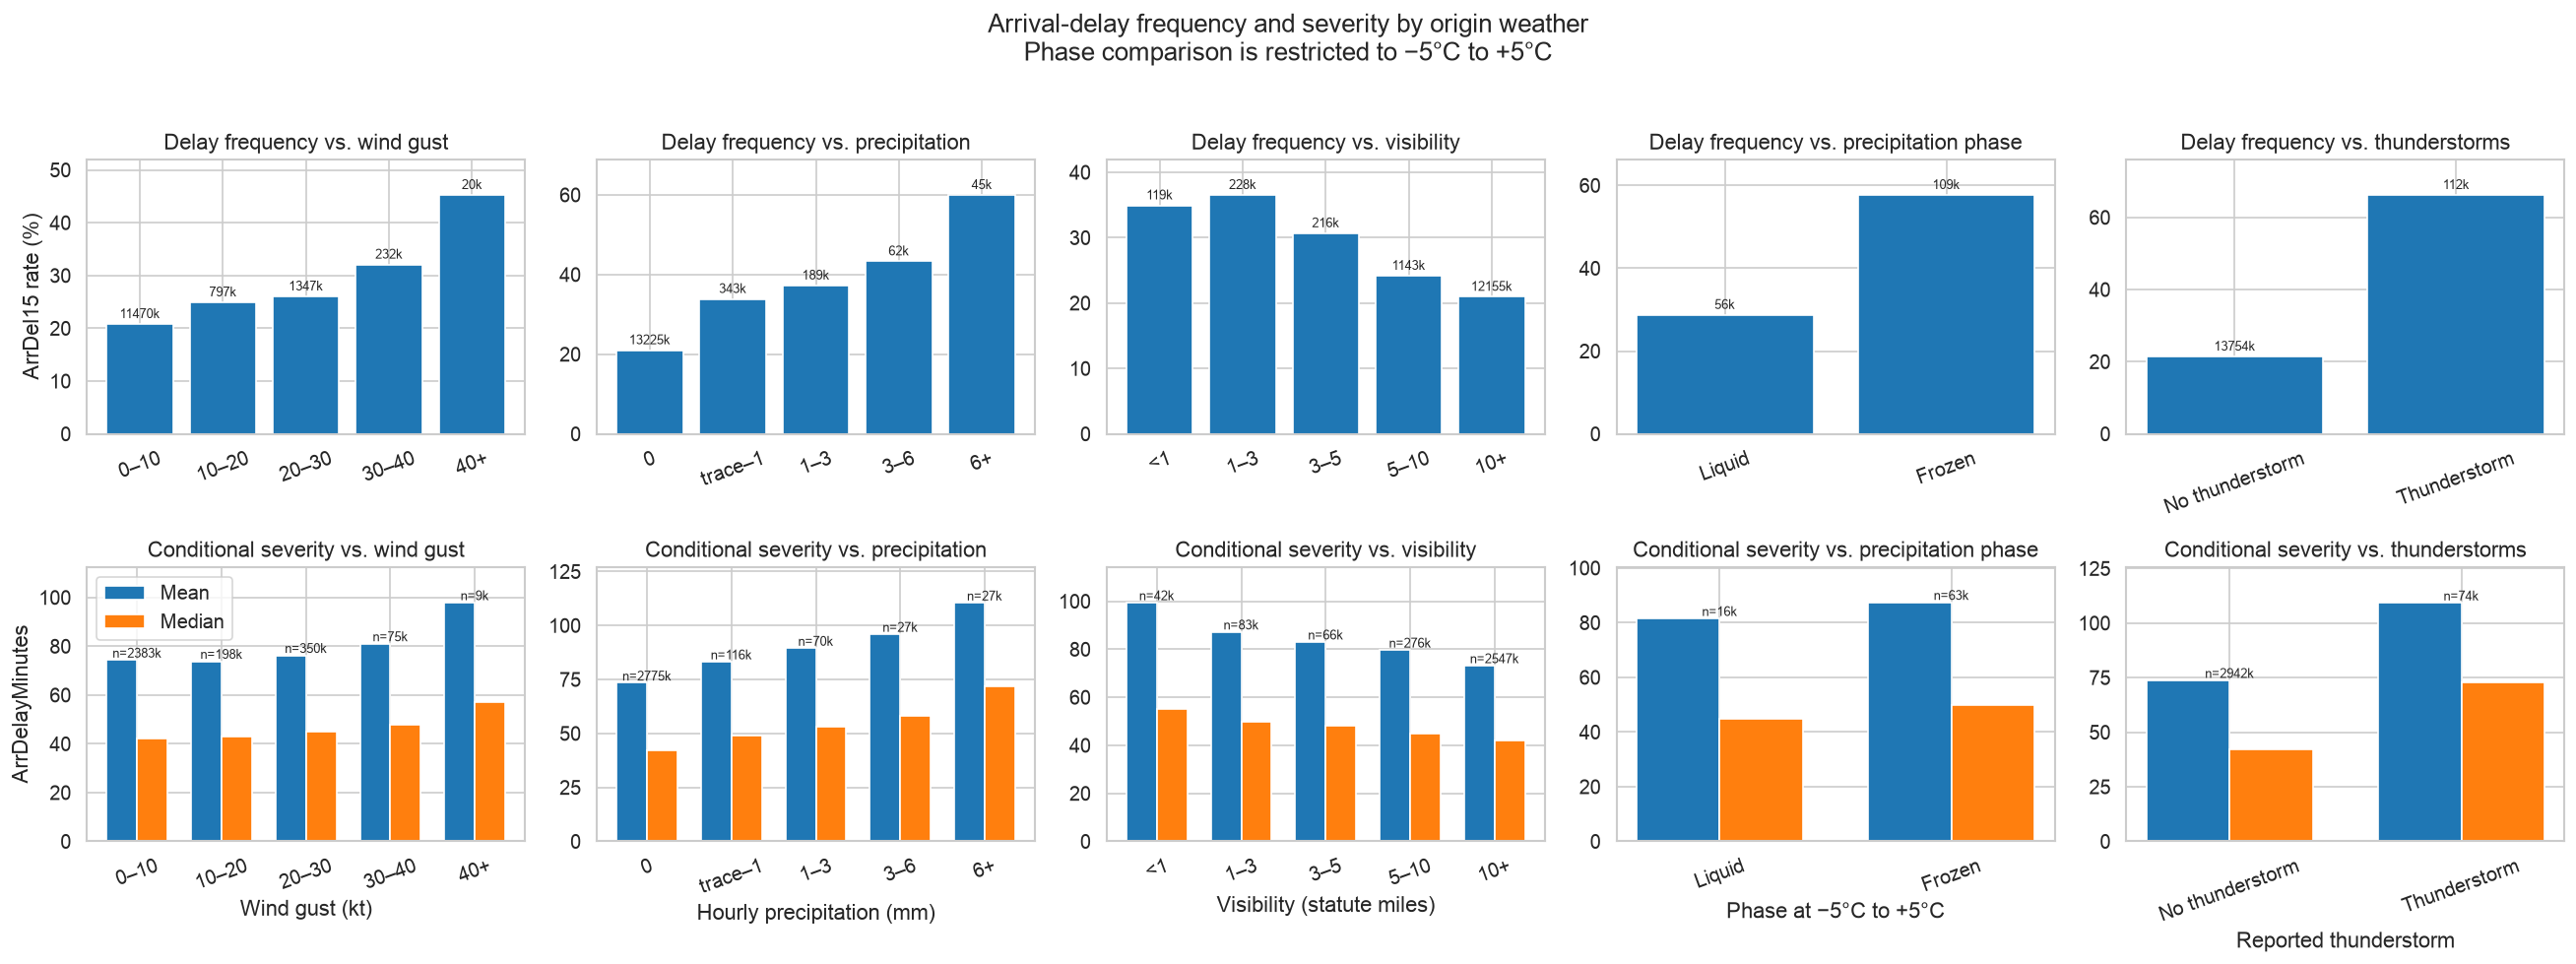

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for j, (group, _, title, xlabel) in enumerate(panels):
    table = weather_results[group]
    x = np.arange(len(table))
    labels = table[group].astype(str)

    # Stage 1: delay frequency.
    bars = axes[0, j].bar(x, table["delay_rate_pct"])
    axes[0, j].bar_label(
        bars,
        labels=[f"{n / 1e3:.0f}k" for n in table["flights"]],
        padding=2,
        fontsize=8,
    )
    axes[0, j].set_title(f"Delay frequency vs. {title.lower()}")
    axes[0, j].set_ylabel("ArrDel15 rate (%)" if j == 0 else "")
    axes[0, j].set_xticks(x, labels, rotation=20)
    axes[0, j].margins(y=0.15)

    # Stage 2: severity conditional on ArrDel15 = 1.
    width = 0.36
    axes[1, j].bar(
        x - width / 2, table["mean_delay"], width, label="Mean"
    )
    axes[1, j].bar(
        x + width / 2, table["median_delay"], width, label="Median"
    )

    for i, row in table.iterrows():
        axes[1, j].text(
            i,
            max(row["mean_delay"], row["median_delay"]) + 1,
            f"n={row['delayed_flights'] / 1e3:.0f}k",
            ha="center",
            fontsize=8,
        )

    axes[1, j].set_title(f"Conditional severity vs. {title.lower()}")
    axes[1, j].set_xlabel(xlabel)
    axes[1, j].set_ylabel("ArrDelayMinutes" if j == 0 else "")
    axes[1, j].set_xticks(x, labels, rotation=20)
    axes[1, j].margins(y=0.15)

axes[1, 0].legend()

fig.suptitle(
    "Arrival-delay frequency and severity by origin weather\n"
    "Phase comparison is restricted to −5°C to +5°C",
    y=1.02,
)
plt.tight_layout()
fig.savefig(
    FIGURES / "02e4_weather_frequency_severity.png",
    bbox_inches="tight",
)
plt.show()


Thunderstorm exposure by month
 Month   flights thunderstorm_flights thunderstorm_share_pct
     1 1,049,100                1,239               0.118101
     2 1,012,818                  983               0.097056
     3 1,178,842                5,030                0.42669
     4 1,156,053                6,961               0.602135
     5 1,199,643               16,730               1.394582
     6 1,203,973               19,832               1.647213
     7 1,230,935               26,658               2.165671
     8 1,201,059               19,472               1.621236
     9 1,137,281                9,445                0.83049
    10 1,210,633                2,418                0.19973
    11 1,127,432                1,850                0.16409
    12 1,158,464                1,521               0.131295


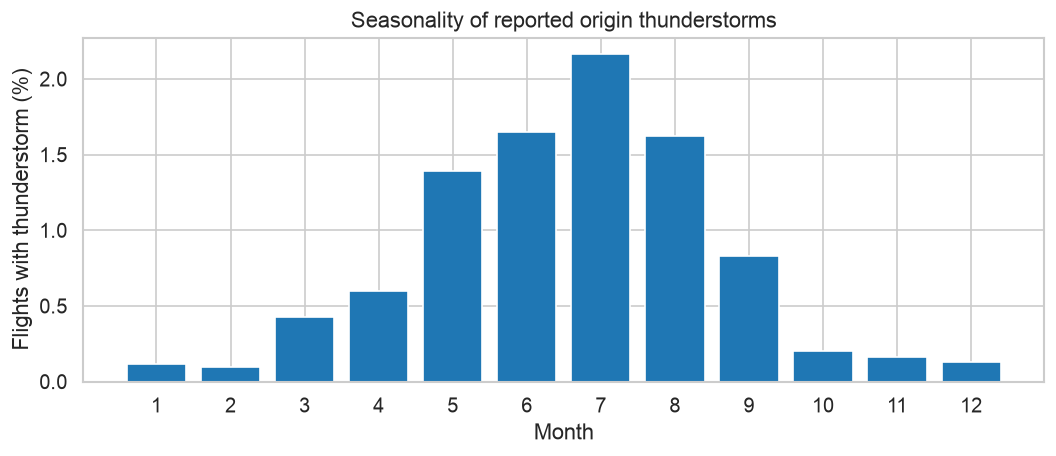

In [33]:
# Thunderstorm seasonality remains a useful companion diagnostic.
thunder_month = (
    thunder.groupby("Month")
    .agg(
        flights=("ArrDel15", "size"),
        thunderstorm_flights=("origin_thunderstorm", "sum"),
    )
    .assign(
        thunderstorm_share_pct=lambda x:
        100 * x["thunderstorm_flights"] / x["flights"]
    )
    .reset_index()
)

print("\nThunderstorm exposure by month")
print(
    thunder_month.to_string(
        index=False,
        formatters={
            "flights": lambda x: f"{x:,.0f}",
            "thunderstorm_flights": lambda x: f"{x:,.0f}",
            "thunderstorm_share_pct": lambda x: f"{x:.2f}%",
        },
    )
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(thunder_month["Month"], thunder_month["thunderstorm_share_pct"])
ax.set(
    title="Seasonality of reported origin thunderstorms",
    xlabel="Month",
    ylabel="Flights with thunderstorm (%)",
)
ax.set_xticks(range(1, 13))
plt.tight_layout()
fig.savefig(FIGURES / "02e4_thunderstorm_seasonality.png", bbox_inches="tight")
plt.show()

**Findings / summary:** 
- Patterns are consistent with operational expectations. Delay risk rises with wind gusts, precipitation, low visibility, and frozen precipitation. 
- The relationship is nonlinear, with a sharp increase in delay risk at higher levels of each weather variable.
- One possible explanation is selection bias: the analysis includes operating
  flights only. Under the most severe conditions, more flights may be cancelled,
  leaving a selected group of flights that were still able to operate.
- Extreme conditions are much less common, but the highest bins still contain
  substantial samples.
- Thunderstorm exposure is concentrated in summer months, which could help explain summer peaks in delay risk.

**Modeling implication:** Wind, precipitation, visibility, frozen-precipitation, and thunderstorm indicators are useful
for both Stage 1 delay classification and Stage 2 conditional severity.
Nonlinear models are appropriate because the risk changes accelerate at severe
thresholds.

### E5. Does `ifr_hours_past3` add anything beyond current conditions?

**Why this analysis:** Test whether recent IFR/LIFR conditions contain predictive information even
after the airport has returned to VFR.

Currently VFR flights with complete three-hour histories:
 ifr_hours    flights delayed_flights delay_rate mean_delay median_delay p90_delay delay_rate_pct
         0 11,557,896       2,409,306      0.208       73.1         42.0     152.0          20.8%
         1    105,031          31,704      0.302       86.0         51.0     186.0          30.2%
         2     34,663           9,019      0.260       78.8         45.0     173.0          26.0%


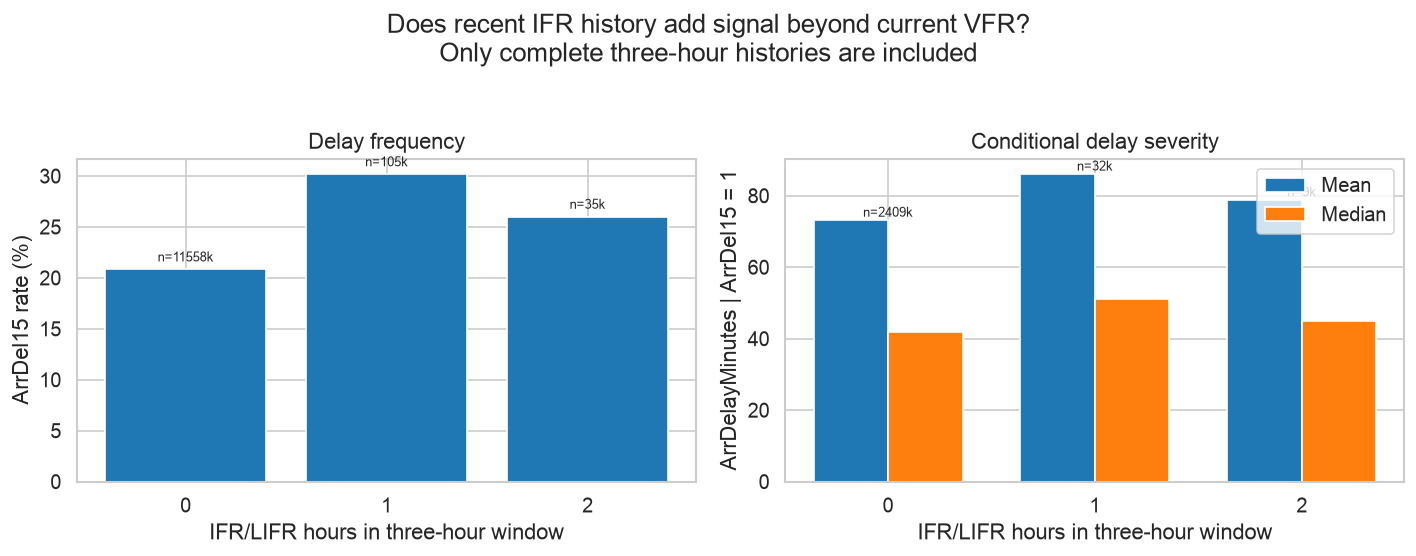

In [34]:
# add_weather_history includes the current snapshot in the three-hour window.
# Therefore, when the current category is VFR, valid IFR counts are 0, 1, or 2.
# Require all three category observations to be present so zero means three
# observed non-IFR hours rather than incomplete history.
wx_q = wx[["airport", "hour", "flight_category"]].sort_values(["airport", "hour"]).copy()
known = wx_q["flight_category"].notna().astype("int8")
wx_q["observed_hours_past3"] = (
    known.groupby(wx_q["airport"], observed=True)
    .rolling(3, min_periods=1).sum()
    .reset_index(level=0, drop=True)
)

# Join history completeness to flights and retain complete, currently VFR rows.
hist = op_with_wx.copy()
hist["_origin_hour"] = scheduled_departure_hour(hist)
hist = hist.merge(
    wx_q[["airport", "hour", "observed_hours_past3"]].rename(
        columns={"airport": "Origin", "hour": "_origin_hour"}
    ),
    on=["Origin", "_origin_hour"], how="left", validate="many_to_one",
)

vfr = hist[
    hist["origin_flight_category"].eq("VFR")
    & hist["origin_ifr_hours_past3"].notna()
    & hist["observed_hours_past3"].eq(3)
].copy()

vfr["ifr_hours"] = vfr["origin_ifr_hours_past3"].astype("Int8")
vfr["delay_if_delayed"] = vfr["ArrDelayMinutes"].where(vfr["ArrDel15"].eq(1))

stats = (
    vfr.groupby("ifr_hours", observed=True)
    .agg(
        flights=("ArrDel15", "size"),
        delayed_flights=("delay_if_delayed", "count"),
        delay_rate=("ArrDel15", "mean"),
        mean_delay=("delay_if_delayed", "mean"),
        median_delay=("delay_if_delayed", "median"),
        p90_delay=("delay_if_delayed", lambda x: x.quantile(0.90)),
    )
    .assign(delay_rate_pct=lambda x: 100 * x["delay_rate"])
    .reset_index()
    .sort_values("ifr_hours")
)

print("Currently VFR flights with complete three-hour histories:")
print(
    stats.to_string(
        index=False,
        formatters={
            "flights": "{:,.0f}".format,
            "delayed_flights": "{:,.0f}".format,
            "delay_rate": "{:.3f}".format,
            "delay_rate_pct": lambda x: f"{x:.1f}%",
            "mean_delay": "{:.1f}".format,
            "median_delay": "{:.1f}".format,
            "p90_delay": "{:.1f}".format,
        },
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x, labels = np.arange(len(stats)), stats["ifr_hours"].astype(str)

bars = axes[0].bar(x, stats["delay_rate_pct"])
axes[0].bar_label(
    bars, labels=[f"n={n / 1e3:.0f}k" for n in stats["flights"]],
    padding=3, fontsize=8,
)
axes[0].set(
    title="Delay frequency",
    xlabel="IFR/LIFR hours in three-hour window",
    ylabel="ArrDel15 rate (%)",
)
axes[0].set_xticks(x, labels)

width = 0.36
axes[1].bar(x - width / 2, stats["mean_delay"], width, label="Mean")
axes[1].bar(x + width / 2, stats["median_delay"], width, label="Median")
for i, row in stats.iterrows():
    axes[1].text(
        i, max(row["mean_delay"], row["median_delay"]) + 1,
        f"n={row['delayed_flights'] / 1e3:.0f}k",
        ha="center", fontsize=8,
    )

axes[1].set(
    title="Conditional delay severity",
    xlabel="IFR/LIFR hours in three-hour window",
    ylabel="ArrDelayMinutes | ArrDel15 = 1",
)
axes[1].set_xticks(x, labels)
axes[1].legend()

fig.suptitle(
    "Does recent IFR history add signal beyond current VFR?\n"
    "Only complete three-hour histories are included",
    y=1.03,
)
plt.tight_layout()
fig.savefig(FIGURES / "02e5_ifr_history.png", bbox_inches="tight")
plt.show()

**Findings / summary:**
- One recent IFR/LIFR hour raises the rate to **30.2%**, a **9.3 percentage-point**
  increase. This is operationally plausible because airport queues, aircraft
  rotations, and airspace restrictions can persist after weather improves.
- Two recent IFR/LIFR hours have a **26.0%** delay rate, still above the
  no-history group but lower than the one-hour group.

**Modeling implication:** The number of recent IFR/LIFR hours alongside current flight category could be useful.

### E6. Origin vs. destination weather at the departure instant

**Why this analysis:** Compare origin and destination weather observed at the same physical departure instant using timezone-correct local keys.

  weather joined: 13,878,218 rows | origin weather missing 0.1%


Destination timezone coverage: 100.00%
Both weather categories present: 99.74%

Origin weather
category    flights delayed_flights delay_rate_pct mean_delay median_delay p90_delay
     VFR 11,698,916       2,449,857          20.9%       73.3         42.0     152.0
    MVFR  1,382,845         337,961          24.4%       77.7         44.0     164.0
     IFR    516,222         150,508          29.2%       83.2         47.0     178.0
    LIFR    243,769          71,800          29.5%       91.8         50.0     199.0

Destination weather
category    flights delayed_flights delay_rate_pct mean_delay median_delay p90_delay
     VFR 11,711,405       2,466,233          21.1%       73.5         42.0     153.0
    MVFR  1,378,800         338,102          24.5%       77.4         44.0     164.0
     IFR    513,085         139,621          27.2%       83.4         46.0     178.0
    LIFR    238,462          66,170          27.7%       90.9         47.0     191.1


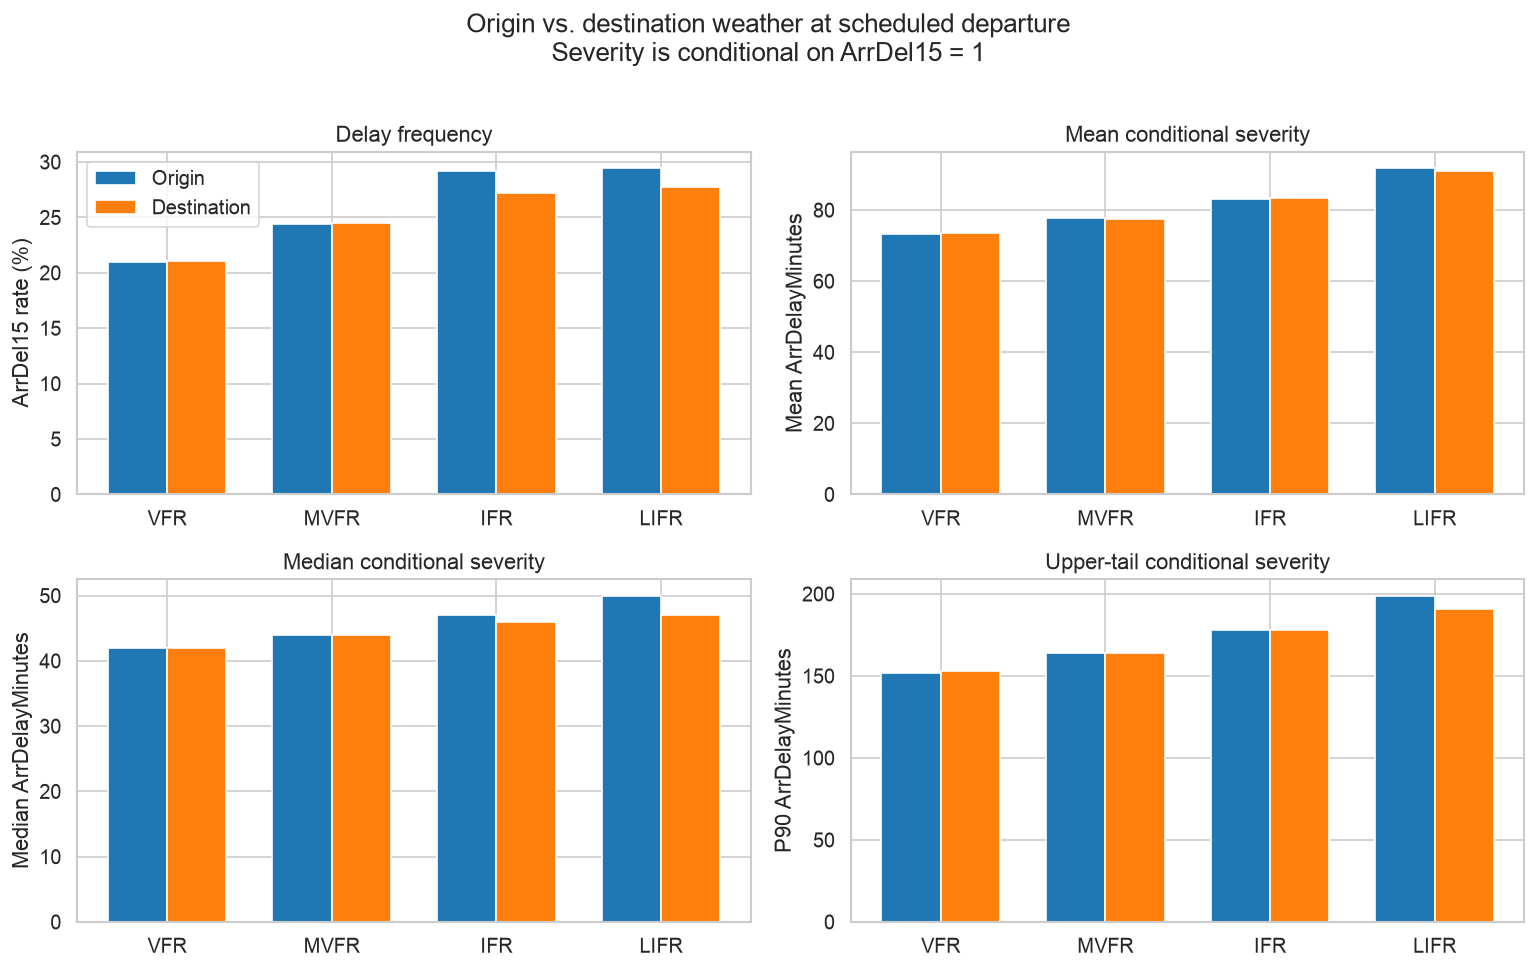

In [35]:
coords = load_airport_coordinates()
timezones = build_airport_timezone_lookup(coords)

df_both = add_destination_departure_keys(
    op_join[
        [
            "__eda_row_id__", "FlightDate", "CRSDepTime", "Origin", "Dest",
            "ArrDel15", "ArrDelayMinutes",
        ]
    ].copy(),
    timezones,
)

df_both = add_weather_features(
    df_both, wx[weather_cols], join_destination=True,
    dest_departure_hour_col="dest_departure_hour_local",
)

assert not df_both["dest_weather_age_minutes"].dropna().lt(0).any()

both = df_both.dropna(
    subset=["origin_flight_category", "dest_flight_category"]
).copy()
both["delay_if_delayed"] = both["ArrDelayMinutes"].where(
    both["ArrDel15"].eq(1)
)

def weather_side_stats(col):
    return (
        both.groupby(col, observed=True)
        .agg(
            flights=("ArrDel15", "size"),
            delayed_flights=("delay_if_delayed", "count"),
            delay_rate=("ArrDel15", "mean"),
            mean_delay=("delay_if_delayed", "mean"),
            median_delay=("delay_if_delayed", "median"),
            p90_delay=("delay_if_delayed", lambda x: x.quantile(0.90)),
        )
        .reindex(cat_order)
        .assign(delay_rate_pct=lambda x: 100 * x["delay_rate"])
        .reset_index()
        .rename(columns={col: "category"})
    )

origin_wx = weather_side_stats("origin_flight_category")
dest_wx = weather_side_stats("dest_flight_category")

print(f"Destination timezone coverage: {df_both['dest_departure_hour_local'].notna().mean():.2%}")
print(f"Both weather categories present: {len(both) / len(df_both):.2%}")

fmt = {
    "flights": "{:,.0f}".format,
    "delayed_flights": "{:,.0f}".format,
    "delay_rate_pct": lambda x: f"{x:.1f}%",
    "mean_delay": "{:.1f}".format,
    "median_delay": "{:.1f}".format,
    "p90_delay": "{:.1f}".format,
}

for name, table in [("Origin weather", origin_wx), ("Destination weather", dest_wx)]:
    print(f"\n{name}")
    print(
        table[
            [
                "category", "flights", "delayed_flights", "delay_rate_pct",
                "mean_delay", "median_delay", "p90_delay",
            ]
        ].to_string(index=False, formatters=fmt)
    )

metrics = [
    ("delay_rate_pct", "Delay frequency", "ArrDel15 rate (%)"),
    ("mean_delay", "Mean conditional severity", "Mean ArrDelayMinutes"),
    ("median_delay", "Median conditional severity", "Median ArrDelayMinutes"),
    ("p90_delay", "Upper-tail conditional severity", "P90 ArrDelayMinutes"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
x, width = np.arange(len(cat_order)), 0.36

for ax, (metric, title, ylabel) in zip(axes.flat, metrics):
    ax.bar(x - width / 2, origin_wx[metric], width, label="Origin")
    ax.bar(x + width / 2, dest_wx[metric], width, label="Destination")
    ax.set(title=title, ylabel=ylabel)
    ax.set_xticks(x, cat_order)

axes[0, 0].legend()
fig.suptitle(
    "Origin vs. destination weather at scheduled departure\n"
    "Severity is conditional on ArrDel15 = 1",
    y=1.01,
)
plt.tight_layout()
fig.savefig(FIGURES / "02e6_origin_vs_dest_weather.png", bbox_inches="tight")
plt.show()

**Findings / summary:**
- Delay frequency and conditional severity increase steadily from VFR to LIFR
  for both origin and destination weather. This aligns with expectations.
- Origin and destination patterns are very similar under VFR and MVFR.
  Differences become more visible under IFR/LIFR, where origin weather has
  slightly higher delay frequency and upper-tail severity.
- Destination weather still shows useful signal even though it is measured at
  scheduled departure rather than arrival. It may capture destination capacity,
  anticipated flow restrictions, regional weather systems, and correlated
  weather along the route.

**Modeling implication:** Retain origin and destination weather as separate features because origin
weather is slightly more predictive under severe conditions and the two sides
represent different operational mechanisms.

---
## Block F — Schedule and route characteristics

**Overall Takeaway:**
- Delay risk is shaped more by operational context than by distance alone.
  Distance has only a modest, non-monotonic relationship with delays.
- Scheduled airport-hour demand becomes more damaging under poor weather.
  High-demand IFR/LIFR periods show the greatest delay risk.

**Modeling implication:** Retain nonlinear distance, scheduled demand, weather, and
demand × weather interactions.


### F1. Distance vs. delay rate and magnitude

**Why this analysis:** Compare delay frequency and severity across distance groups while recognizing that distance also proxies for route structure.

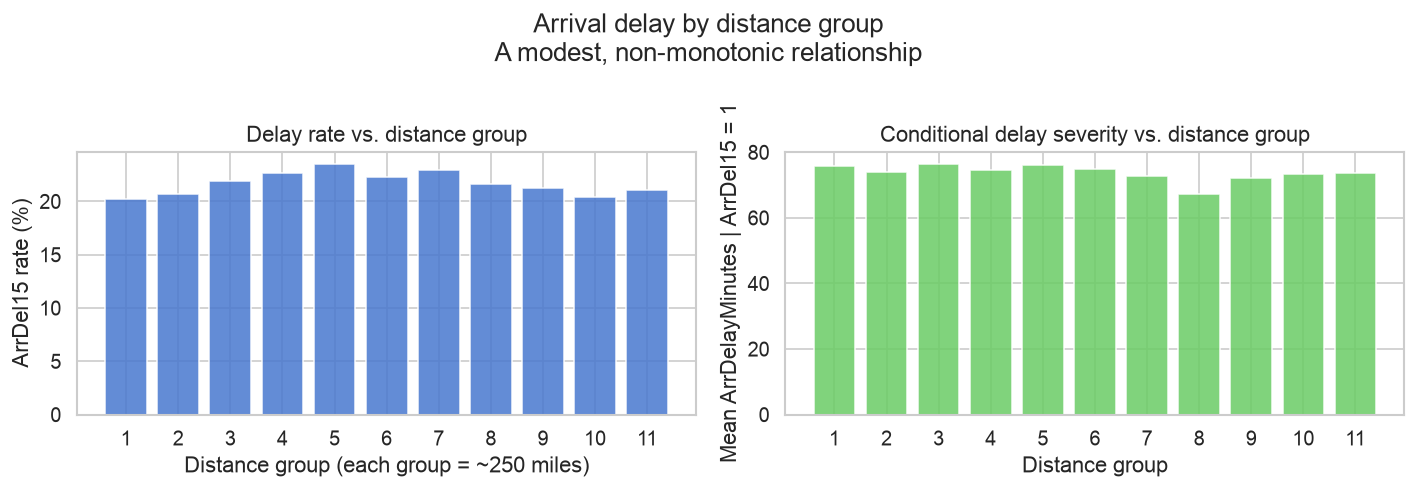

In [36]:
dist_stats = (
    op.assign(
        delay_if_delayed=op["ArrDelayMinutes"].where(op["ArrDel15"].eq(1))
    )
    .dropna(subset=["DistanceGroup"])
    .groupby("DistanceGroup")
    .agg(
        flights=("ArrDel15", "count"),
        delayed_flights=("delay_if_delayed", "count"),
        delay_rate=("ArrDel15", "mean"),
        mean_delay=("delay_if_delayed", "mean"),
    )
    .assign(delay_rate=lambda d: d["delay_rate"] * 100)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.bar(dist_stats["DistanceGroup"].astype(str), dist_stats["delay_rate"],
       color="#4878CF", alpha=0.85)
ax.set_xlabel("Distance group (each group = ~250 miles)")
ax.set_ylabel("ArrDel15 rate (%)")
ax.set_title("Delay rate vs. distance group")

ax = axes[1]
ax.bar(dist_stats["DistanceGroup"].astype(str), dist_stats["mean_delay"],
       color="#6ACC65", alpha=0.85)
ax.set_xlabel("Distance group")
ax.set_ylabel("Mean ArrDelayMinutes | ArrDel15 = 1")
ax.set_title("Conditional delay severity vs. distance group")

fig.suptitle("Arrival delay by distance group\n"
            "A modest, non-monotonic relationship",
             y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / "02f1_distance_delay.png", bbox_inches="tight")
plt.show()

**Findings / summary:**
- Delay risk is mildly non-monotonic: it rises from about **20%** in the shortest
  groups to roughly **23–24%** around groups 4–7, then declines slightly.
- Differences are modest, so distance is likely less informative by itself than
  route, departure time, airport, carrier, and weather.

**Modeling implication:** Retain distance as a nonlinear feature or categorical
distance group. Do not assume a linear increase in delay risk with distance.

### F2. Scheduled demand × origin weather

**Why this analysis:** Scheduled departures in the same airport-hour provide a leakage-safe demand
proxy available before departure. However, the same demand may create different
delay risk depending on weather-related airport capacity. Splitting demand by flight category tests whether congestion risk increases more
sharply when weather reduces capacity.

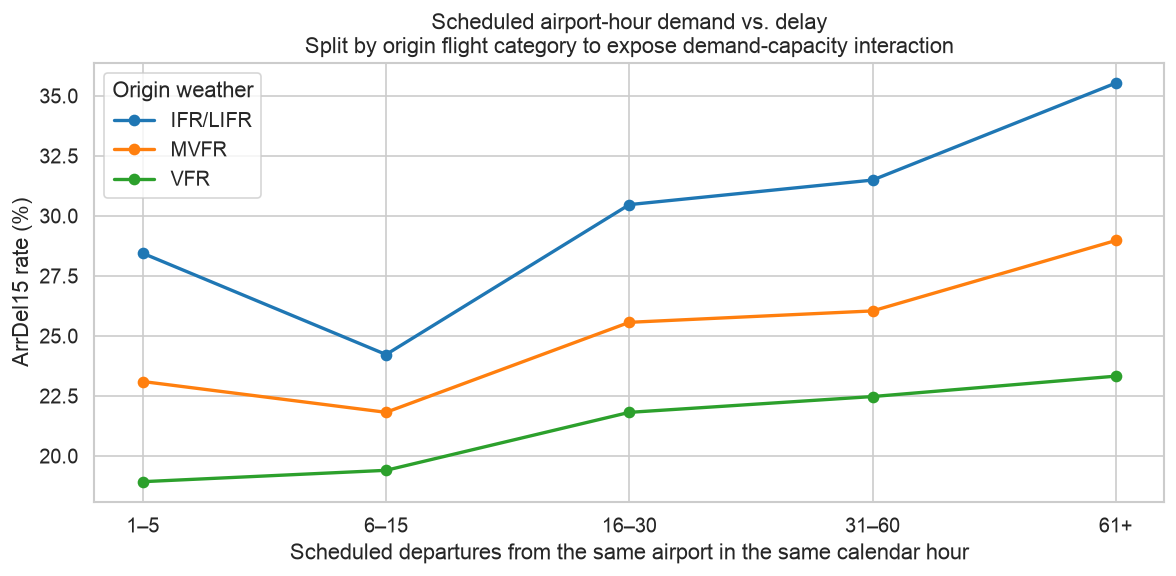

Cell counts for congestion-weather interaction:
weather_band  IFR/LIFR    MVFR      VFR
vol_bin                                
1–5             165999  267291  2359318
6–15            171219  362518  2723291
16–30           201250  381494  3155989
31–60           159881  275739  2506116
61+              62580   97432   968712


In [37]:
# Count every scheduled flight at the actual (airport, local calendar hour)
# grain, including flights that were later cancelled or became non-arrival
# disruptions. Excluding those outcomes would understate demand precisely in the
# most disrupted hours and would make this supposedly schedule-only feature
# depend on future information.
scheduled = df[
    df["Origin"].notna()
    & df["CRSDepTime"].notna()
].copy()
scheduled["scheduled_dep_hour"] = scheduled_departure_hour(scheduled)

scheduled_counts = (
    scheduled.groupby(
        ["Origin", "scheduled_dep_hour"],
        observed=True,
    )
    .size()
    .rename("sched_deps_this_hour")
    .reset_index()
)

congestion = op_with_wx.copy()
congestion["scheduled_dep_hour"] = scheduled_departure_hour(congestion)
congestion = congestion.merge(
    scheduled_counts,
    on=["Origin", "scheduled_dep_hour"],
    how="left",
    validate="many_to_one",
)
if congestion["sched_deps_this_hour"].isna().any():
    raise AssertionError("Scheduled congestion join left unmatched operating flights")
congestion["sched_deps_this_hour"] = (
    congestion["sched_deps_this_hour"].astype("int16")
)
del scheduled, scheduled_counts

congestion["vol_bin"] = pd.cut(
    congestion["sched_deps_this_hour"],
    bins=[0, 5, 15, 30, 60, np.inf],
    labels=["1–5", "6–15", "16–30", "31–60", "61+"],
)

congestion["weather_band"] = pd.Series(
    pd.NA,
    index=congestion.index,
    dtype="string",
)
congestion.loc[
    congestion["origin_flight_category"].eq("VFR"),
    "weather_band",
] = "VFR"
congestion.loc[
    congestion["origin_flight_category"].eq("MVFR"),
    "weather_band",
] = "MVFR"
congestion.loc[
    congestion["origin_flight_category"].astype("string").isin(["IFR", "LIFR"]),
    "weather_band",
] = "IFR/LIFR"

vol_stats = (
    congestion[
        congestion["vol_bin"].notna()
        & congestion["weather_band"].notna()
    ]
    .groupby(["vol_bin", "weather_band"], observed=True)
    .agg(
        flights=("ArrDel15", "count"),
        delay_rate=("ArrDel15", "mean"),
    )
    .assign(delay_rate=lambda d: d["delay_rate"] * 100)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for weather_band, group in vol_stats.groupby("weather_band", observed=True):
    group = group.sort_values("vol_bin")
    ax.plot(
        group["vol_bin"].astype(str),
        group["delay_rate"],
        marker="o",
        linewidth=2,
        label=weather_band,
    )

ax.set_xlabel("Scheduled departures from the same airport in the same calendar hour")
ax.set_ylabel("ArrDel15 rate (%)")
ax.set_title(
    "Scheduled airport-hour demand vs. delay\n"
    "Split by origin flight category to expose demand-capacity interaction"
)
ax.legend(title="Origin weather")
plt.tight_layout()
fig.savefig(FIGURES / "02f2_scheduled_congestion.png", bbox_inches="tight")
plt.show()

print("Cell counts for congestion-weather interaction:")
print(
    vol_stats.pivot(
        index="vol_bin",
        columns="weather_band",
        values="flights",
    ).fillna(0).astype(int).to_string()
)

**Findings / summary:**
- Delay risk generally rises with scheduled demand in every weather category.
- The increase is strongest under IFR/LIFR, reaching about **36%** at 61+
  departures, compared with about **23%** under VFR.
- This interaction is operationally plausible: high demand is harder to process
  when poor visibility or low ceilings reduce runway and airspace capacity.
- The low-demand IFR/LIFR pattern is not monotonic. This may reflect airport-size
  mix, cancellations, or relatively few severe-weather observations.
- Raw departure count is not directly comparable across airports; 30 departures
  may be routine at a hub but unusually high at a smaller airport.

**Modeling implication:** Scheduled airport-hour demand, weather, and their interaction
should be included.

---
## Block G — Anomalies

**Takeaway:** Outlier detection identifies dates for investigation; diagnosis
then separates weather/capacity events, carrier-specific disruptions, and
structural reporting changes. Event names are added only after date-specific
source verification.

### G1. Flag outlier days

**Why this analysis:** We saw the daily patterns in D26.
The goal is to identify these unusually disruptive days using a robust local baseline.

Upper-tail outlier days: 15

Top 15 by delay rate:
      date  delay_rate  flights  scheduled_flights  cancellation_rate  nonarrival_rate
2024-07-19   58.346821    17917              21468          16.526924        16.540898
2024-01-16   51.588513    14416              16530          12.770720        12.788869
2024-01-15   49.971193    15621              18620          15.907626        16.106337
2025-11-30   46.981096    20736              21576           3.851502         3.893215
2025-11-09   45.364903    17950              20442          12.131885        12.190588
2025-03-16   44.327655    19313              20206           4.310601         4.419479
2025-02-16   42.839402    17715              18978           6.523343         6.655074
2025-02-13   42.588064    19219              19715           2.470200         2.515851
2025-11-10   39.997807    18236              20224           9.780459         9.829905
2025-03-15   36.071708    17906              18170           1.403412         1

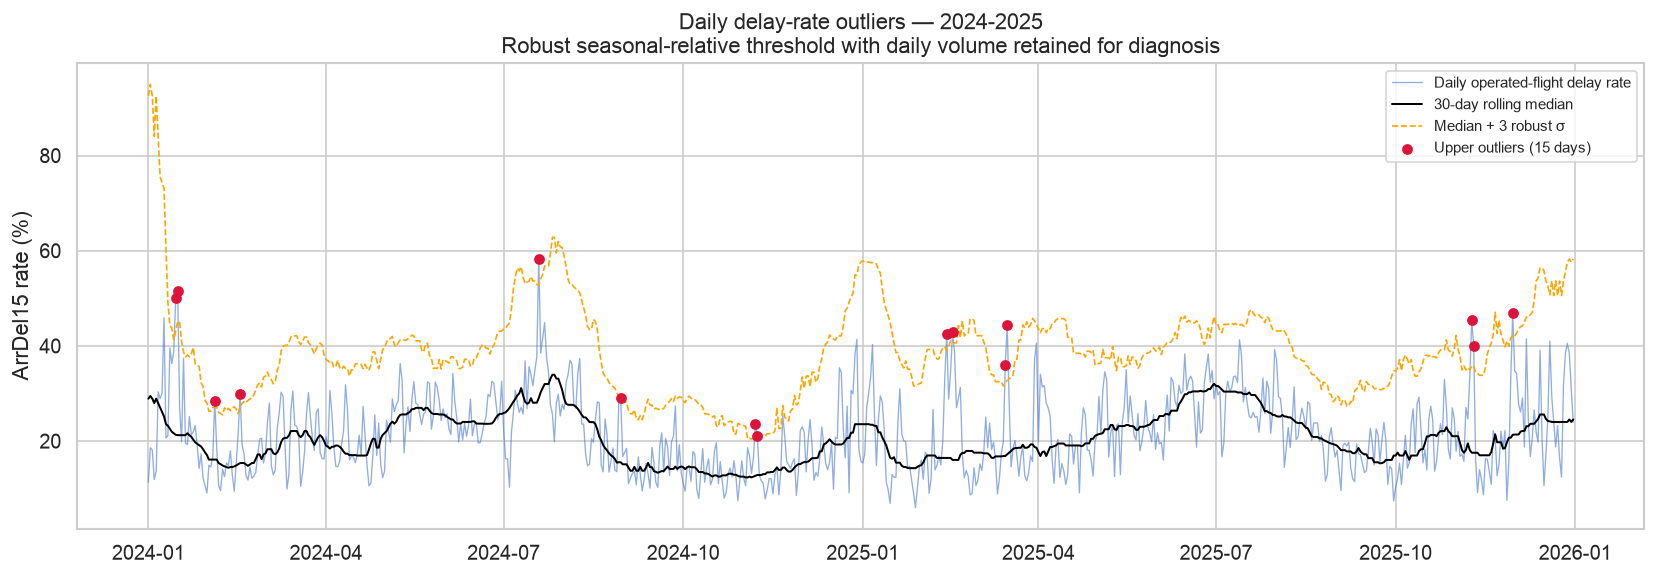

In [38]:
all_daily = (
    df.assign(date=pd.to_datetime(df["FlightDate"]).dt.normalize())
    .groupby("date")
    .agg(
        scheduled_flights=("Cancelled", "size"),
        cancellations=("Cancelled", "sum"),
        nonarrival_disruptions=("nonarrival_disruption", "sum"),
    )
    .assign(
        cancellation_rate=lambda d: d["cancellations"] / d["scheduled_flights"] * 100,
        nonarrival_rate=lambda d: d["nonarrival_disruptions"] / d["scheduled_flights"] * 100,
    )
    .reset_index()
)

daily = daily_series.merge(
    all_daily,
    on="date",
    how="left",
    validate="one_to_one",
).sort_values("date").reset_index(drop=True)

window = 30
daily["rolling_med"] = (
    daily["delay_rate"]
    .rolling(window, center=True, min_periods=10)
    .median()
)
absolute_deviation = (daily["delay_rate"] - daily["rolling_med"]).abs()
daily["rolling_mad"] = (
    absolute_deviation
    .rolling(window, center=True, min_periods=10)
    .median()
)
daily["robust_sigma"] = 1.4826 * daily["rolling_mad"]

k = 3
daily["upper"] = daily["rolling_med"] + k * daily["robust_sigma"]
daily["is_outlier"] = daily["delay_rate"].gt(daily["upper"])

outliers = daily[daily["is_outlier"]].sort_values("delay_rate", ascending=False)
print(f"Upper-tail outlier days: {len(outliers)}")
print("\nTop 15 by delay rate:")
print(
    outliers.head(15)[
        [
            "date",
            "delay_rate",
            "flights",
            "scheduled_flights",
            "cancellation_rate",
            "nonarrival_rate",
        ]
    ].to_string(index=False)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    daily["date"],
    daily["delay_rate"],
    color="#4878CF",
    lw=0.8,
    alpha=0.6,
    label="Daily operated-flight delay rate",
)
ax.plot(
    daily["date"],
    daily["rolling_med"],
    color="black",
    lw=1.2,
    label="30-day rolling median",
)
ax.plot(
    daily["date"],
    daily["upper"],
    color="orange",
    lw=1,
    linestyle="--",
    label=f"Median + {k} robust σ",
)
ax.scatter(
    outliers["date"],
    outliers["delay_rate"],
    color="crimson",
    s=30,
    zorder=5,
    label=f"Upper outliers ({len(outliers)} days)",
)
ax.set_ylabel("ArrDel15 rate (%)")
ax.set_title(
    "Daily delay-rate outliers — 2024-2025\n"
    "Robust seasonal-relative threshold with daily volume retained for diagnosis"
)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES / "02g1_outlier_days.png", bbox_inches="tight")
plt.show()

**Findings / summary:** The robust threshold compares each date with its surrounding
seasonal context. Scheduled volume and cancellation rates remain in the
diagnostic table so an extreme operated-flight rate is not interpreted without
knowing how many flights operated or were removed from the sample.
- The method flags **15 upper-outlier days** across 2024–2025.
- Major anomalies appear in January and July 2024, early 2025, and late 2025.
- The centered rolling window is appropriate for retrospective EDA, but it uses
  future neighboring dates and must not become a live prediction feature.
- Thresholds near the start and end of the series have less surrounding support.


### G2. Diagnose each major spike

**Why this analysis:** Diagnose whether each major spike is concentrated by airport, carrier, cancellation, or delay cause.

Top-outlier diagnostic table:
      date  scheduled_flights  operating_with_target  delay_rate  cancellation_rate  nonarrival_rate                                      top_airports                                      top_carriers    dominant_cause  dominant_cause_minutes  attributed_cause_minutes
2024-07-19              21468                  17917   58.346821          16.526924        16.540898 DEN:542 delayed, CLT:486 delayed, DFW:475 delayed WN:1885 delayed, DL:1695 delayed, AA:1613 delayed      CarrierDelay                658990.0                 1230127.0
2024-01-16              16530                  14416   51.588512          12.770720        12.788869 ATL:399 delayed, ORD:331 delayed, DEN:313 delayed WN:1491 delayed, AA:1153 delayed, DL:1128 delayed LateAircraftDelay                293824.0                  731792.0
2024-01-15              18620                  15621   49.971191          15.907626        16.106337 DFW:546 delayed, DEN:510 delayed, ORD:413 delayed WN:1615 dela

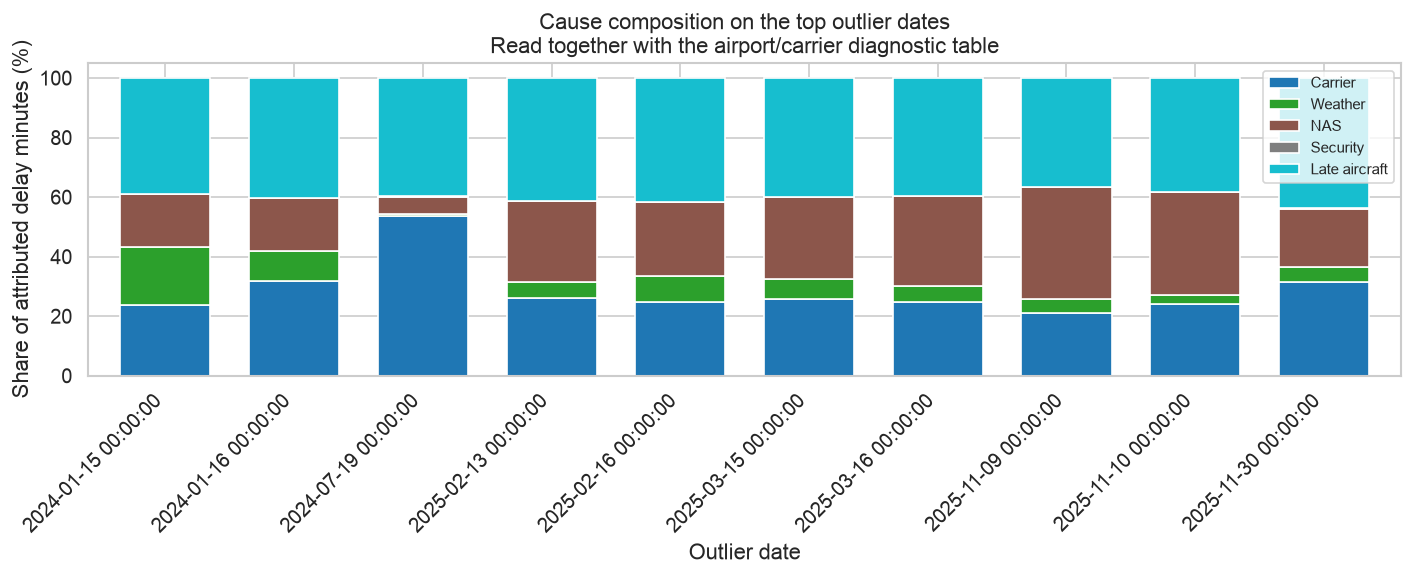

In [39]:
top_outlier_dates = outliers.head(10)["date"].tolist()
df_with_date = df.assign(date=pd.to_datetime(df["FlightDate"]).dt.normalize())
op_with_date = op.assign(date=pd.to_datetime(op["FlightDate"]).dt.normalize())

diagnostic_rows = []
for date in top_outlier_dates:
    day_all = df_with_date[df_with_date["date"].eq(date)]
    day_op = op_with_date[op_with_date["date"].eq(date)]

    airport_rank = (
        day_op.groupby("Origin", observed=True)["ArrDel15"]
        .agg(["count", "sum"])
        .rename(columns={"count": "flights", "sum": "delayed"})
        .sort_values(["delayed", "flights"], ascending=False)
        .head(3)
    )
    carrier_rank = (
        day_op.groupby("Reporting_Airline", observed=True)["ArrDel15"]
        .agg(["count", "sum"])
        .rename(columns={"count": "flights", "sum": "delayed"})
        .sort_values(["delayed", "flights"], ascending=False)
        .head(3)
    )

    causes = day_op.loc[day_op["ArrDel15"].eq(1), cause_cols].sum(min_count=1)
    cause_total = causes.sum(min_count=1)
    dominant_cause = causes.idxmax() if causes.notna().any() else pd.NA
    dominant_minutes = (
        causes.loc[dominant_cause] if pd.notna(dominant_cause) else np.nan
    )

    diagnostic_rows.append(
        {
            "date": date,
            "scheduled_flights": len(day_all),
            "operating_with_target": len(day_op),
            "delay_rate": day_op["ArrDel15"].mean() * 100,
            "cancellation_rate": day_all["Cancelled"].mean() * 100,
            "nonarrival_rate": day_all["nonarrival_disruption"].mean() * 100,
            "top_airports": ", ".join(
                f"{airport}:{int(row.delayed)} delayed"
                for airport, row in airport_rank.iterrows()
            ),
            "top_carriers": ", ".join(
                f"{carrier}:{int(row.delayed)} delayed"
                for carrier, row in carrier_rank.iterrows()
            ),
            "dominant_cause": dominant_cause,
            "dominant_cause_minutes": dominant_minutes,
            "attributed_cause_minutes": cause_total,
        }
    )

spike_diagnostics = pd.DataFrame(diagnostic_rows)
print("Top-outlier diagnostic table:")
print(spike_diagnostics.to_string(index=False))

outlier_flights = op_with_date[op_with_date["date"].isin(top_outlier_dates)]
spike_causes = (
    outlier_flights[outlier_flights["ArrDel15"].eq(1)]
    .groupby("date", observed=True)[cause_cols]
    .sum(min_count=1)
)
print("\nAbsolute attributed cause minutes on top outlier dates:")
print(spike_causes.round(0).astype("Int64").to_string())

spike_causes_pct = spike_causes.div(
    spike_causes.sum(axis=1).replace(0, np.nan),
    axis=0,
) * 100

fig, ax = plt.subplots(figsize=(12, 5))
spike_causes_pct.rename(
    columns={
        "CarrierDelay": "Carrier",
        "WeatherDelay": "Weather",
        "NASDelay": "NAS",
        "SecurityDelay": "Security",
        "LateAircraftDelay": "Late aircraft",
    }
).plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.7)
ax.set_xlabel("Outlier date")
ax.set_ylabel("Share of attributed delay minutes (%)")
ax.set_title(
    "Cause composition on the top outlier dates\n"
    "Read together with the airport/carrier diagnostic table"
)
ax.legend(loc="upper right", fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "02g2_spike_diagnosis.png", bbox_inches="tight")
plt.show()

**Findings / summary:**
- **19 July 2024** is the most severe displayed event: **58.3%** delay rate and
  **16.5%** nonarrival rate. Carrier-attributed delay dominates, with DEN, CLT,
  and DFW among the most affected airports.
- **15–16 January 2024** combine delay rates near **50%**, nonarrival rates near
  **13–16%**, and meaningful weather shares. Late-aircraft delay dominates,
  suggesting an initial disruption propagated through aircraft rotations.
- **9–10 November 2025** show large NAS shares, especially 9 November, together
  with elevated cancellations. This is consistent with broad airspace or
  airport-capacity constraints.
- **30 November 2025** has a **47.0%** delay rate but only **3.9%** nonarrivals,
  indicating that most flights operated but experienced widespread delay.
- Late-aircraft delay is the dominant category on most outlier dates. This
  makes operational sense because local weather, capacity, or carrier problems
  can spread across later aircraft rotations.
- ORD, ATL, DFW, and DEN appear repeatedly among the most affected airports.
  WN also has the largest delayed-flight count on each listed date, but raw
  counts partly reflect its network size and should not be interpreted as a
  carrier-performance ranking.

**Modeling implication:** Use these dates for error analysis across carrier-,
weather-, NAS-, and propagation-dominated regimes. Do not use same-day cause
totals or anomaly labels as scheduled-departure predictors.

### G3. Reported real-world events behind flagged dates

The following manual attributions reproduce the supplied anomaly-attribution
file and are ordered chronologically. They are post-outcome explanations, not
model features. Keep source URLs or archived references with the project before
publication.

- **2024-01-15:** Severe nationwide arctic winter blast combined with the FAA grounding of the
  Boeing 737 MAX 9 fleet.
  *Source: CNBC Article*

- **2024-01-16:** Brutal nationwide arctic winter storm combined with the ongoing federal
  grounding of the Boeing 737 MAX 9 fleet.
  *Source: CNBC Article*

- **2024-02-04:** "Pineapple Express" atmospheric river flooding in California (LAX/SFO) and
  heavy snow at Denver International Airport.
  *Source: CNN Article*

- **2024-02-17:** Standard winter turnaround operations and logistical domino effects
  (late-arriving aircraft).
  *Source: Bureau of Transportation Statistics*

- **2024-07-19:** Massive global IT outage caused by a faulty CrowdStrike software update
  affecting Microsoft Windows systems.
  *Source: CNBC Article*

- **2024-08-30:** Typhoon Shanshan bringing torrential rains and severe winds across
  international travel hubs in Japan.
  *Source: Reuters Article*

- **2024-11-07:** Major early-season winter snowstorm blanketed Colorado, triggering FAA air
  traffic management protocols.
  *Source: Denver Post Article*

- **2024-11-08:** Residual delays and continued snow management protocols from the previous
  day's Colorado winter storm.
  *Source: Denver Post Article*

- **2025-02-13:** Heavy U.S. winter storm ice/snow combined with a major general labor strike
  that paralyzed Brussels/Charleroi airports.
  *Source: Forbes Air Travel Updates / Euronews*

- **2025-02-16:** Failure of the FAA system distributing safety alerts to pilots and localized
  radar outages at East Coast hubs.
  *Source: CNN Tracker*

- **2025-03-15:** Delta Air Lines localized equipment/network failures alongside wider
  commercial industry pilot and staff shortages.
  *Source: US DOT Aviation Consumer Reports*

- **2025-03-16:** Heavy U.S. domestic airspace congestion and cascading low on-time
  performance by major low-cost carriers.
  *Source: Bureau of Transportation Statistics*

- **2025-11-09:** Record-breaking U.S. government shutdown day 40; unpaid air traffic
  controller shortages forced FAA flight capacity cuts.
  *Source: CNN Delay Analytics*

- **2025-11-10:** Continued FAA-mandated flight cuts and air traffic staffing shortages under
  the federal government shutdown.
  *Source: CNN Delay Analytics*

- **2025-11-30:** Record Thanksgiving travel volume strained by residual labor disruptions
  following the freshly resolved government shutdown.
  *Source: FlightAware Data / CNN Tracker*


### G4. Structural anomalies — carrier reporting and volume shifts

**Why this analysis:** Check for structural changes in carrier reporting or volume that could be mistaken for operational anomalies.

Carrier structural events:
carrier   month                  event previous_flights flights flights_per_day pct_change shift_z volume_index
     G4 2024-03 large percentage shift            8,486  11,031           355.8     +21.6%   +0.78        1.06×
     WN 2024-03           robust shift          105,207 125,272         4,041.0     +11.4%   +3.76        1.05×
     G4 2024-06 large percentage shift            9,567  12,229           407.6     +32.1%   +1.11        1.21×
     G4 2024-08 large percentage shift           12,861   9,244           298.2     -28.1%   -1.31        0.89×
     G4 2024-09 large percentage shift            9,244   6,889           229.6     -23.0%   -1.03        0.68×
     G4 2024-10 large percentage shift            6,889   9,195           296.6     +29.2%   +1.02        0.88×
     G4 2024-12 large percentage shift            8,757  11,084           357.5     +22.5%   +0.81        1.06×
     9E 2025-01          disappearance           17,351       0             0

/var/folders/4q/bcs2wt0906vdhb03j4swyhpc0000gn/T/ipykernel_54299/1855695038.py:164: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/bcs2wt0906vdhb03j4swyhpc0000gn/T/ipykernel_54299/1855695038.py:165: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.savefig(
/Users/jocelynzhao/bloomberg_case/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


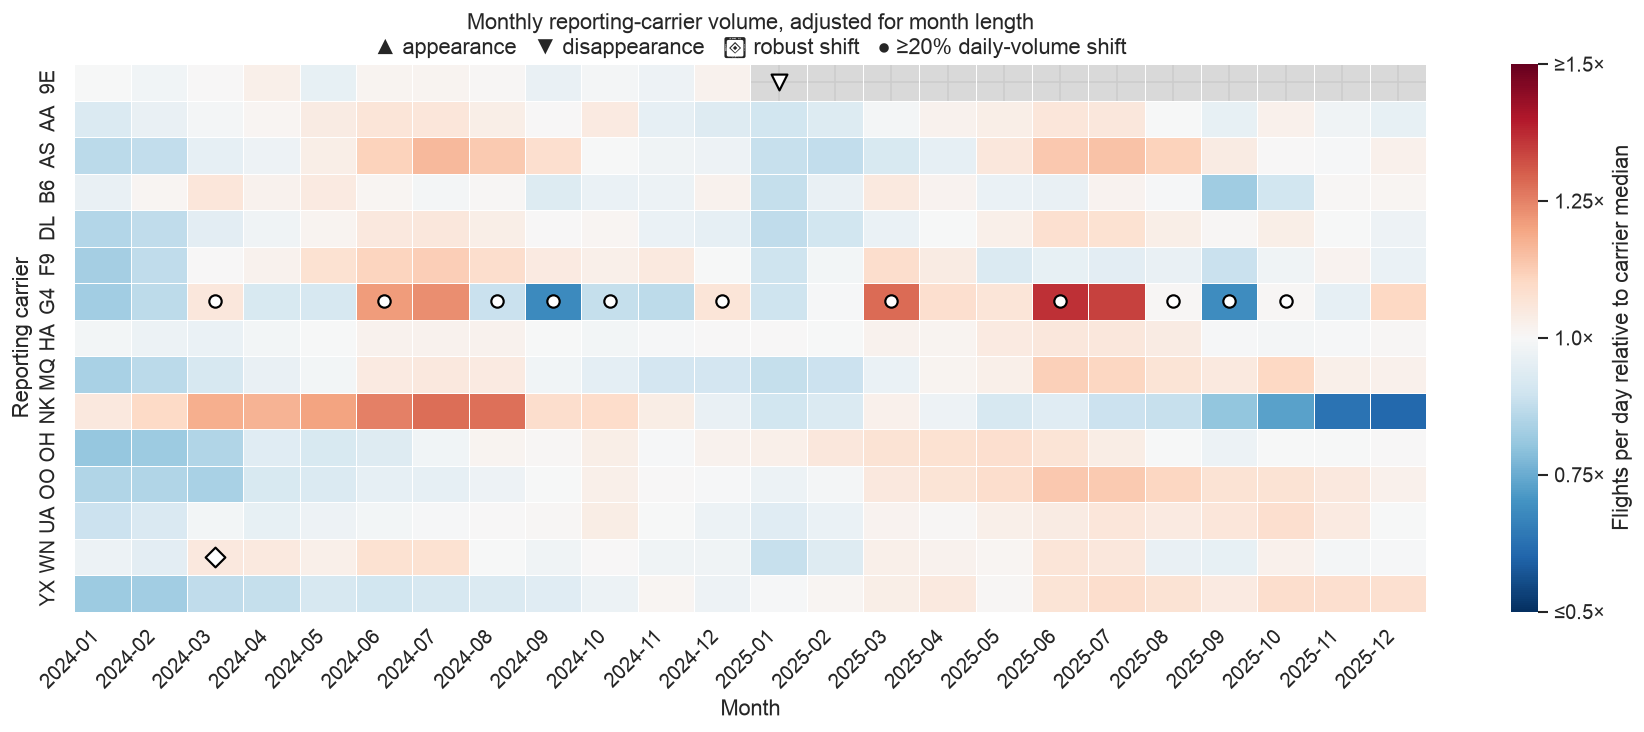

In [40]:
ROBUST_Z_LIMIT, LARGE_CHANGE_LIMIT = 3.5, 20

base = df.assign(
    carrier=df["Reporting_Airline"].astype("string"),
    period=pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1)),
)

# Count all scheduled flight records by reporting carrier and month.
monthly = (
    base.groupby(["period", "carrier"], observed=True)
    .size().rename("flights").reset_index()
)

# Add missing carrier-month combinations as zero-volume months.
periods = pd.date_range(monthly["period"].min(), monthly["period"].max(), freq="MS")
carriers = sorted(monthly["carrier"].dropna().unique())
grid = pd.MultiIndex.from_product([periods, carriers], names=["period", "carrier"])

monthly = (
    monthly.set_index(["period", "carrier"])
    .reindex(grid, fill_value=0).reset_index()
    .sort_values(["carrier", "period"])
)

# Normalize for month length.
monthly["days_in_month"] = monthly["period"].dt.days_in_month
monthly["flights_per_day"] = monthly["flights"] / monthly["days_in_month"]
monthly["previous_flights"] = monthly.groupby("carrier")["flights"].shift()
monthly["previous_rate"] = monthly.groupby("carrier")["flights_per_day"].shift()

valid = monthly["flights"].gt(0) & monthly["previous_flights"].gt(0)
monthly["pct_change"] = (
    100 * (monthly["flights_per_day"] / monthly["previous_rate"] - 1)
).where(valid)
monthly["log_change"] = (
    np.log1p(monthly["flights_per_day"])
    - np.log1p(monthly["previous_rate"])
).where(valid)

# Retrospective carrier-specific robust anomaly score.
def robust_z(s):
    center = s.median()
    mad = (s - center).abs().median()
    if pd.isna(mad) or mad == 0:
        return pd.Series(np.nan, index=s.index)
    return 0.6745 * (s - center) / mad

monthly["shift_z"] = (
    monthly.groupby("carrier")["log_change"].transform(robust_z)
)
monthly["robust_shift"] = monthly["shift_z"].abs().ge(ROBUST_Z_LIMIT)
monthly["large_shift"] = valid & monthly["pct_change"].abs().ge(LARGE_CHANGE_LIMIT)

# Classify each carrier-month transition.
monthly["event"] = np.select(
    [
        monthly["previous_flights"].eq(0) & monthly["flights"].gt(0),
        monthly["previous_flights"].gt(0) & monthly["flights"].eq(0),
        monthly["robust_shift"],
        monthly["large_shift"],
    ],
    ["appearance", "disappearance", "robust shift", "large percentage shift"],
    default="",
)

# Compare each carrier with its own typical active-month daily volume.
active = monthly[monthly["flights"].gt(0)]
carrier_median = active.groupby("carrier")["flights_per_day"].median()
monthly["volume_index"] = (
    monthly["flights_per_day"] / monthly["carrier"].map(carrier_median)
)

# Print flagged events.
events = monthly[monthly["event"].ne("")].copy()
events["month"] = events["period"].dt.strftime("%Y-%m")

event_table = events[
    [
        "carrier", "month", "event", "previous_flights", "flights",
        "flights_per_day", "pct_change", "shift_z", "volume_index",
    ]
].sort_values(["month", "carrier"])

print("Carrier structural events:")
print(
    event_table.to_string(
        index=False,
        formatters={
            "previous_flights": lambda x: f"{x:,.0f}",
            "flights": lambda x: f"{x:,.0f}",
            "flights_per_day": lambda x: f"{x:,.1f}",
            "pct_change": lambda x: "" if pd.isna(x) else f"{x:+.1f}%",
            "shift_z": lambda x: "" if pd.isna(x) else f"{x:+.2f}",
            "volume_index": lambda x: f"{x:.2f}×",
        },
    )
    if len(event_table) else "No events found."
)

# Heatmap: daily volume relative to each carrier's active-month median.
heat = monthly.pivot(
    index="carrier", columns="period", values="volume_index"
)
active_heat = heat.where(heat.gt(0)).clip(0.5, 1.5)

fig, ax = plt.subplots(figsize=(15, max(5, 0.42 * len(carriers))))
ax.set_facecolor("#d9d9d9")  # Gray indicates no reported flights.

sns.heatmap(
    active_heat,
    cmap="RdBu_r",
    center=1,
    vmin=0.5,
    vmax=1.5,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Flights per day relative to carrier median",
        "ticks": [0.5, 0.75, 1, 1.25, 1.5],
    },
    ax=ax,
)

# Draw markers separately so disappearance markers remain visible on gray cells.
marker_style = {
    "appearance": ("^", 90),
    "disappearance": ("v", 90),
    "robust shift": ("D", 70),
    "large percentage shift": ("o", 55),
}
row_pos = {carrier: i for i, carrier in enumerate(active_heat.index)}
col_pos = {period: i for i, period in enumerate(active_heat.columns)}

for row in events.itertuples():
    marker, size = marker_style[row.event]
    ax.scatter(
        col_pos[row.period] + 0.5,
        row_pos[row.carrier] + 0.5,
        marker=marker,
        s=size,
        facecolor="white",
        edgecolor="black",
        linewidth=1.3,
        zorder=5,
    )

cbar = ax.collections[0].colorbar
cbar.ax.set_yticklabels(["≤0.5×", "0.75×", "1.0×", "1.25×", "≥1.5×"])

ax.set(
    title=(
        "Monthly reporting-carrier volume, adjusted for month length\n"
        "▲ appearance   ▼ disappearance   ◆ robust shift   ● ≥20% daily-volume shift"
    ),
    xlabel="Month",
    ylabel="Reporting carrier",
)
ax.set_xticklabels(
    [date.strftime("%Y-%m") for date in active_heat.columns],
    rotation=45,
    ha="right",
)

plt.tight_layout()
fig.savefig(
    FIGURES / "02g4_carrier_structural_anomalies.png",
    bbox_inches="tight",
)
plt.show()

**Findings / summary:**
- **9E drops from active reporting in December 2024 to zero flights in January 2025**,
  suggesting a reporting-carrier or dataset-coverage change.
- **WN** has a robust increase in **March 2025**, followed by a sustained decline
  later in the year. This deserves route-level investigation.
- **G4** has many changes of at least 20%, including the strong February-to-March
  2025 increase. However, most are not robust anomalies because G4 normally has
  relatively volatile and seasonal monthly capacity. It could reflect its highly 
  seasonal leisure schedule rather than data corruption.

**Modeling implication:** Carrier effects may change over time. Use time-based validation and treat
appearances, disappearances, or reporting-code changes explicitly rather than
assuming carrier categories are stable.

## Block H Changes in operating environment

**Why this analysis:** Static historical carrier, airport, and route rates capture
persistent differences, but they cannot represent a system-wide change in delay
conditions. Recent rates are intended to capture that changing operating
environment.

We use a 7-day and 28-day national rate to represent short- and medium-term
network conditions. Carrier, origin, and destination rates initially use a
28-day window because these groups contain fewer observations and therefore
require more history for stable estimates. The window length is a modeling
choice and will be assessed for responsiveness and stability.

We use a 2 day lag here to make prevent target leakage. For a flight on date
`D`, an availability lag of two days means the newest outcome date allowed into
a rolling rate is `D - 2`. 2024-2025 is used, Jan-May 2026 remains untouched.

In [4]:
from recent_performance_features import (
    add_recent_rates_to_splits,
    recent_feature_names,
)

RECENT_RATE_FEATURES = recent_feature_names()
RECENT_AVAILABILITY_LAG_DAYS = 2

# Stage 1 only needs a known binary arrival-delay target. Keep this diagnostic
# separate from `op`, which also requires ArrDelayMinutes for severity analyses.
recent_source = df.loc[
    ~df["nonarrival_disruption"] & df["ArrDel15"].notna(),
    [
        "Year",
        "FlightDate",
        "ArrDel15",
        "Reporting_Airline",
        "Origin",
        "Dest",
    ],
].copy()

recent_train = recent_source.loc[recent_source["Year"].eq(2024)].copy()
recent_valid = recent_source.loc[recent_source["Year"].eq(2025)].copy()

assert len(recent_train) > 0 and len(recent_valid) > 0
assert pd.to_datetime(recent_train["FlightDate"]).max() < pd.to_datetime(recent_valid["FlightDate"]).min()

recent_train, recent_valid = add_recent_rates_to_splits(
    recent_train,
    recent_valid,
    initial_prior=0.20,
    availability_lag_days=RECENT_AVAILABILITY_LAG_DAYS,
)

assert set(RECENT_RATE_FEATURES).issubset(recent_valid.columns)
assert recent_valid[RECENT_RATE_FEATURES].notna().all().all()

recent_monthly = (
    recent_valid.assign(
        period=pd.to_datetime(recent_valid["FlightDate"]).dt.to_period("M").astype(str)
    )
    .groupby("period", observed=True)
    .agg(
        flights=("ArrDel15", "size"),
        actual_delay_rate=("ArrDel15", "mean"),
        **{
            feature: (feature, "mean")
            for feature in RECENT_RATE_FEATURES
        },
    )
    .reset_index()
)

recent_monthly["national_7d_minus_28d"] = (
    recent_monthly["national_delay_rate_7d"]
    - recent_monthly["national_delay_rate_28d"]
)

recent_monthly["gap_actual_minus_7d"] = (
    recent_monthly["actual_delay_rate"]
    - recent_monthly["national_delay_rate_7d"]
)
recent_monthly["gap_actual_minus_28d"] = (
    recent_monthly["actual_delay_rate"]
    - recent_monthly["national_delay_rate_28d"]
)

print(
    recent_monthly[
        [
            "period",
            "flights",
            "actual_delay_rate",
            "national_delay_rate_7d",
            "national_delay_rate_28d",
            "carrier_delay_rate_28d",
            "origin_delay_rate_28d",
            "dest_delay_rate_28d",
            "national_7d_minus_28d",
        ]
    ].round(4).to_string(index=False)
)

 period  flights  actual_delay_rate  national_delay_rate_7d  national_delay_rate_28d  carrier_delay_rate_28d  origin_delay_rate_28d  dest_delay_rate_28d  national_7d_minus_28d
2025-01   523167             0.1893                  0.2144                   0.2262                  0.2261                 0.2264               0.2254                -0.0118
2025-02   497343             0.2090                  0.2117                   0.1846                  0.1845                 0.1843               0.1838                 0.0271
2025-03   593741             0.1978                  0.1780                   0.1968                  0.1967                 0.1969               0.1958                -0.0188
2025-04   578961             0.1983                  0.2088                   0.2112                  0.2112                 0.2118               0.2109                -0.0024
2025-05   599192             0.2381                  0.2319                   0.2140                  0.2139            

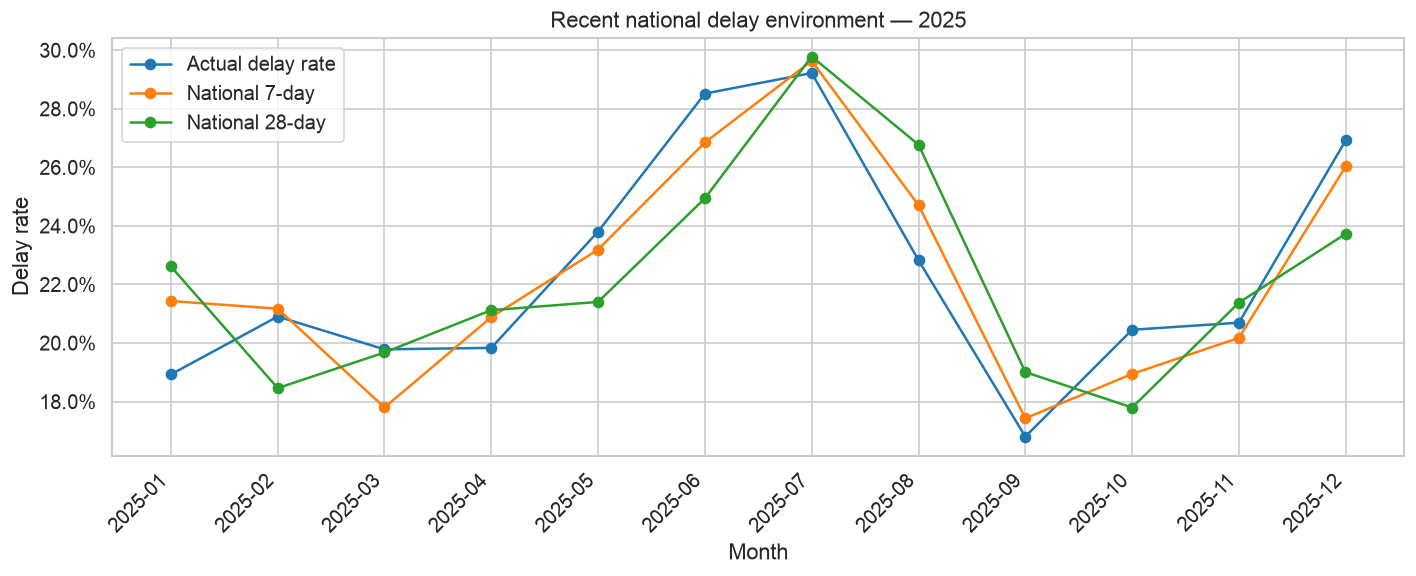

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

for column, label in [
    ("actual_delay_rate", "Actual delay rate"),
    ("national_delay_rate_7d", "National 7-day"),
    ("national_delay_rate_28d", "National 28-day"),
]:
    ax.plot(
        recent_monthly["period"],
        recent_monthly[column],
        marker="o",
        label=label,
    )

ax.set(
    title="Recent national delay environment — 2025",
    xlabel="Month",
    ylabel="Delay rate",
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "02h1_recent_national_rates.png", bbox_inches="tight")
plt.show()

### Findings / summary 
 - The 7-day national delay rate responds more quickly to changes in the
   operating environment, while the 28-day rate provides a smoother but more
   persistent baseline.
 - Both rates rise during the June–July disruption period, but the 28-day rate
   remains elevated after the observed delay rate falls in August and September.
   This illustrates the expected lag from using a longer rolling window.
 - The 7-day rate adapts more quickly to both the post-summer decline and the
   renewed increase in December.
 - Neither feature perfectly tracks the current month's observed rate because
   each flight's feature uses only prior available outcomes. The plotted values
   are monthly averages of those prediction-time rolling features rather than
   contemporaneous monthly delay rates.

###  Modeling implication

 Retain both national windows for now. The 7-day feature captures short-term
 changes, while the 28-day feature represents the broader operating regime.
 Their difference may provide an additional signal describing whether recent
 conditions are worsening or improving. Feature ablation should determine
 whether the longer window adds predictive value beyond the shorter window.

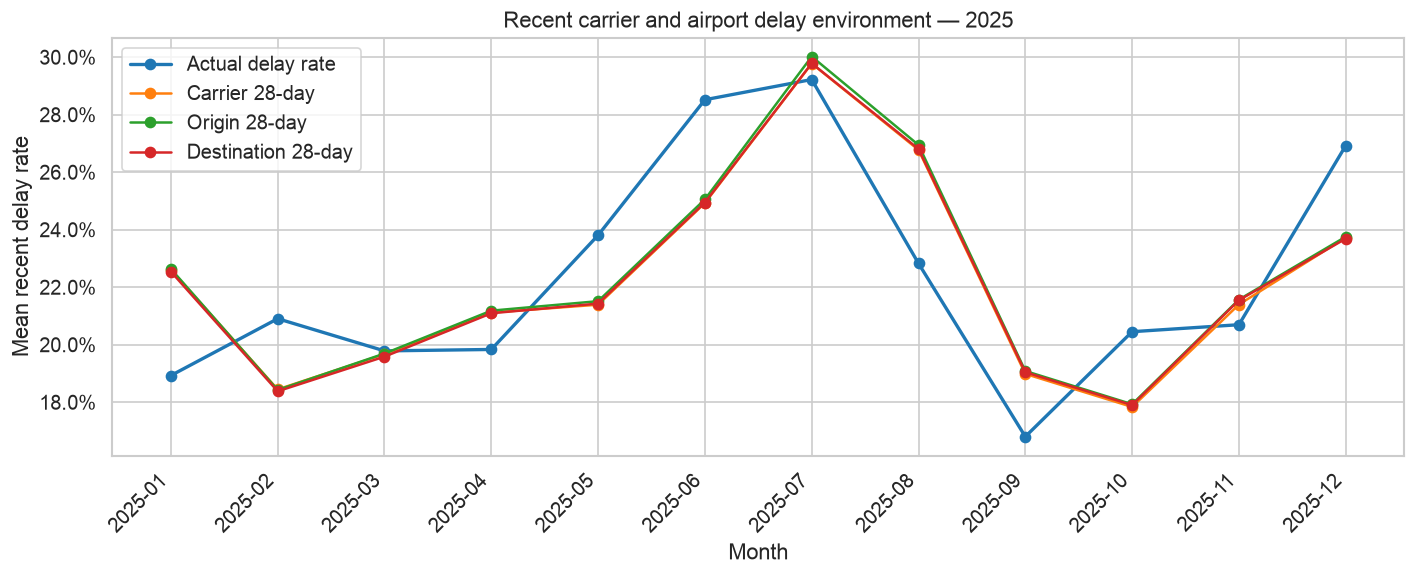

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    recent_monthly["period"],
    recent_monthly["actual_delay_rate"],
    marker="o",
    linewidth=2,
    label="Actual delay rate",
)

for column, label in [
    ("carrier_delay_rate_28d", "Carrier 28-day"),
    ("origin_delay_rate_28d", "Origin 28-day"),
    ("dest_delay_rate_28d", "Destination 28-day"),
]:
    ax.plot(
        recent_monthly["period"],
        recent_monthly[column],
        marker="o",
        label=label,
    )

ax.set(
    title="Recent carrier and airport delay environment — 2025",
    xlabel="Month",
    ylabel="Mean recent delay rate",
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "02h1_recent_group_rates.png", bbox_inches="tight")
plt.show()

### Findings / summary
 - The carrier, origin, and destination 28-day rates have nearly identical
   monthly averages and follow the same broad temporal pattern.
 - The 28-day features respond smoothly to changing conditions but lag abrupt
   changes. They remain elevated after the July peak and understate the rapid
   increases seen in June and December.
 - This persistence is operationally plausible because a 28-day window retains
   several weeks of earlier outcomes after conditions change.

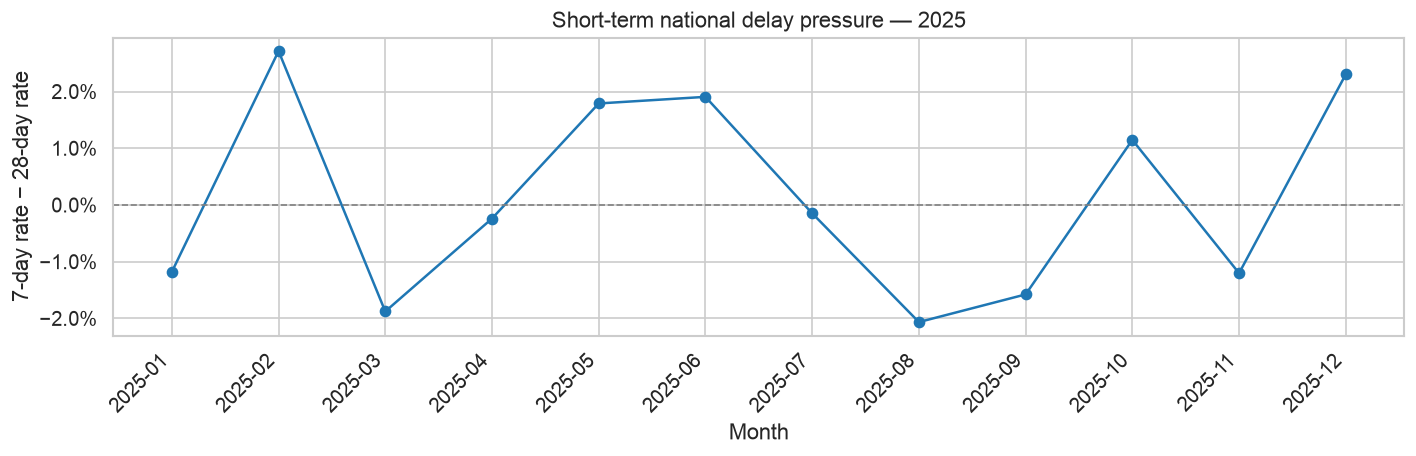

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    recent_monthly["period"],
    recent_monthly["national_7d_minus_28d"],
    marker="o",
)
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set(
    title="Short-term national delay pressure — 2025",
    xlabel="Month",
    ylabel="7-day rate − 28-day rate",
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "02h1_recent_short_vs_long.png", bbox_inches="tight")
plt.show()

### Findings / summary
- The difference between the 7-day and 28-day national rates provides a
   directional measure of short-term network conditions.
 - Positive values indicate that recent delay conditions are worsening relative
   to the broader 28-day baseline, while negative values indicate improvement.
 - Short-term pressure rises notably in May–June and December, while August and
   September show strong improvement after the summer peak.
 - The near-zero July value indicates that both rolling windows had caught up to
   the elevated summer delay regime.
 - The pattern is operationally plausible and shows why the 7-day and 28-day
   rates contain complementary information rather than simply duplicating one
   another.

### Modeling implication

`national_delay_pressure_7d_vs_28d` could be a candidate feature. It directly
 represents whether network-wide conditions are worsening or improving and may
 help the model respond to regime changes more efficiently than relying on the
 two rolling rates separately.